### Scott 10k crystal ball
#### Take patients with MCI that progress to CN in a later diagnosis
#### Can I train an ML model (LR + XGB SHAP) to predict 'converters' to MCI from non-converters
#### Even better - can I find a set of beta coefficients via RFECV to maximise prediction performance?

In [1]:
import os
import pandas as pd
import numpy as np

df = pd.read_csv('C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_housekeeping/sbm_w_vbm_scott10k_alliedhealth.csv', low_memory = False)

print(df.columns.tolist()[:20])
coeff_cols = ['desikan_D1', 'desikan_D2', 'desikan_DAT', 'desikan_NET', 'desikan_5HT1A', 'desikan_5HT1B', 'desikan_5HT2A', 'desikan_5HT4', 'desikan_5HT6', 'desikan_5HTT', 'desikan_a4b2', 'desikan_M1', 'desikan_vAChT', 'desikan_NMDA',	'desikan_mGluR5', 'desikan_GABAA/BZ', 'desikan_H3', 'desikan_CB1', 'desikan_MOR']

mci_df = df.copy()[['PTID', 'DATA_KEY', 'VISDATE', 'PTAGE', 'PTGENDER', 'FIELD_STRENGTH', 'DIAGNOSIS', 'MMSCORE', 'CDGLOBAL', 'NPISCORE'] + coeff_cols]
mci_df.rename(columns = {'PTAGE': 'PTAGE_mci', 'FIELD_STRENGTH' : 'FIELD_STRENGTH_mci'}, inplace = True)
mci_df = mci_df[mci_df['DIAGNOSIS'] == 2]
mci_df['VISDATE'] = pd.to_datetime(mci_df['VISDATE'])

other_df = df.copy()[['PTID', 'VISDATE', 'DIAGNOSIS', 'MMSCORE', 'CDGLOBAL', 'NPISCORE'] + coeff_cols] # Other df will have CN, MCI and AD values! Lets us encode converters and non-converters later on
other_df['VISDATE'] = pd.to_datetime(other_df['VISDATE'])

cb_df_raw = pd.merge(mci_df, other_df, on = ['PTID'], suffixes=('_mci', '_oth'))
cb_df_raw = cb_df_raw.sort_values(by = 'PTID', ascending = True)
print(cb_df_raw.shape)

['PTID', 'RID', 'SITE_ID', 'DATA_KEY', 'T1_YEAR', 'T1_MON', 'T1_DAY', 'VISDATE', 'EXAMDATE_4WKS_LATER', 'EXAMDATE_4WKS_B4', 'T1_PATH', 'MWC1T1_PATH', 'PTGENDER', 'PTDOB', 'PTEDUCAT', 'PTAGE', 'GENOTYPE', 'EXAMDATE_MRIFLDSTRNGTH', 'FIELD_STRENGTH', 'DATEDIFFS_MRIFLDSTRNGTH']


C:\Users\User\AppData\Local\Temp\ipykernel_14356\495197297.py:13: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  mci_df['VISDATE'] = pd.to_datetime(mci_df['VISDATE'])


(52230, 53)


C:\Users\User\AppData\Local\Temp\ipykernel_14356\495197297.py:16: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  other_df['VISDATE'] = pd.to_datetime(other_df['VISDATE'])


In [2]:
cb_df_raw

,PTID,DATA_KEY,VISDATE_mci,PTAGE_mci,PTGENDER,FIELD_STRENGTH_mci,DIAGNOSIS_mci,MMSCORE_mci,CDGLOBAL_mci,NPISCORE_mci,...,desikan_5HTT_oth,desikan_a4b2_oth,desikan_M1_oth,desikan_vAChT_oth,desikan_NMDA_oth,desikan_mGluR5_oth,desikan_GABAA/BZ_oth,desikan_H3_oth,desikan_CB1_oth,desikan_MOR_oth
0,002_S_0729,002_S_0729_ADNI-T1_2006-07-17_13_27_14.0,2006-07-17,65.0,2.0,1.5T,2.0,27.0,0.5,0.0,...,-0.373219,-0.000610,-0.248703,-0.307005,0.055970,0.047616,0.313480,0.202959,-0.147698,0.076622
55,002_S_0729,002_S_0729_ADNI-T1_2007-02-22_08_24_49.0,2007-02-22,65.0,2.0,1.5T,2.0,27.0,0.5,0.0,...,-0.493902,0.068110,-0.480238,-0.532484,0.181664,0.422242,0.221692,0.453946,-0.316849,-0.097766
54,002_S_0729,002_S_0729_ADNI-T1_2007-02-22_08_24_49.0,2007-02-22,65.0,2.0,1.5T,2.0,27.0,0.5,0.0,...,-0.552819,0.116004,-0.439910,-0.618061,0.243706,0.473602,0.221422,0.516694,-0.372664,-0.123107
53,002_S_0729,002_S_0729_ADNI-T1_2007-02-22_08_24_49.0,2007-02-22,65.0,2.0,1.5T,2.0,27.0,0.5,0.0,...,-0.566926,0.112706,-0.382196,-0.515332,0.235462,0.365763,0.198331,0.489161,-0.358371,-0.096191
52,002_S_0729,002_S_0729_ADNI-T1_2007-02-22_08_24_49.0,2007-02-22,65.0,2.0,1.5T,2.0,27.0,0.5,0.0,...,-0.479139,0.096916,-0.480566,-0.448581,0.108199,0.414451,0.315467,0.398229,-0.206795,-0.110812
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52225,941_S_6392,941_S_6392_ADNI-T1_2018-05-30_12_58_17.0,2018-05-30,88.0,1.0,3T,2.0,30.0,0.0,NaN,...,0.077165,0.192027,-0.336402,-0.204925,-0.095067,0.121091,-0.221697,0.313933,-0.027562,-0.260111
52226,941_S_6803,941_S_6803_ADNI-T1_2019-09-16_11_51_29.0,2019-09-16,75.0,2.0,3T,2.0,28.0,0.5,NaN,...,0.006296,0.110210,-0.352908,-0.074358,0.049662,0.157895,-0.258226,0.289809,-0.066836,-0.168619
52227,941_S_7041,941_S_7041_ADNI-T1_2022-02-14_10_28_37.0,2022-02-14,73.0,2.0,3T,2.0,30.0,0.5,NaN,...,0.023011,0.055771,0.276611,-0.082321,0.164650,-0.190295,-0.170316,-0.032951,0.080136,-0.018726
52228,941_S_7085,941_S_7085_ADNI-T1_2022-07-01_13_11_36.0,2022-07-01,69.0,2.0,3T,2.0,29.0,0.5,NaN,...,0.211335,-0.018677,-0.095106,0.087485,-0.186964,0.243496,0.180380,-0.093568,0.073869,0.015207


In [3]:
# First step in cleaning - only keep rows where VISDATE_oth occurs later than VISDATE_mci

# We'll do this by making a new columns called VISDATE_diff. It gives number of days between two datetime objects

cb_df_raw['VISDATE_diff'] = cb_df_raw['VISDATE_oth'] - cb_df_raw['VISDATE_mci']

#Also we can make columsn for changes in MMSE, CDR and NPI-Q#
cb_df_raw['MMSCORE_diff'] = cb_df_raw['MMSCORE_oth'] - cb_df_raw['MMSCORE_mci']
cb_df_raw['CDGLOBAL_diff'] = cb_df_raw['CDGLOBAL_oth'] - cb_df_raw['CDGLOBAL_mci']
cb_df_raw['NPISCORE_diff'] = cb_df_raw['NPISCORE_oth'] - cb_df_raw['NPISCORE_mci']

In [4]:
bool_mask = []

for i, row in cb_df_raw.iterrows():
    if row['VISDATE_oth'] > row['VISDATE_mci']:
        bool_mask.append(True)  #True = the 'other' diagnosis occurred AFTER the MCI one
    else:
        bool_mask.append(False)
cb_df_cleaned_1 = cb_df_raw[bool_mask]
print(cb_df_cleaned_1.shape)

(24556, 57)


In [5]:
print(cb_df_cleaned_1.columns.tolist())

['PTID', 'DATA_KEY', 'VISDATE_mci', 'PTAGE_mci', 'PTGENDER', 'FIELD_STRENGTH_mci', 'DIAGNOSIS_mci', 'MMSCORE_mci', 'CDGLOBAL_mci', 'NPISCORE_mci', 'desikan_D1_mci', 'desikan_D2_mci', 'desikan_DAT_mci', 'desikan_NET_mci', 'desikan_5HT1A_mci', 'desikan_5HT1B_mci', 'desikan_5HT2A_mci', 'desikan_5HT4_mci', 'desikan_5HT6_mci', 'desikan_5HTT_mci', 'desikan_a4b2_mci', 'desikan_M1_mci', 'desikan_vAChT_mci', 'desikan_NMDA_mci', 'desikan_mGluR5_mci', 'desikan_GABAA/BZ_mci', 'desikan_H3_mci', 'desikan_CB1_mci', 'desikan_MOR_mci', 'VISDATE_oth', 'DIAGNOSIS_oth', 'MMSCORE_oth', 'CDGLOBAL_oth', 'NPISCORE_oth', 'desikan_D1_oth', 'desikan_D2_oth', 'desikan_DAT_oth', 'desikan_NET_oth', 'desikan_5HT1A_oth', 'desikan_5HT1B_oth', 'desikan_5HT2A_oth', 'desikan_5HT4_oth', 'desikan_5HT6_oth', 'desikan_5HTT_oth', 'desikan_a4b2_oth', 'desikan_M1_oth', 'desikan_vAChT_oth', 'desikan_NMDA_oth', 'desikan_mGluR5_oth', 'desikan_GABAA/BZ_oth', 'desikan_H3_oth', 'desikan_CB1_oth', 'desikan_MOR_oth', 'VISDATE_diff', 'M

In [6]:
print(['PTID', 'DATA_KEY', 'VISDATE_mci', 'VISDATE_oth', 'VISDATE_diff', 'DIAGNOSIS_mci',
                                                  'desikan_D1_mci', 'desikan_D2_mci', 'desikan_DAT_mci', 'desikan_NET_mci',
                                                   'desikan_5HT1A_mci', 'desikan_5HT1B_mci', 'desikan_5HT2A_mci', 'desikan_5HT4_mci',
                                                   'desikan_5HT6_mci', 'desikan_5HTT_mci', 'desikan_a4b2_mci', 'desikan_M1_mci', 'desikan_vAChT_mci',
                                                   'desikan_NMDA_mci',	'desikan_mGluR5_mci', 'desikan_GABAA/BZ_mci', 'desikan_H3_mci', 
                                                   'desikan_CB1_mci', 'desikan_MOR_mci', 'desikan_D1_oth', 'desikan_D2_oth',
                                                   'desikan_DAT_oth', 'desikan_NET_oth', 'desikan_5HT1A_oth', 'desikan_5HT1B_oth', 'desikan_5HT2A_oth',
                                                   'desikan_5HT4_oth', 'desikan_5HT6', 'desikan_5HTT', 'desikan_a4b2', 'desikan_M1', 'desikan_vAChT', 'desikan_NMDA', 'desikan_mGluR5', 'desikan_GABAA/BZ', 'desikan_H3', 'desikan_CB1', 'desikan_MOR'])

['PTID', 'DATA_KEY', 'VISDATE_mci', 'VISDATE_oth', 'VISDATE_diff', 'DIAGNOSIS_mci', 'desikan_D1_mci', 'desikan_D2_mci', 'desikan_DAT_mci', 'desikan_NET_mci', 'desikan_5HT1A_mci', 'desikan_5HT1B_mci', 'desikan_5HT2A_mci', 'desikan_5HT4_mci', 'desikan_5HT6_mci', 'desikan_5HTT_mci', 'desikan_a4b2_mci', 'desikan_M1_mci', 'desikan_vAChT_mci', 'desikan_NMDA_mci', 'desikan_mGluR5_mci', 'desikan_GABAA/BZ_mci', 'desikan_H3_mci', 'desikan_CB1_mci', 'desikan_MOR_mci', 'desikan_D1_oth', 'desikan_D2_oth', 'desikan_DAT_oth', 'desikan_NET_oth', 'desikan_5HT1A_oth', 'desikan_5HT1B_oth', 'desikan_5HT2A_oth', 'desikan_5HT4_oth', 'desikan_5HT6', 'desikan_5HTT', 'desikan_a4b2', 'desikan_M1', 'desikan_vAChT', 'desikan_NMDA', 'desikan_mGluR5', 'desikan_GABAA/BZ', 'desikan_H3', 'desikan_CB1', 'desikan_MOR']


In [7]:
cb_df_cleaned_2 = cb_df_cleaned_1.dropna(subset = ['PTID', 'DATA_KEY', 'VISDATE_mci', 'DIAGNOSIS_mci', 'desikan_D1_mci', 'desikan_D2_mci', 'desikan_DAT_mci', 'desikan_NET_mci', 'desikan_5HT1A_mci', 'desikan_5HT1B_mci', 'desikan_5HT2A_mci', 'desikan_5HT4_mci', 'desikan_5HT6_mci', 'desikan_5HTT_mci', 'desikan_a4b2_mci', 'desikan_M1_mci', 'desikan_vAChT_mci', 'desikan_NMDA_mci', 'desikan_mGluR5_mci', 'desikan_GABAA/BZ_mci', 'desikan_H3_mci', 'desikan_CB1_mci', 'desikan_MOR_mci', 'VISDATE_oth', 'DIAGNOSIS_oth', 'desikan_D1_oth', 'desikan_D2_oth', 'desikan_DAT_oth', 'desikan_NET_oth', 'desikan_5HT1A_oth', 'desikan_5HT1B_oth', 'desikan_5HT2A_oth', 'desikan_5HT4_oth', 'desikan_5HT6_oth', 'desikan_5HTT_oth', 'desikan_a4b2_oth', 'desikan_M1_oth', 'desikan_vAChT_oth', 'desikan_NMDA_oth', 'desikan_mGluR5_oth', 'desikan_GABAA/BZ_oth', 'desikan_H3_oth', 'desikan_CB1_oth', 'desikan_MOR_oth', 'VISDATE_diff'])
print(cb_df_cleaned_2.shape)

(20010, 57)


#### Current dilemma - for the same MCI patient, at the same point in time, with the same set of beta coefficients, there are now likely multiple 'other' visits attached to it.
#### This complicates ML performance as it may be that with the same set of beta coefficients the model needs to predict several future visits for that patient so it's going to suck.
#### Solution - have two dataframes: cb_df_near and cb_df_far. Near has the closest diagnosis to the MCI patient's beta coefficients. Far has the furthest diagnosis.

In [8]:
cb_df_cleaned_ordered = cb_df_cleaned_2.sort_values(by = ['PTID', 'VISDATE_diff'], ascending = False)
cb_df_cleaned_ordered

,PTID,DATA_KEY,VISDATE_mci,PTAGE_mci,PTGENDER,FIELD_STRENGTH_mci,DIAGNOSIS_mci,MMSCORE_mci,CDGLOBAL_mci,NPISCORE_mci,...,desikan_NMDA_oth,desikan_mGluR5_oth,desikan_GABAA/BZ_oth,desikan_H3_oth,desikan_CB1_oth,desikan_MOR_oth,VISDATE_diff,MMSCORE_diff,CDGLOBAL_diff,NPISCORE_diff
52223,941_S_6345,941_S_6345_ADNI-T1_2018-05-10_10_47_03.0,2018-05-10,79.0,1.0,3T,2.0,28.0,0.5,NaN,...,-0.379711,0.528371,-0.295953,-0.122382,0.053105,-0.084377,384 days,-4.0,0.5,NaN
52201,941_S_6068,941_S_6068_ADNI-T1_2017-08-21_18_00_00.0,2017-08-21,75.0,1.0,3T,2.0,27.0,0.5,NaN,...,-0.251486,0.309853,0.088291,0.239648,-0.168029,-0.009711,1457 days,-1.0,0.5,NaN
52206,941_S_6068,941_S_6068_ADNI-T1_2018-08-17_10_02_27.0,2018-08-17,76.0,1.0,3T,2.0,25.0,0.5,NaN,...,-0.251486,0.309853,0.088291,0.239648,-0.168029,-0.009711,1096 days,1.0,0.5,NaN
52211,941_S_6068,941_S_6068_ADNI-T1_2018-08-20_10_03_45.0,2018-08-20,76.0,1.0,3T,2.0,25.0,0.5,NaN,...,-0.251486,0.309853,0.088291,0.239648,-0.168029,-0.009711,1093 days,1.0,0.5,NaN
52200,941_S_6068,941_S_6068_ADNI-T1_2017-08-21_18_00_00.0,2017-08-21,75.0,1.0,3T,2.0,27.0,0.5,NaN,...,-0.382794,0.329631,0.301953,0.126248,-0.130557,0.059776,750 days,-1.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43,002_S_0729,002_S_0729_ADNI-T1_2007-02-22_08_24_49.0,2007-02-22,65.0,2.0,1.5T,2.0,27.0,0.5,0.0,...,0.087143,0.054007,0.302944,0.226932,-0.186946,0.041981,195 days,-4.0,0.0,0.0
42,002_S_0729,002_S_0729_ADNI-T1_2007-02-22_08_24_49.0,2007-02-22,65.0,2.0,1.5T,2.0,27.0,0.5,0.0,...,0.056050,0.095865,0.345023,0.249210,-0.199080,0.060623,195 days,-4.0,0.0,0.0
62,002_S_0729,002_S_0729_ADNI-T1_2007-02-22_08_32_57.0,2007-02-22,65.0,2.0,1.5T,2.0,27.0,0.5,0.0,...,0.087143,0.054007,0.302944,0.226932,-0.186946,0.041981,195 days,-4.0,0.0,0.0
61,002_S_0729,002_S_0729_ADNI-T1_2007-02-22_08_32_57.0,2007-02-22,65.0,2.0,1.5T,2.0,27.0,0.5,0.0,...,0.056050,0.095865,0.345023,0.249210,-0.199080,0.060623,195 days,-4.0,0.0,0.0


In [9]:
idx = cb_df_cleaned_ordered.groupby('PTID')['VISDATE_diff'].idxmin()
cb_df_near = cb_df_cleaned_ordered.loc[idx]

idx = cb_df_cleaned_ordered.groupby('PTID')['VISDATE_diff'].idxmax()
cb_df_far = cb_df_cleaned_ordered.loc[idx]

In [10]:
def mysummary(dataframe, flag):
    print(f"{flag} summary incoming...")
    print(f"{flag} follow_up diagnoses: \n{dataframe['DIAGNOSIS_oth'].value_counts()}")
    assert dataframe['DIAGNOSIS_mci'].unique() == [2.]
    print(f"{flag} VISDAYS_diff summary: \n{dataframe['VISDATE_diff'].describe()}")
    print('mapping DIAGNOSIS_oth to 1 for \'converters\' to AD and 0 for \'non-converters\'...')
    dataframe['DIAGNOSIS_oth'] = dataframe['DIAGNOSIS_oth'].apply(lambda x : 1 if x == 3 else 0)
    print(f"{flag} PROCESSED follow_up diagnoses: \n{dataframe['DIAGNOSIS_oth'].value_counts()}")
    print(f"Duplicate PTIDs = {dataframe['PTID'].duplicated().any()}")
    dataframe.to_csv(f'C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_housekeeping/{flag}.csv', index = False)
    print(f'{flag} saved to C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_housekeeping/{flag}.csv')

for df, flag in [(cb_df_near, 'cb_df_near'), (cb_df_far, 'cb_df_far')]:
    mysummary(df, flag)

cb_df_near summary incoming...
cb_df_near follow_up diagnoses: 
DIAGNOSIS_oth
2.0    799
3.0    121
1.0     41
Name: count, dtype: int64
cb_df_near VISDAYS_diff summary: 
count                         961
mean     260 days 16:28:58.189386
std      272 days 19:47:59.228433
min               1 days 00:00:00
25%             166 days 00:00:00
50%             184 days 00:00:00
75%             347 days 00:00:00
max            4093 days 00:00:00
Name: VISDATE_diff, dtype: object
mapping DIAGNOSIS_oth to 1 for 'converters' to AD and 0 for 'non-converters'...
cb_df_near PROCESSED follow_up diagnoses: 
DIAGNOSIS_oth
0    840
1    121
Name: count, dtype: int64
Duplicate PTIDs = False
cb_df_near saved to C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_housekeeping/cb_df_near.csv
cb_df_far summary incoming...
cb_df_far follow_up diagnoses: 
DIAGNOSIS_oth
2.0    586
3.0    309
1.0     66
Name: count, dtype: int64
cb_df_far VISDAYS_diff summary: 
count                          961
mean    

#### It's time to run the classifier!!!

Fold 0 - cb_df_far
Fold 1 - cb_df_far
Fold 2 - cb_df_far
Fold 3 - cb_df_far
Fold 4 - cb_df_far
XGB SHAP INCOMING...
(961, 19)


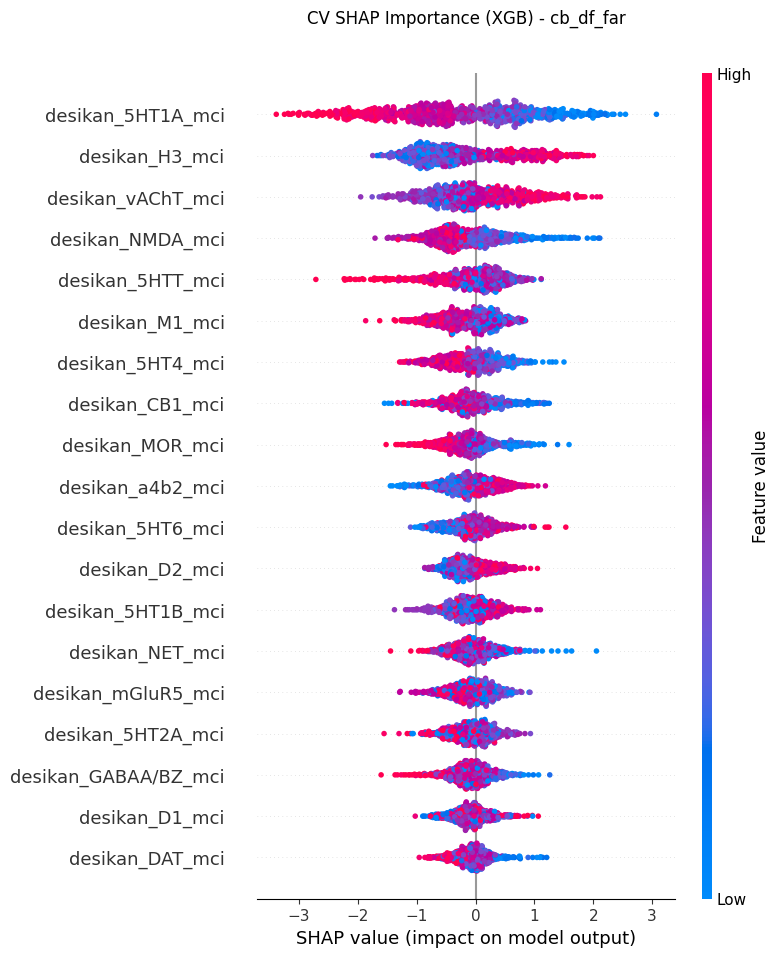

   Cb_df_far LR accuracy  Cb_df_far XGB accuracy  Cb_df_far LR F1  \
0               0.689119                0.678756         0.594595   
1               0.630208                0.640625         0.589595   
2               0.692708                0.703125         0.520325   
3               0.656250                0.682292         0.535211   
4               0.708333                0.713542         0.490909   

   Cb_df_far XGB F1  Cb_df_far LR Sensitivity  Cb_df_far XGB Sensitivity  \
0          0.425926                  0.602740                   0.315068   
1          0.439024                  0.645570                   0.341772   
2          0.457143                  0.615385                   0.461538   
3          0.469565                  0.703704                   0.500000   
4          0.485981                  0.529412                   0.509804   

   Cb_df_far LR AUC-PR  Cb_df_far XGB AUC-PR  
0             0.659721              0.560929  
1             0.619788            

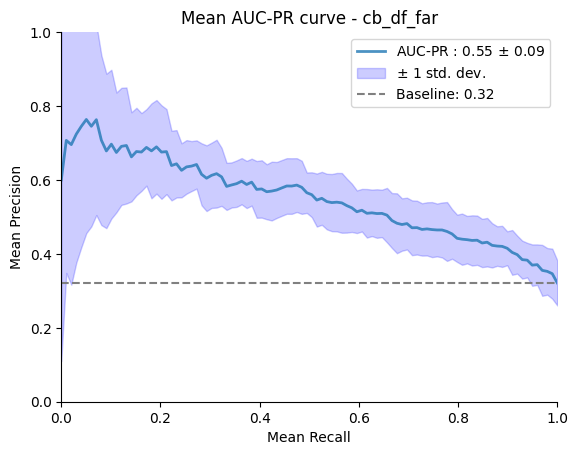

Fold 0 - cb_df_near
Fold 1 - cb_df_near
Fold 2 - cb_df_near
Fold 3 - cb_df_near
Fold 4 - cb_df_near
XGB SHAP INCOMING...
(961, 19)


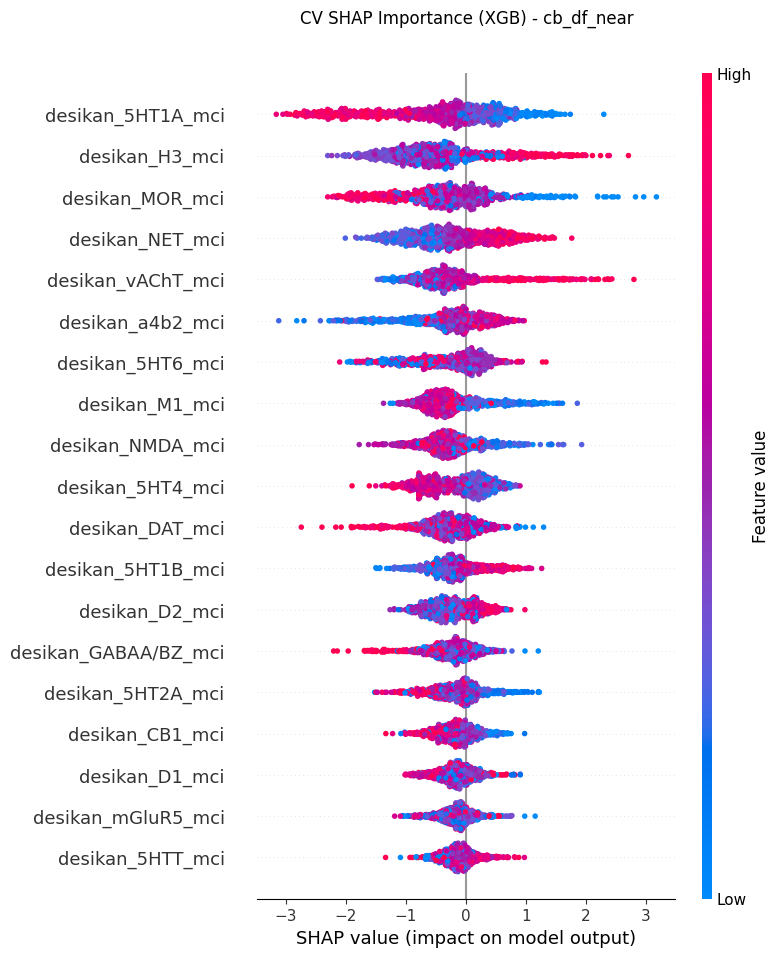

   Cb_df_near LR accuracy  Cb_df_near XGB accuracy  Cb_df_near LR F1  \
0                0.668394                 0.839378          0.372549   
1                0.604167                 0.828125          0.296296   
2                0.677083                 0.864583          0.225000   
3                0.708333                 0.817708          0.416667   
4                0.729167                 0.812500          0.333333   

   Cb_df_near XGB F1  Cb_df_near LR Sensitivity  Cb_df_near XGB Sensitivity  \
0           0.114286                   0.760000                    0.080000   
1           0.153846                   0.571429                    0.107143   
2           0.187500                   0.450000                    0.150000   
3           0.000000                   0.769231                    0.000000   
4           0.181818                   0.590909                    0.181818   

   Cb_df_near LR AUC-PR  Cb_df_near XGB AUC-PR  
0              0.361657               0.186

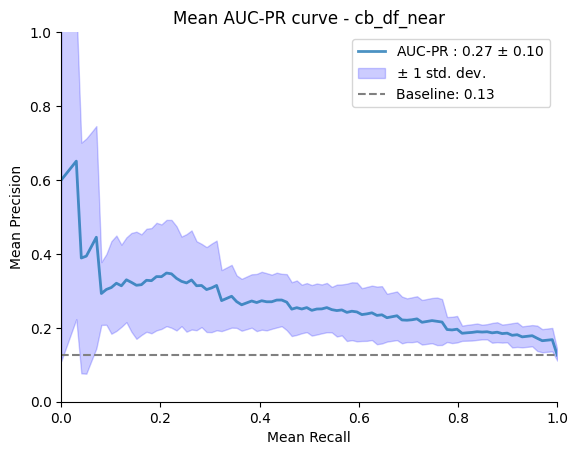

In [14]:
import pandas as pd
import numpy as np
import os
import sklearn
import shap
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import precision_recall_curve, auc, accuracy_score, f1_score, recall_score, average_precision_score
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from matplotlib import font_manager


font_path = "C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_housekeeping/arial.ttf"
font_manager.fontManager.addfont(font_path)


scaler = StandardScaler()

seed = 42

kf = KFold()

lr = LogisticRegression(random_state = seed, class_weight = 'balanced')

X_cols = ['desikan_D1_mci', 'desikan_D2_mci', 'desikan_DAT_mci', 'desikan_NET_mci', 'desikan_5HT1A_mci', 'desikan_5HT1B_mci', 'desikan_5HT2A_mci', 'desikan_5HT4_mci', 'desikan_5HT6_mci', 'desikan_5HTT_mci', 'desikan_a4b2_mci', 'desikan_M1_mci', 'desikan_vAChT_mci', 'desikan_NMDA_mci', 'desikan_mGluR5_mci', 'desikan_GABAA/BZ_mci', 'desikan_H3_mci', 'desikan_CB1_mci', 'desikan_MOR_mci']

cb_df_near = pd.read_csv('C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_housekeeping/cb_df_near.csv', low_memory = False)
cb_df_far = pd.read_csv('C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_housekeeping/cb_df_far.csv', low_memory = False)

for df, flag in [(cb_df_far, 'cb_df_far'), (cb_df_near, 'cb_df_near')]:
    X = df[X_cols]
    y = df['DIAGNOSIS_oth']
    xgb_balancer = float(y[y == 0].shape[0])/ float(y[y == 1].shape[0])
    xgb = XGBClassifier(random_state = seed, scale_pos_weight = xgb_balancer)

    accuracies_lr = []
    f1_scores_lr = []
    sensitivities_lr = []
    aucprs_lr = []
    
    accuracies_xgb = []
    f1_scores_xgb = []
    sensitivities_xgb = []
    aucprs_xgb = []
    
    list_test_sets = list()
    
    list_shap_values_xgb = list()
    
    ## For plotting an AUC-PR curve
    mean_recall = np.linspace(0,1,100)
    lr_precisions = []
    lr_aucprs = []

    for i, (train_index, test_index) in enumerate(kf.split(X)):
        print(f"Fold {i} - {flag}")
    
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train,y_test = y.iloc[train_index], y.iloc[test_index]
    
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
            
        lr.fit(X_train, y_train)
        xgb.fit(X_train, y_train)
    
        lr_pred_diags = lr.predict(X_test)
        xgb_pred_diags = xgb.predict(X_test)
    
        lr_pred_probas = lr.predict_proba(X_test)[:,1]
        xgb_pred_probas = xgb.predict_proba(X_test)[:,1]
    
        precision_lr, recall_lr, thresholds_lr = precision_recall_curve(y_test, lr_pred_probas)
        precision_xgb, recall_xgb, thresholds_xgb = precision_recall_curve(y_test, xgb_pred_probas)

        recalls_for_plotting = recall_lr[::-1]
        precisions_for_plotting = precision_lr[::-1]
        interp_precision = np.interp(mean_recall, recalls_for_plotting, precisions_for_plotting)
        lr_precisions.append(interp_precision)
        lr_aucprs.append(np.trapezoid(precisions_for_plotting, recalls_for_plotting))
        
        aucpr_lr = auc(recall_lr, precision_lr)
        aucprs_lr.append(aucpr_lr)
        aucpr_xgb = auc(recall_xgb, precision_xgb)
        aucprs_xgb.append(aucpr_xgb)

        acc_lr = accuracy_score(y_test, lr_pred_diags)
        accuracies_lr.append(acc_lr)
        acc_xgb = accuracy_score(y_test, xgb_pred_diags)
        accuracies_xgb.append(acc_xgb)

        
        f1_lr = f1_score(y_test, lr_pred_diags)
        f1_scores_lr.append(f1_lr)
        f1_xgb = f1_score(y_test, xgb_pred_diags)
        f1_scores_xgb.append(f1_xgb)
        
        sensitivity_lr = recall_score(y_test, lr_pred_diags)
        sensitivities_lr.append(sensitivity_lr)
        sensitivity_xgb = recall_score(y_test, xgb_pred_diags)
        sensitivities_xgb.append(sensitivity_xgb)
        
        list_test_sets.append(test_index)# A list of the order of test set indexes
        
        xgb_explainer = shap.TreeExplainer(xgb)
        xgb_shap_values = xgb_explainer.shap_values(X_test)
        list_shap_values_xgb.append(xgb_shap_values) # A list of shap values

        test_set = list_test_sets[0]
        shap_values_xgb = np.array(list_shap_values_xgb[0])
        
        #X_scaled_full = np.concatenate(list_X_test_scaled, axis=0)
    
    for n in range(1,len(list_test_sets)):
        test_set = np.concatenate((test_set,list_test_sets[n]),axis=0)
        shap_values_xgb = np.concatenate((shap_values_xgb, np.array(list_shap_values_xgb[n])),axis = 0)

    print('XGB SHAP INCOMING...')
    print(shap_values_xgb.shape)
    X_reordered = X.iloc[test_set]
    shap.summary_plot(shap_values_xgb, X_reordered, show=False)    
    plt.title(f'CV SHAP Importance (XGB) - {flag}', y=1.05)
    plt.savefig(f'C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_analysis/classifiers/xgb_shap_beeswarm_{flag}.png',dpi=600)
    plt.show()
    plt.close()

    flag_u = flag.capitalize()
    
    data = {
        f"{flag_u} LR accuracy": accuracies_lr,
        f"{flag_u} XGB accuracy": accuracies_xgb,
        f"{flag_u} LR F1": f1_scores_lr,
        f"{flag_u} XGB F1": f1_scores_xgb,
        f"{flag_u} LR Sensitivity": sensitivities_lr,
        f"{flag_u} XGB Sensitivity": sensitivities_xgb,
        f"{flag_u} LR AUC-PR": aucprs_lr,
        f"{flag_u} XGB AUC-PR": aucprs_xgb}
    
    df = pd.DataFrame(data)
    
    print(df)
    
    df.to_csv(f'C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_analysis/classifiers/fold_metrics_{flag}.csv', index = False)

    mean_precision = np.mean(lr_precisions, axis=0)
    std_precision  = np.std(lr_precisions, axis=0)
    
    mean_auprc = np.mean(lr_aucprs)
    std_auprc  = np.std(lr_aucprs)

    precision_upper = mean_precision + std_precision
    precision_lower = mean_precision - std_precision

    legend_mean_aucpr = df[f"{flag_u} LR AUC-PR"].mean()
    plt.plot(mean_recall, mean_precision,
            label = fr"AUC-PR : {legend_mean_aucpr:.2f} $\pm$ {df[f'{flag_u} LR AUC-PR'].std():.2f}",
            lw = 2,
            alpha = .8)
    
    plt.fill_between(mean_recall,
                     precision_lower, 
                     precision_upper, 
                     color = 'blue', 
                     alpha = 0.2, 
                     label = fr'$\pm$ 1 std. dev.')


    plt.hlines(y = mean_precision[-1], xmin = 0, xmax = 1, color = 'grey', linestyle = 'dashed', label = f'Baseline: {mean_precision[-1]:.2f}')
    plt.legend(loc = 'upper right')
    plt.ylim(0,1)
    plt.ylabel('Mean Precision')
    plt.xlabel('Mean Recall')
    plt.xlim(0,1)
    plt.title(f'Mean AUC-PR curve - {flag}')
    sns.despine()
    plt.savefig(f'C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_analysis/classifiers/avg_aucpr_{flag}.png', dpi = 600)
    plt.show()


#### 1. Was the classifier trained on near of far diagnoses better in metrics
#### 2. Identify if LR metrics beat XGB metrics
#### 3. Are the distributions of LR and XGB performances comparable?

In [20]:
import pandas as pd
import numpy as np
import os

root_path = '/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/classifiers/'

cb_df_near_metrics = pd.read_csv(os.path.join(root_path, 'fold_metrics_cb_df_near.csv'), low_memory = False)
cb_df_far_metrics = pd.read_csv(os.path.join(root_path, 'fold_metrics_cb_df_far.csv'), low_memory = False)

combined_df = cb_df_near_metrics.join(cb_df_far_metrics)

print(combined_df)

lr_accuracies = combined_df[['Cb_df_near LR accuracy', 'Cb_df_far LR accuracy']].mean()
lr_f1s = combined_df[['Cb_df_near LR F1', 'Cb_df_far LR F1']].mean()
lr_sensitvities = combined_df[['Cb_df_near LR Sensitivity', 'Cb_df_far LR Sensitivity']].mean()
lr_aucprs = combined_df[['Cb_df_near LR AUC-PR', 'Cb_df_far LR AUC-PR']].mean()

near_points = 0
far_points = 0

for n in [lr_accuracies, lr_f1s, lr_sensitvities, lr_aucprs]:
    print(n.idxmax(), n.max())
    if 'Cb_df_near' in n.idxmax().split(' '):
        near_points += 1
    if 'Cb_df_far' in n.idxmax().split(' '):
        far_points += 1

winner_name_dict_atlas = {
    near_points : 'CB Near',
    far_points : 'CB Far'
}

winner = max(near_points, far_points)

print(f"Winner is {winner_name_dict_atlas[winner]}, with {winner} points!")

## Going ahead with CB Far since it won in AUC-PR

   Cb_df_near LR accuracy  Cb_df_near XGB accuracy  Cb_df_near LR F1  \
0                0.668394                 0.839378          0.372549   
1                0.604167                 0.828125          0.296296   
2                0.677083                 0.864583          0.225000   
3                0.708333                 0.817708          0.416667   
4                0.729167                 0.812500          0.333333   

   Cb_df_near XGB F1  Cb_df_near LR Sensitivity  Cb_df_near XGB Sensitivity  \
0           0.114286                   0.760000                    0.080000   
1           0.153846                   0.571429                    0.107143   
2           0.187500                   0.450000                    0.150000   
3           0.000000                   0.769231                    0.000000   
4           0.181818                   0.590909                    0.181818   

   Cb_df_near LR AUC-PR  Cb_df_near XGB AUC-PR  Cb_df_far LR accuracy  \
0              0.36

In [21]:
import pandas as pd
import numpy as np
import os

cb_df_far_metrics = pd.read_csv(os.path.join(root_path, 'fold_metrics_cb_df_far.csv'), low_memory = False)

accuracies = cb_df_far_metrics[['Cb_df_far LR accuracy', 'Cb_df_far XGB accuracy']]
f1s = cb_df_far_metrics[['Cb_df_far LR F1', 'Cb_df_far XGB F1']]
sensitivities = cb_df_far_metrics[['Cb_df_far LR Sensitivity', 'Cb_df_far XGB Sensitivity']]
aucprs = cb_df_far_metrics[['Cb_df_far XGB AUC-PR', 'Cb_df_far XGB AUC-PR']]

for n in [accuracies, f1s, sensitivities, aucprs]:
    n = n.mean()
    print(n.idxmax(), n.max())
    # So XGB edges out in AUC-PR: let's see if the performances are of similar distributions...

Cb_df_far XGB accuracy 0.6836679620034541
Cb_df_far LR F1 0.546127106416779
Cb_df_far LR Sensitivity 0.6193618860149527
Cb_df_far XGB AUC-PR 0.48362432854670007


In [1]:
import pandas as pd
import numpy as np
import os
import scipy
from scipy.stats import wilcoxon, ttest_rel, levene, kstest
import pingouin as pg
from pingouin import compute_effsize

files = ['fold_metrics_cb_df_near', 'fold_metrics_cb_df_far']

for file in files:

    df = pd.read_csv(os.path.join(f'C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_analysis/classifiers/{file}.csv'), low_memory = False)

    accuracies = df[[col for col in df.columns.tolist() if 'accuracy' in col]]
    f1s = df[[col for col in df.columns.tolist() if 'F1' in col]]
    sensitivities = df[[col for col in df.columns.tolist() if 'Sensitivity' in col]]
    aucprs = df[[col for col in df.columns.tolist() if 'AUC-PR' in col]]

    thresh = len([accuracies, f1s, sensitivities, aucprs])
    
    for n in [accuracies, f1s, sensitivities, aucprs]:
        print(n)
        print(n.values[:,0], n.values[:,1])
        print(n.values[:,0], n.values[:,1])
        _, p_levene = levene(n.values[:,0], n.values[:,1])
        equal_var = p_levene > 0.05

        # 2. Kolmogorov-Smirnov Test for Normality (standardized)
        is_normal = True
        for g in [n.values[:,0], n.values[:,1]]:
            standardised_group = (g - g.mean()) / g.std()
            _, p_ks = kstest(standardised_group, 'norm')
            if p_ks < 0.05:
                is_normal = False
                break

        # 3. Pairwise test
        if is_normal and equal_var:
            test_name = "Paired t-test"
            result = ttest_rel(n.values[:,0], n.values[:,1])
        elif is_normal and not equal_var:
            test_name = "Paired t-test"
            result = ttest_rel(n.values[:,0], n.values[:,1])
        else:
            test_name = "Wilcoxon signed-rank test"
            result = wilcoxon(n.values[:,0], n.values[:,1])

        print(result, test_name, is_normal, equal_var)
        print(f'Raw p-value = {result.pvalue}. Adjusted by n = 4: {float(result.pvalue * thresh)}')
        print(bool(float(result.pvalue) < 0.05))# Prints adjusted p value. Threshold is 4 - for each set of metrics
        print(bool(float(result.pvalue * thresh) < 0.05))# Prints adjusted p value. Threshold is 4 - for each set of metrics
        hedges_g = pg.compute_effsize(n.values[:,0], n.values[:,1], paired = True, eftype='hedges')
        print(f"Hedges' g: {hedges_g}")
        print(' ')

   Cb_df_near LR accuracy  Cb_df_near XGB accuracy
0                0.668394                 0.839378
1                0.604167                 0.828125
2                0.677083                 0.864583
3                0.708333                 0.817708
4                0.729167                 0.812500
[0.66839378 0.60416667 0.67708333 0.70833333 0.72916667] [0.83937824 0.828125   0.86458333 0.81770833 0.8125    ]
[0.66839378 0.60416667 0.67708333 0.70833333 0.72916667] [0.83937824 0.828125   0.86458333 0.81770833 0.8125    ]
TtestResult(statistic=np.float64(-6.015263444263525), pvalue=np.float64(0.0038465428864619088), df=np.int64(4)) Paired t-test True True
Raw p-value = 0.0038465428864619088. Adjusted by n = 4: 0.015386171545847635
True
True
Hedges' g: -3.8118432707045256
 
   Cb_df_near LR F1  Cb_df_near XGB F1
0          0.372549           0.114286
1          0.296296           0.153846
2          0.225000           0.187500
3          0.416667           0.000000
4          0.33

#### Identify optimum set of features based on AUC-PR

In [23]:
import pandas as pd
import numpy as np
import os
import sklearn
import shap
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import precision_recall_curve, auc, accuracy_score, f1_score, recall_score, average_precision_score, make_scorer
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import RFECV

scaler = StandardScaler()

seed = 42

lr = LogisticRegression(random_state = seed, class_weight = 'balanced')

mypipeline = Pipeline([
    ('Scaler', scaler),
    ('Classifier', lr)
], verbose = False)

def aucpr(y_true, y_proba):
    precision, recall, _ = precision_recall_curve(y_true, y_proba)
    return auc(recall, precision)

scorer = make_scorer(aucpr, response_method = 'predict_proba')

selector = RFECV(estimator = mypipeline, cv=5, scoring = scorer, importance_getter='named_steps.Classifier.coef_' )

X_cols = ['desikan_D1_mci', 'desikan_D2_mci', 'desikan_DAT_mci', 'desikan_NET_mci', 'desikan_5HT1A_mci', 'desikan_5HT1B_mci', 'desikan_5HT2A_mci', 'desikan_5HT4_mci', 'desikan_5HT6_mci', 'desikan_5HTT_mci', 'desikan_a4b2_mci', 'desikan_M1_mci', 'desikan_vAChT_mci', 'desikan_NMDA_mci', 'desikan_mGluR5_mci', 'desikan_GABAA/BZ_mci', 'desikan_H3_mci', 'desikan_CB1_mci', 'desikan_MOR_mci']

### RFECV time!

for df, flag in [(cb_df_far, 'cb_df_far'), (cb_df_near, 'cb_df_near')]:
    X = df[X_cols]
    y = df['DIAGNOSIS_oth']
    selector = selector.fit(X, y)
    selected_cols_arr = np.array(X_cols)
    
    print(f"Optimal number of features ({flag}) based on AUC-PR = {selector.n_features_}. Selected features: {selected_cols_arr[selector.support_]}")
    print(f'Average AUC-PRs across folds for each set of n features (1-19): {selector.cv_results_['mean_test_score']}. Max score was for {int(selector.cv_results_['mean_test_score'].argmax()) + 1}')
    print('')

Optimal number of features (cb_df_far) based on AUC-PR = 17. Selected features: ['desikan_D1_mci' 'desikan_D2_mci' 'desikan_DAT_mci' 'desikan_NET_mci'
 'desikan_5HT1A_mci' 'desikan_5HT2A_mci' 'desikan_5HT4_mci'
 'desikan_5HTT_mci' 'desikan_a4b2_mci' 'desikan_M1_mci'
 'desikan_vAChT_mci' 'desikan_NMDA_mci' 'desikan_mGluR5_mci'
 'desikan_GABAA/BZ_mci' 'desikan_H3_mci' 'desikan_CB1_mci'
 'desikan_MOR_mci']
Average AUC-PRs across folds for each set of n features (1-19): [0.50843941 0.53482055 0.53655291 0.53018192 0.54871902 0.54443653
 0.54611918 0.55055328 0.54816318 0.5452535  0.54872231 0.55417461
 0.54997425 0.55238817 0.5537634  0.55536371 0.55647166 0.55501739
 0.55484662]. Max score was for 17

Optimal number of features (cb_df_near) based on AUC-PR = 19. Selected features: ['desikan_D1_mci' 'desikan_D2_mci' 'desikan_DAT_mci' 'desikan_NET_mci'
 'desikan_5HT1A_mci' 'desikan_5HT1B_mci' 'desikan_5HT2A_mci'
 'desikan_5HT4_mci' 'desikan_5HT6_mci' 'desikan_5HTT_mci'
 'desikan_a4b2_mci' '

### Feature selection for cb_df_far only

2.1100323624595467
Fold 0:
Fold 1:
Fold 2:
Fold 3:
Fold 4:
FEATURE SELECTED XGB SHAP INCOMING...
(961, 17)


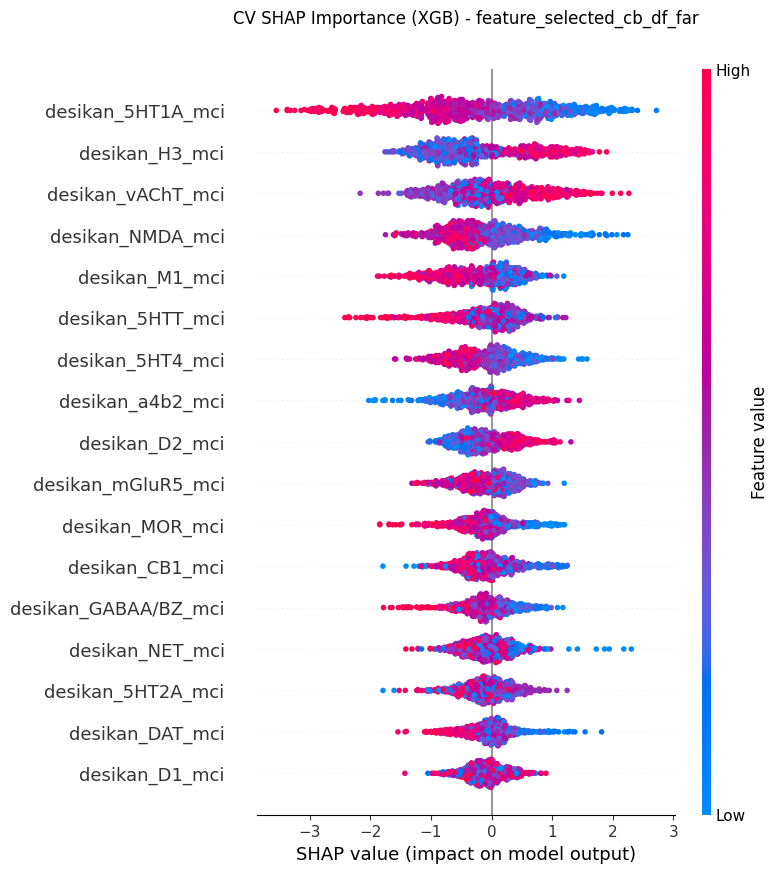

{'Feature_selected_cb_df_far_fs LR accuracy': [0.6839378238341969, 0.6354166666666666, 0.6927083333333334, 0.65625, 0.7083333333333334], 'Feature_selected_cb_df_far_fs XGB accuracy': [0.6787564766839378, 0.609375, 0.734375, 0.6875, 0.7291666666666666], 'Feature_selected_cb_df_far_fs LR F1': [0.5850340136054422, 0.5930232558139535, 0.528, 0.5352112676056338, 0.5], 'Feature_selected_cb_df_far_fs XGB F1': [0.44642857142857145, 0.43609022556390975, 0.5321100917431193, 0.4827586206896552, 0.5], 'Feature_selected_cb_df_far_fs LR Sensitivity': [0.589041095890411, 0.6455696202531646, 0.6346153846153846, 0.7037037037037037, 0.5490196078431373], 'Feature_selected_cb_df_far_fs XGB Sensitivity': [0.3424657534246575, 0.3670886075949367, 0.5576923076923077, 0.5185185185185185, 0.5098039215686274], 'Feature_selected_cb_df_far_fs LR AUC-PR': [0.6609535796591903, 0.6185916651278345, 0.4197062814926985, 0.5356389469231975, 0.5309394495147784], 'Feature_selected_cb_df_far_fs XGB AUC-PR': [0.5647173695488

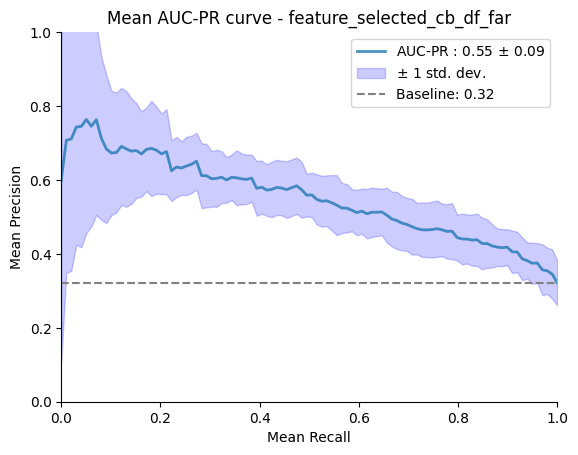

In [24]:
import pandas as pd
import numpy as np
import os
import sklearn
import shap
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import precision_recall_curve, auc, accuracy_score, f1_score, recall_score, average_precision_score
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score 
from matplotlib import font_manager

font_path = "/rds/general/user/sk4724/home/arial.ttf"
font_manager.fontManager.addfont(font_path)

scaler = StandardScaler()

seed = 42

kf = KFold()

lr = LogisticRegression(random_state = seed, class_weight = 'balanced')

X = pd.read_csv('/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/cb_df_far.csv', low_memory = False)
y = X['DIAGNOSIS_oth']
selected_cols = ['desikan_D1_mci', 'desikan_D2_mci', 'desikan_DAT_mci', 'desikan_NET_mci', 
                 'desikan_5HT1A_mci', 'desikan_5HT2A_mci', 'desikan_5HT4_mci', 'desikan_5HTT_mci',
                 'desikan_a4b2_mci', 'desikan_M1_mci', 'desikan_vAChT_mci',
                 'desikan_NMDA_mci', 'desikan_mGluR5_mci', 'desikan_GABAA/BZ_mci', 'desikan_H3_mci',
                 'desikan_CB1_mci','desikan_MOR_mci']
flag = 'feature_selected_cb_df_far'
X = X[selected_cols]

xgb_balancer = float(y[y == 0].shape[0])/ float(y[y == 1].shape[0])
print(xgb_balancer)

## Instantiate xgb with the balancer - mitigates class imbalance

xgb = XGBClassifier(random_state = seed, scale_pos_weight = xgb_balancer)

accuracies_lr = []
f1_scores_lr = []
sensitivities_lr = []
aucprs_lr = []

accuracies_xgb = []
f1_scores_xgb = []
sensitivities_xgb = []
aucprs_xgb = []

list_test_sets = list()

list_shap_values_xgb = list()

list_X_test_scaled = []

## For plotting an AUC-PR curve
mean_recall = np.linspace(0,1,100)
lr_precisions = []
lr_aucprs = []

for i, (train_index, test_index) in enumerate(kf.split(X)):
    print(f"Fold {i}:")

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train,y_test = y.iloc[train_index], y.iloc[test_index]

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    list_X_test_scaled.append(X_test)
        
    lr.fit(X_train, y_train)
    xgb.fit(X_train, y_train)

    lr_pred_diags = lr.predict(X_test)
    xgb_pred_diags = xgb.predict(X_test)

    lr_pred_probas = lr.predict_proba(X_test)[:,1]
    xgb_pred_probas = xgb.predict_proba(X_test)[:,1]

    precision_lr, recall_lr, thresholds_lr = precision_recall_curve(y_test, lr_pred_probas)
    precision_xgb, recall_xgb, thresholds_xgb = precision_recall_curve(y_test, xgb_pred_probas)

    ## For plotting
    recalls_for_plotting = recall_lr[::-1]
    precisions_for_plotting = precision_lr[::-1]
    interp_precision = np.interp(mean_recall, recalls_for_plotting, precisions_for_plotting)
    lr_precisions.append(interp_precision)
    lr_aucprs.append(np.trapezoid(precisions_for_plotting, recalls_for_plotting))
        
    aucpr_lr = auc(recall_lr, precision_lr)
    aucprs_lr.append(aucpr_lr)
    aucpr_xgb = auc(recall_xgb, precision_xgb)
    aucprs_xgb.append(aucpr_xgb)

    
    acc_lr = accuracy_score(y_test, lr_pred_diags)
    accuracies_lr.append(acc_lr)
    acc_xgb = accuracy_score(y_test, xgb_pred_diags)
    accuracies_xgb.append(acc_xgb)
    
    f1_lr = f1_score(y_test, lr_pred_diags)
    f1_scores_lr.append(f1_lr)
    f1_xgb = f1_score(y_test, xgb_pred_diags)
    f1_scores_xgb.append(f1_xgb)

    sensitivity_lr = recall_score(y_test, lr_pred_diags)
    sensitivities_lr.append(sensitivity_lr)
    sensitivity_xgb = recall_score(y_test, xgb_pred_diags)
    sensitivities_xgb.append(sensitivity_xgb)

    list_test_sets.append(test_index)# A list of the order of test set indexes

    xgb_explainer = shap.TreeExplainer(xgb)
    xgb_shap_values = xgb_explainer.shap_values(X_test)
    list_shap_values_xgb.append(xgb_shap_values) # A list of shap values
    
test_set = list_test_sets[0]
shap_values_xgb = np.array(list_shap_values_xgb[0])

X_scaled_full = np.concatenate(list_X_test_scaled, axis=0)
for n in range(1,len(list_test_sets)):
    test_set = np.concatenate((test_set,list_test_sets[n]),axis=0)
    shap_values_xgb = np.concatenate((shap_values_xgb, np.array(list_shap_values_xgb[n])),axis = 0)

print('FEATURE SELECTED XGB SHAP INCOMING...')
print(shap_values_xgb.shape)
X_reordered = X.iloc[test_set]
shap.summary_plot(shap_values_xgb, X_reordered, show=False)    
plt.title(f'CV SHAP Importance (XGB) - {flag}', y=1.05)
plt.savefig(f'/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/classifiers/feature_selected_xgb_shap_beeswarm_{flag}.png',dpi=600)
plt.show()
plt.close()



flag_u = flag.capitalize()+'_fs'

data = {
    f"{flag_u} LR accuracy": accuracies_lr,
    f"{flag_u} XGB accuracy": accuracies_xgb,
    f"{flag_u} LR F1": f1_scores_lr,
    f"{flag_u} XGB F1": f1_scores_xgb,
    f"{flag_u} LR Sensitivity": sensitivities_lr,
    f"{flag_u} XGB Sensitivity": sensitivities_xgb,
    f"{flag_u} LR AUC-PR": aucprs_lr,
    f"{flag_u} XGB AUC-PR": aucprs_xgb}

print(data)

for key, vals in data.items():
    print(key, len(vals))

df = pd.DataFrame(data)

df.to_csv(f'/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/classifiers/feature_selected_fold_metrics_{flag}.csv', index = False)

mean_precision = np.mean(lr_precisions, axis=0)
std_precision  = np.std(lr_precisions, axis=0)

mean_auprc = np.mean(lr_aucprs)
std_auprc  = np.std(lr_aucprs)

precision_upper = mean_precision + std_precision
precision_lower = mean_precision - std_precision

legend_mean_aucpr = df[f"{flag_u} LR AUC-PR"].mean()
plt.plot(mean_recall, mean_precision,
        label = fr"AUC-PR : {legend_mean_aucpr:.2f} $\pm$ {df[f"{flag_u} LR AUC-PR"].std():.2f}",
        lw = 2,
        alpha = .8)

plt.fill_between(mean_recall,
                 precision_lower, 
                 precision_upper, 
                 color = 'blue', 
                 alpha = 0.2, 
                 label = fr'$\pm$ 1 std. dev.')


plt.hlines(y = mean_precision[-1], xmin = 0, xmax = 1, color = 'grey', linestyle = 'dashed', label = f'Baseline: {mean_precision[-1]:.2f}')
plt.legend(loc = 'upper right')
plt.ylim(0,1)
plt.ylabel('Mean Precision')
plt.xlabel('Mean Recall')
plt.xlim(0,1)
plt.title(f'Mean AUC-PR curve - {flag}')
sns.despine()
plt.savefig(f'/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/classifiers/avg_aucpr_{flag}.png', dpi = 300)
plt.show()
            

#### 1. Was the classifier trained on selected features better
#### 2. Identify if LR metrics beat XGB metrics
#### 3. Are the distributions of LR and XGB performances comparable?

In [29]:
import pandas as pd
import numpy as np
import os

root_path = '/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/classifiers/'

cb_df_far_metrics = pd.read_csv(os.path.join(root_path, 'fold_metrics_cb_df_far.csv'), low_memory = False)
cb_df_far_fs_metrics = pd.read_csv(os.path.join(root_path, 'feature_selected_fold_metrics_feature_selected_cb_df_far.csv'), low_memory = False)

combined_df = cb_df_far_fs_metrics.join(cb_df_far_metrics)

print(combined_df)

lr_accuracies = combined_df[['Feature_selected_cb_df_far_fs LR accuracy', 'Cb_df_far LR accuracy']].mean()
lr_f1s = combined_df[['Feature_selected_cb_df_far_fs LR F1', 'Cb_df_far LR F1']].mean()
lr_sensitvities = combined_df[['Feature_selected_cb_df_far_fs LR Sensitivity', 'Cb_df_far LR Sensitivity']].mean()
lr_aucprs = combined_df[['Feature_selected_cb_df_far_fs LR AUC-PR', 'Cb_df_far LR AUC-PR']].mean()

fs_points = 0
norm_points = 0

for n in [lr_accuracies, lr_f1s, lr_sensitvities, lr_aucprs]:
    print(n.idxmax(), n.max())
    if 'Feature_selected_cb_df_far_fs' in n.idxmax().split(' '):
        fs_points += 1
    if 'Cb_df_far' in n.idxmax().split(' '):
        norm_points += 1

winner_name_dict_atlas = {
    fs_points : 'Feature Selected',
    norm_points : 'Non-feature selected'
}

winner = max(fs_points, norm_points)

print(f"Winner is {winner_name_dict_atlas[winner]}, with {winner} points!")
print(combined_df.mean())

   Feature_selected_cb_df_far_fs LR accuracy  \
0                                   0.683938   
1                                   0.635417   
2                                   0.692708   
3                                   0.656250   
4                                   0.708333   

   Feature_selected_cb_df_far_fs XGB accuracy  \
0                                    0.678756   
1                                    0.609375   
2                                    0.734375   
3                                    0.687500   
4                                    0.729167   

   Feature_selected_cb_df_far_fs LR F1  Feature_selected_cb_df_far_fs XGB F1  \
0                             0.585034                              0.446429   
1                             0.593023                              0.436090   
2                             0.528000                              0.532110   
3                             0.535211                              0.482759   
4               

In [30]:
import pandas as pd
import numpy as np
import os

root_path = '/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/classifiers/'
cb_df_far_fs_metrics = pd.read_csv(os.path.join(root_path, 'feature_selected_fold_metrics_feature_selected_cb_df_far.csv'), low_memory = False)

accuracies = cb_df_far_fs_metrics[['Feature_selected_cb_df_far_fs LR accuracy', 'Feature_selected_cb_df_far_fs XGB accuracy']]
f1s = cb_df_far_fs_metrics[['Feature_selected_cb_df_far_fs LR F1', 'Feature_selected_cb_df_far_fs XGB F1']]
sensitivities = cb_df_far_fs_metrics[['Feature_selected_cb_df_far_fs LR Sensitivity', 'Feature_selected_cb_df_far_fs XGB Sensitivity']]
aucprs = cb_df_far_fs_metrics[['Feature_selected_cb_df_far_fs XGB AUC-PR', 'Feature_selected_cb_df_far_fs XGB AUC-PR']]

for n in [accuracies, f1s, sensitivities, aucprs]:
    n = n.mean()
    print(n.idxmax(), n.max())
    # So XGB edges out in AUC-PR: let's see if the performances are of similar distributions...

Feature_selected_cb_df_far_fs XGB accuracy 0.6878346286701208
Feature_selected_cb_df_far_fs LR F1 0.5482537074050059
Feature_selected_cb_df_far_fs LR Sensitivity 0.6243898824611602
Feature_selected_cb_df_far_fs XGB AUC-PR 0.49678370028630614


In [31]:
import pandas as pd
import numpy as np
import os
import scipy
from scipy.stats import wilcoxon

root_path = '/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/classifiers/'
df = pd.read_csv(os.path.join(root_path, 'feature_selected_fold_metrics_feature_selected_cb_df_far.csv'), low_memory = False)

accuracies = df[[col for col in df.columns.tolist() if 'accuracy' in col]]
f1s = df[[col for col in df.columns.tolist() if 'F1' in col]]
sensitivities = df[[col for col in df.columns.tolist() if 'Sensitivity' in col]]
aucprs = df[[col for col in df.columns.tolist() if 'AUC-PR' in col]]

thresh = len([accuracies, f1s, sensitivities, aucprs])

for n in [accuracies, f1s, sensitivities, aucprs]:
    print(n)
    print(n.values[:,0], n.values[:,1])
    res = wilcoxon(n.values[:,0], n.values[:,1])
    print(f'Raw p-value = {res.pvalue}. Adjusted by n = 12 : {float(res.pvalue * (thresh * 3))}. Adjusted by n = 4: {float(res.pvalue * thresh)}')
    print(bool(float(res.pvalue * (thresh * 3)) < 0.05)) # Prints adjusted p value. Threshold is 12 - more strict
    print(bool(float(res.pvalue * thresh) < 0.05))# Prints adjusted p value. Threshold is 4 - for each set of metrics
    print(' ')

   Feature_selected_cb_df_far_fs LR accuracy  \
0                                   0.683938   
1                                   0.635417   
2                                   0.692708   
3                                   0.656250   
4                                   0.708333   

   Feature_selected_cb_df_far_fs XGB accuracy  
0                                    0.678756  
1                                    0.609375  
2                                    0.734375  
3                                    0.687500  
4                                    0.729167  
[0.68393782 0.63541667 0.69270833 0.65625    0.70833333] [0.67875648 0.609375   0.734375   0.6875     0.72916667]
Raw p-value = 0.4375. Adjusted by n = 12 : 5.25. Adjusted by n = 4: 1.75
False
False
 
   Feature_selected_cb_df_far_fs LR F1  Feature_selected_cb_df_far_fs XGB F1
0                             0.585034                              0.446429
1                             0.593023                              

#### Heatmap for feature-selected beta coefficients

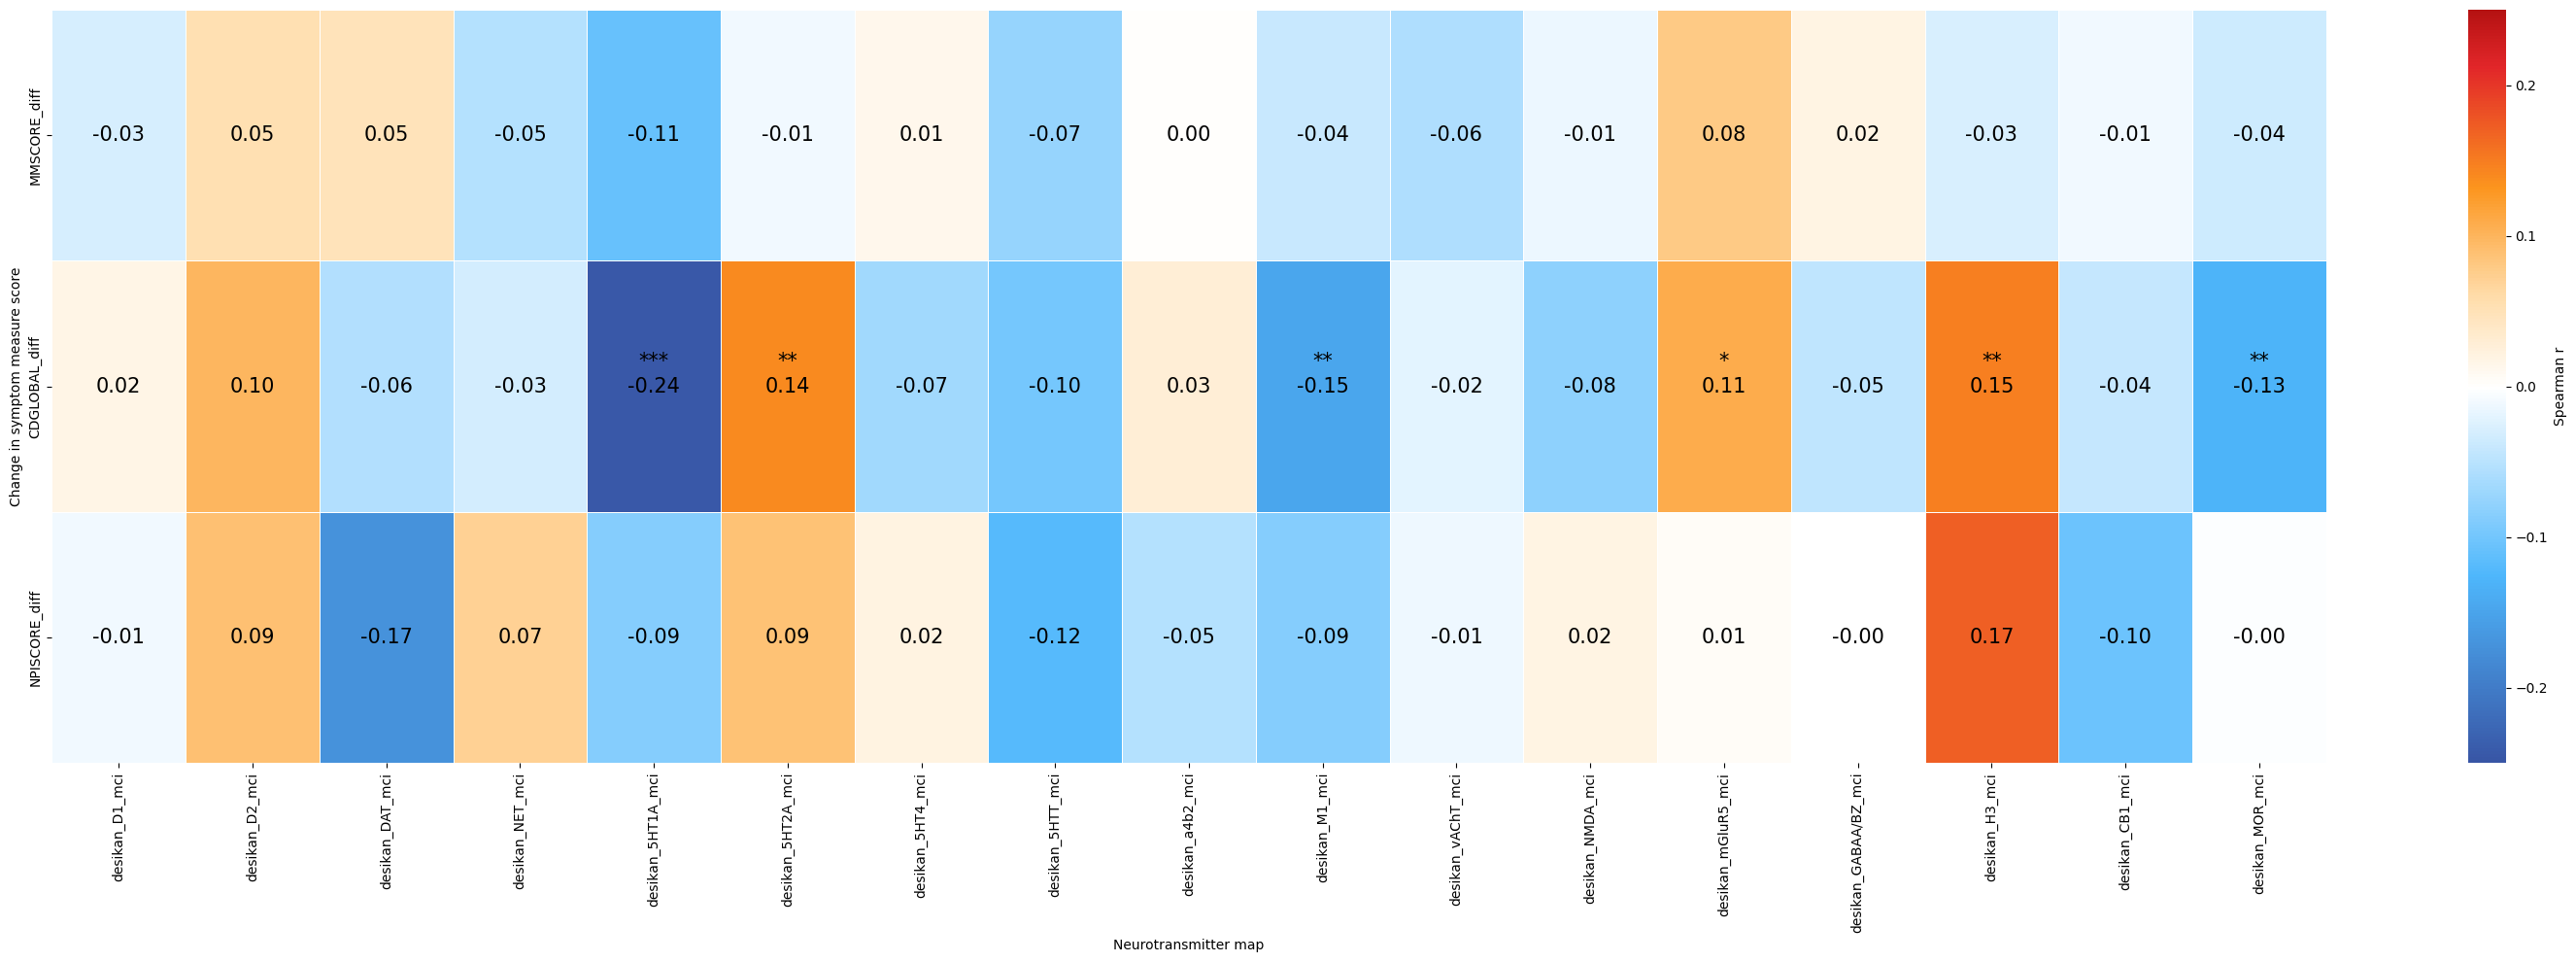

MMSCORE_diff: no significant associations after correction
CDGLOBAL_diff
Top feature: desikan_5HT1A_mci
Spearman r: -0.244
p-value (FDR): 1.934e-09
NPISCORE_diff: no significant associations after correction


In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from statsmodels.stats import multitest
from matplotlib.colors import ListedColormap
from matplotlib import font_manager

font_path = "/rds/general/user/sk4724/home/arial.ttf"
font_manager.fontManager.addfont(font_path)

def get_significance_stars(p_value):
    if p_value <= 0.001: return '***'
    elif p_value <= 0.01: return '**'
    elif p_value <= 0.05: return '*'
    else: return ''

outdir = '/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/heatmaps'
os.makedirs(outdir, exist_ok=True)

df = pd.read_csv(
    '/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/cb_df_far.csv',
    low_memory=False
)



coeff_cols = ['desikan_D1_mci', 'desikan_D2_mci', 'desikan_DAT_mci', 'desikan_NET_mci', 
              'desikan_5HT1A_mci', 'desikan_5HT2A_mci', 'desikan_5HT4_mci',
              'desikan_5HTT_mci', 'desikan_a4b2_mci', 'desikan_M1_mci',
              'desikan_vAChT_mci', 'desikan_NMDA_mci', 'desikan_mGluR5_mci',
              'desikan_GABAA/BZ_mci', 'desikan_H3_mci', 'desikan_CB1_mci',
              'desikan_MOR_mci']
symptom_cols = ['MMSCORE_diff', 'CDGLOBAL_diff', 'NPISCORE_diff']

cmap = np.genfromtxt(
    '/rds/general/project/c3nl_scott_students/live/sankeith/standards/colourmap.csv',
    delimiter=','
)
cmap_div = ListedColormap(cmap)

df_subset = df[coeff_cols + symptom_cols]

r_values = pd.DataFrame(index=coeff_cols, columns=symptom_cols, dtype=float)
p_values = pd.DataFrame(index=coeff_cols, columns=symptom_cols, dtype=float)

for coeff in coeff_cols:
    for symp in symptom_cols:
        tmp = df_subset[[coeff, symp]].copy()
        tmp = tmp[tmp[symp] >= 0].dropna()
        
        if len(tmp) > 1:
            r, p = spearmanr(tmp[coeff], tmp[symp])
        else:
            r, p = np.nan, np.nan

        r_values.loc[coeff, symp] = r
        p_values.loc[coeff, symp] = p

r_values = r_values.transpose()
p_values = p_values.transpose()

p_flat = p_values.values.flatten()
mask = ~np.isnan(p_flat)

p_corr = np.full_like(p_flat, np.nan)
p_corr[mask] = multitest.multipletests(p_flat[mask], method='fdr_bh')[1]

p_values = pd.DataFrame(
    p_corr.reshape(p_values.shape),
    index=p_values.index,
    columns=p_values.columns
)

plt.figure(figsize=(30, 10))

ax = sns.heatmap(
    r_values,
    annot=True,
    fmt=".2f",
    cmap=cmap_div,
    center=0,
    vmin=-0.25,
    vmax=0.25,
    cbar_kws={'label': "Spearman r"},
    annot_kws={'color': 'black', 'fontsize': 15, 'va': 'center'},
    linewidths=0.5,
    linecolor='white'
)

n_rows, n_cols = r_values.shape

for y in range(n_rows):
    for x in range(n_cols):
        r = r_values.iloc[y, x]
        p = p_values.iloc[y, x]

        if not np.isnan(r) and not np.isnan(p):
            stars = get_significance_stars(p)

            if stars:
                ax.text(
                    x + 0.5,     # center of cell (x)
                    y + 0.4,    # slightly above rho
                    stars,
                    ha='center',
                    va='center',
                    fontsize=15,
                    color='black'
                )

plt.xlabel('Neurotransmitter map')
plt.ylabel('Change in symptom measure score')
plt.tight_layout()

plt.savefig(f"{outdir}/feature_select_cb_far_spearman_heatmap.png", dpi=300)

plt.show()

alpha = 0.05  # significance threshold (after FDR)

for symp in r_values.index:
    r_row = r_values.loc[symp]
    p_row = p_values.loc[symp]

    summary_df = pd.DataFrame({
        'rho': r_row,
        'abs_rho': r_row.abs(),
        'pval': p_row
    })

    # keep only significant results
    summary_df = summary_df[summary_df['pval'] <= alpha]

    if summary_df.empty:
        print(f"{symp}: no significant associations after correction")
        continue

    # sort by absolute rho
    summary_df = summary_df.sort_values(by='abs_rho', ascending=False)

    top = summary_df.iloc[0]
    
    print(symp)
    print(f"Top feature: {top.name}")
    print(f"Spearman r: {top['rho']:.3f}")
    print(f"p-value (FDR): {top['pval']:.3e}")

#### Partial correlations (accounting for VISDATE_diff) between beta coefficients at original diagnosis and symptom change
#### Scatter plots should have x axis of beta coeff and y axis of symptom change. Include spearman's rho

In [22]:
%%bash

mkdir -p /rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/cb_symptoms

In [33]:
import pandas as pd
import numpy as np
import os
import sklearn
import shap
import matplotlib.pyplot as plt 
import seaborn as sns
import pingouin as pg
from datetime import datetime
import statsmodels
from statsmodels.stats import multitest
from matplotlib import font_manager

font_path = "/rds/general/user/sk4724/home/arial.ttf"
font_manager.fontManager.addfont(font_path)

 

df = pd.read_csv('/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/cb_df_far.csv', low_memory = False)
coeff_cols = ['desikan_D1_mci', 'desikan_D2_mci', 'desikan_DAT_mci', 'desikan_NET_mci', 'desikan_5HT1A_mci', 'desikan_5HT1B_mci', 'desikan_5HT2A_mci', 'desikan_5HT4_mci', 'desikan_5HT6_mci', 'desikan_5HTT_mci', 'desikan_a4b2_mci', 'desikan_M1_mci', 'desikan_vAChT_mci', 'desikan_NMDA_mci',	'desikan_mGluR5_mci', 'desikan_GABAA/BZ_mci', 'desikan_H3_mci', 'desikan_CB1_mci', 'desikan_MOR_mci']

selected_cols = coeff_cols + ['DIAGNOSIS_oth', 'MMSCORE_diff', 'NPISCORE_diff', 'CDGLOBAL_diff', 'VISDATE_diff']
df = df[selected_cols]

df['VISDATE_diff'] = pd.to_timedelta(df['VISDATE_diff'])
df['VISDATE_diff'] = df['VISDATE_diff'].dt.days


flags = []
raw_pvals = []
rhos = []


for coeff in coeff_cols:
    for delta_symptoms in ['MMSCORE_diff', 'CDGLOBAL_diff', 'NPISCORE_diff']:
        df_cleaned = df.copy().dropna(subset = [coeff, delta_symptoms])
        flag = delta_symptoms + '_' + coeff.split('_')[1]
        flags.append(flag)
        res = pg.partial_corr(data = df, x = coeff, y = delta_symptoms, covar = 'VISDATE_diff', method = 'spearman')
        res_pearson = pg.partial_corr(data = df, x = coeff, y = delta_symptoms, covar = 'VISDATE_diff', method = 'pearson')
        raw_pvals.append(float(res['p_val'].values[0]))
        rhos.append(float(res['r'].values[0]))
        rho = float(res['r'].values[0])
        plt.figure(figsize = (8,7))
        #plt.ylim(df_cleaned[delta_symptoms].min(), df_cleaned[delta_symptoms].max())
        #coeff_min = df_cleaned[coeff].min()
        #coeff_max = df_cleaned[coeff].max()
        #plt.xlim((np.floor(coeff_min * 2) / 2), (np.ceil(coeff_max * 2) / 2) )
        sns.scatterplot(data = df_cleaned, x = coeff, y = delta_symptoms, color = 'b')
        sns.regplot(data = df_cleaned, x = coeff, y = delta_symptoms, ci = 95, line_kws = dict(color = 'k'))
        plt.title(f"{flag} \nr = {res_pearson['r'].values[0]:.2f}")
        plt.xlabel('Beta coefficient value')
        plt.ylabel('Change in symptom score')
        safe_flag = flag.replace('/','_')
        plt.savefig(f'/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/cb_symptoms/{safe_flag.lower()}.png', dpi = 300)
        plt.close()
        print('.', end = '')

data = {'FLAG' : flags,
       'Raw_pvals' : raw_pvals,
       'rho' : rhos}

df = pd.DataFrame(data)

reject, pval_corr, _, _ = statsmodels.stats.multitest.multipletests(raw_pvals, alpha = 0.05, method = 'fdr_bh')

df['Corr_pvals'] = pval_corr.tolist()
df['Reject'] = reject.tolist()

filtered_df = df[df['Reject'] == True]

print('')
print(filtered_df)

MMSE_mask = []
for _, row in filtered_df.iterrows():
    if 'MMSCORE' in row['FLAG'].split('_'):
        MMSE_mask.append(True)
    else:
        MMSE_mask.append(False)

CDR_mask = []
for _, row in filtered_df.iterrows():
    if 'CDGLOBAL' in row['FLAG'].split('_'):
        CDR_mask.append(True)
    else:
        CDR_mask.append(False)

NPIQ_mask = []
for _, row in filtered_df.iterrows():
    if 'NPISCORE' in row['FLAG'].split('_'):
        NPIQ_mask.append(True)
    else:
        NPIQ_mask.append(False)

for mask in [MMSE_mask, CDR_mask, NPIQ_mask]:
    filtered_df = filtered_df.copy()
    cleaned_df = filtered_df[mask].reset_index()
    cleaned_df['abs_rho'] = cleaned_df['rho'].apply(lambda x : np.abs(x))
    max_idx = cleaned_df['abs_rho'].idxmax()
    max_row = cleaned_df.iloc[max_idx, :]
    print(f'The row with the greatest absolute spearman\'s rho is {max_row['FLAG']}, with a rho = {max_row['rho']:.3f}, corrected p = {max_row['Corr_pvals']:.2f}')

.........................................................
                     FLAG     Raw_pvals       rho    Corr_pvals  Reject
3         MMSCORE_diff_D2  1.045701e-04 -0.136738  3.973665e-04    True
4        CDGLOBAL_diff_D2  2.751401e-08  0.196082  1.960373e-07    True
5        NPISCORE_diff_D2  8.491219e-03  0.166461  2.199998e-02    True
6        MMSCORE_diff_DAT  9.134212e-04  0.117015  2.740264e-03    True
7       CDGLOBAL_diff_DAT  2.008352e-03 -0.109743  5.723803e-03    True
8       NPISCORE_diff_DAT  9.481026e-03 -0.164111  2.349646e-02    True
12     MMSCORE_diff_5HT1A  1.321276e-11  0.236201  3.292688e-10    True
13    CDGLOBAL_diff_5HT1A  4.355607e-18 -0.301695  2.482696e-16    True
18     MMSCORE_diff_5HT2A  5.774199e-08 -0.190367  3.656992e-07    True
19    CDGLOBAL_diff_5HT2A  1.418630e-06  0.170583  6.738493e-06    True
21      MMSCORE_diff_5HT4  3.664054e-03  0.102622  9.945290e-03    True
24      MMSCORE_diff_5HT6  1.448770e-07 -0.184620  7.507261e-07    True
25    

In [34]:
import pandas as pd
import numpy as np
import os
import sklearn
import shap
import matplotlib.pyplot as plt 
import seaborn as sns
import pingouin as pg
from datetime import datetime
import statsmodels
from statsmodels.stats import multitest
import scipy
from scipy.stats import pearsonr, spearmanr
from matplotlib import font_manager

font_path = "/rds/general/user/sk4724/home/arial.ttf"
font_manager.fontManager.addfont(font_path)

 

df = pd.read_csv('/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/cb_df_far.csv', low_memory = False)
coeff_cols = ['desikan_D1_mci', 'desikan_D2_mci', 'desikan_DAT_mci', 'desikan_NET_mci', 'desikan_5HT1A_mci', 'desikan_5HT1B_mci', 'desikan_5HT2A_mci', 'desikan_5HT4_mci', 'desikan_5HT6_mci', 'desikan_5HTT_mci', 'desikan_a4b2_mci', 'desikan_M1_mci', 'desikan_vAChT_mci', 'desikan_NMDA_mci',	'desikan_mGluR5_mci', 'desikan_GABAA/BZ_mci', 'desikan_H3_mci', 'desikan_CB1_mci', 'desikan_MOR_mci']

selected_cols = coeff_cols + ['DIAGNOSIS_oth', 'MMSCORE_diff', 'NPISCORE_diff', 'CDGLOBAL_diff', 'VISDATE_diff']
df = df[selected_cols]

df['VISDATE_diff'] = pd.to_timedelta(df['VISDATE_diff'])
df['VISDATE_diff'] = df['VISDATE_diff'].dt.days

df = df[df['DIAGNOSIS_oth'] == 1]


flags = []
raw_pvals = []
rhos = []


for coeff in coeff_cols:
    for delta_symptoms in ['MMSCORE_diff', 'CDGLOBAL_diff', 'NPISCORE_diff']:
        df_cleaned = df.copy()
        flag = delta_symptoms + '_' + coeff.split('_')[1]
        flags.append(flag)
        res = pg.partial_corr(data = df_cleaned, x = coeff, y = delta_symptoms, covar = 'VISDATE_diff', method = 'spearman')
        res_p = pg.partial_corr(data = df_cleaned, x = coeff, y = delta_symptoms, covar = 'VISDATE_diff', method = 'pearson')
        raw_pvals.append(float(res['p_val'].values[0]))
        rhos.append(float(res['r'].values[0]))
        r = float(res['r'].values[0])
        plt.figure(figsize = (8,7))
        #plt.ylim(df_cleaned[delta_symptoms].min(), df_cleaned[delta_symptoms].max())
        #coeff_min = df_cleaned[coeff].min()
        #coeff_max = df_cleaned[coeff].max()
        #plt.xlim((np.floor(coeff_min * 2) / 2), (np.ceil(coeff_max * 2) / 2) )
        sns.scatterplot(data = df_cleaned, x = coeff, y = delta_symptoms, color = 'purple')
        sns.regplot(data = df_cleaned, x = coeff, y = delta_symptoms, ci = 95, line_kws = dict(color = 'k'), scatter = False)
        plt.title(f"{flag} \nr = {res_p['r'].values[0]:.2f}")
        plt.xlabel('Beta coefficient value')
        plt.ylabel('Change in symptom score')
        safe_flag = flag.replace('/','_')
        plt.savefig(f'/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/cb_symptoms/conv_{safe_flag.lower()}.png', dpi = 300)
        plt.close()
        print('.', end = '')

data = {'FLAG' : flags,
       'Raw_pvals' : raw_pvals,
       'rho' : rhos}

df = pd.DataFrame(data)

reject, pval_corr, _, _ = statsmodels.stats.multitest.multipletests(raw_pvals, alpha = 0.05, method = 'fdr_bh')

df['Corr_pvals'] = pval_corr.tolist()
df['Reject'] = reject.tolist()

filtered_df = df[df['Reject'] == True]

print('')
print(filtered_df)

MMSE_mask = []
for _, row in filtered_df.iterrows():
    if 'MMSCORE' in row['FLAG'].split('_'):
        MMSE_mask.append(True)
    else:
        MMSE_mask.append(False)

CDR_mask = []
for _, row in filtered_df.iterrows():
    if 'CDGLOBAL' in row['FLAG'].split('_'):
        CDR_mask.append(True)
    else:
        CDR_mask.append(False)

NPIQ_mask = []
for _, row in filtered_df.iterrows():
    if 'NPISCORE' in row['FLAG'].split('_'):
        NPIQ_mask.append(True)
    else:
        NPIQ_mask.append(False)

for mask in [MMSE_mask, CDR_mask, NPIQ_mask]:
    filtered_df = filtered_df.copy()
    cleaned_df = filtered_df[mask].reset_index()
    print(cleaned_df.shape)
    if cleaned_df.shape == (0,1):
        print('No significant correlations')
    else:
        cleaned_df['abs_rho'] = cleaned_df['rho'].apply(lambda x : np.abs(x))
        max_idx = cleaned_df['abs_rho'].idxmax()
        max_row = cleaned_df.iloc[max_idx, :]
        print(f'The row with the greatest absolute spearman\'s rho is {max_row['FLAG']}, with a rho = {max_row['rho']:.3f}, corrected p = {max_row['Corr_pvals']:.2f}')

.........................................................
Empty DataFrame
Columns: [FLAG, Raw_pvals, rho, Corr_pvals, Reject]
Index: []
(0, 1)
No significant correlations
(0, 1)
No significant correlations
(0, 1)
No significant correlations


#### Heatmap for symptom changes and beta coefficients in converters 

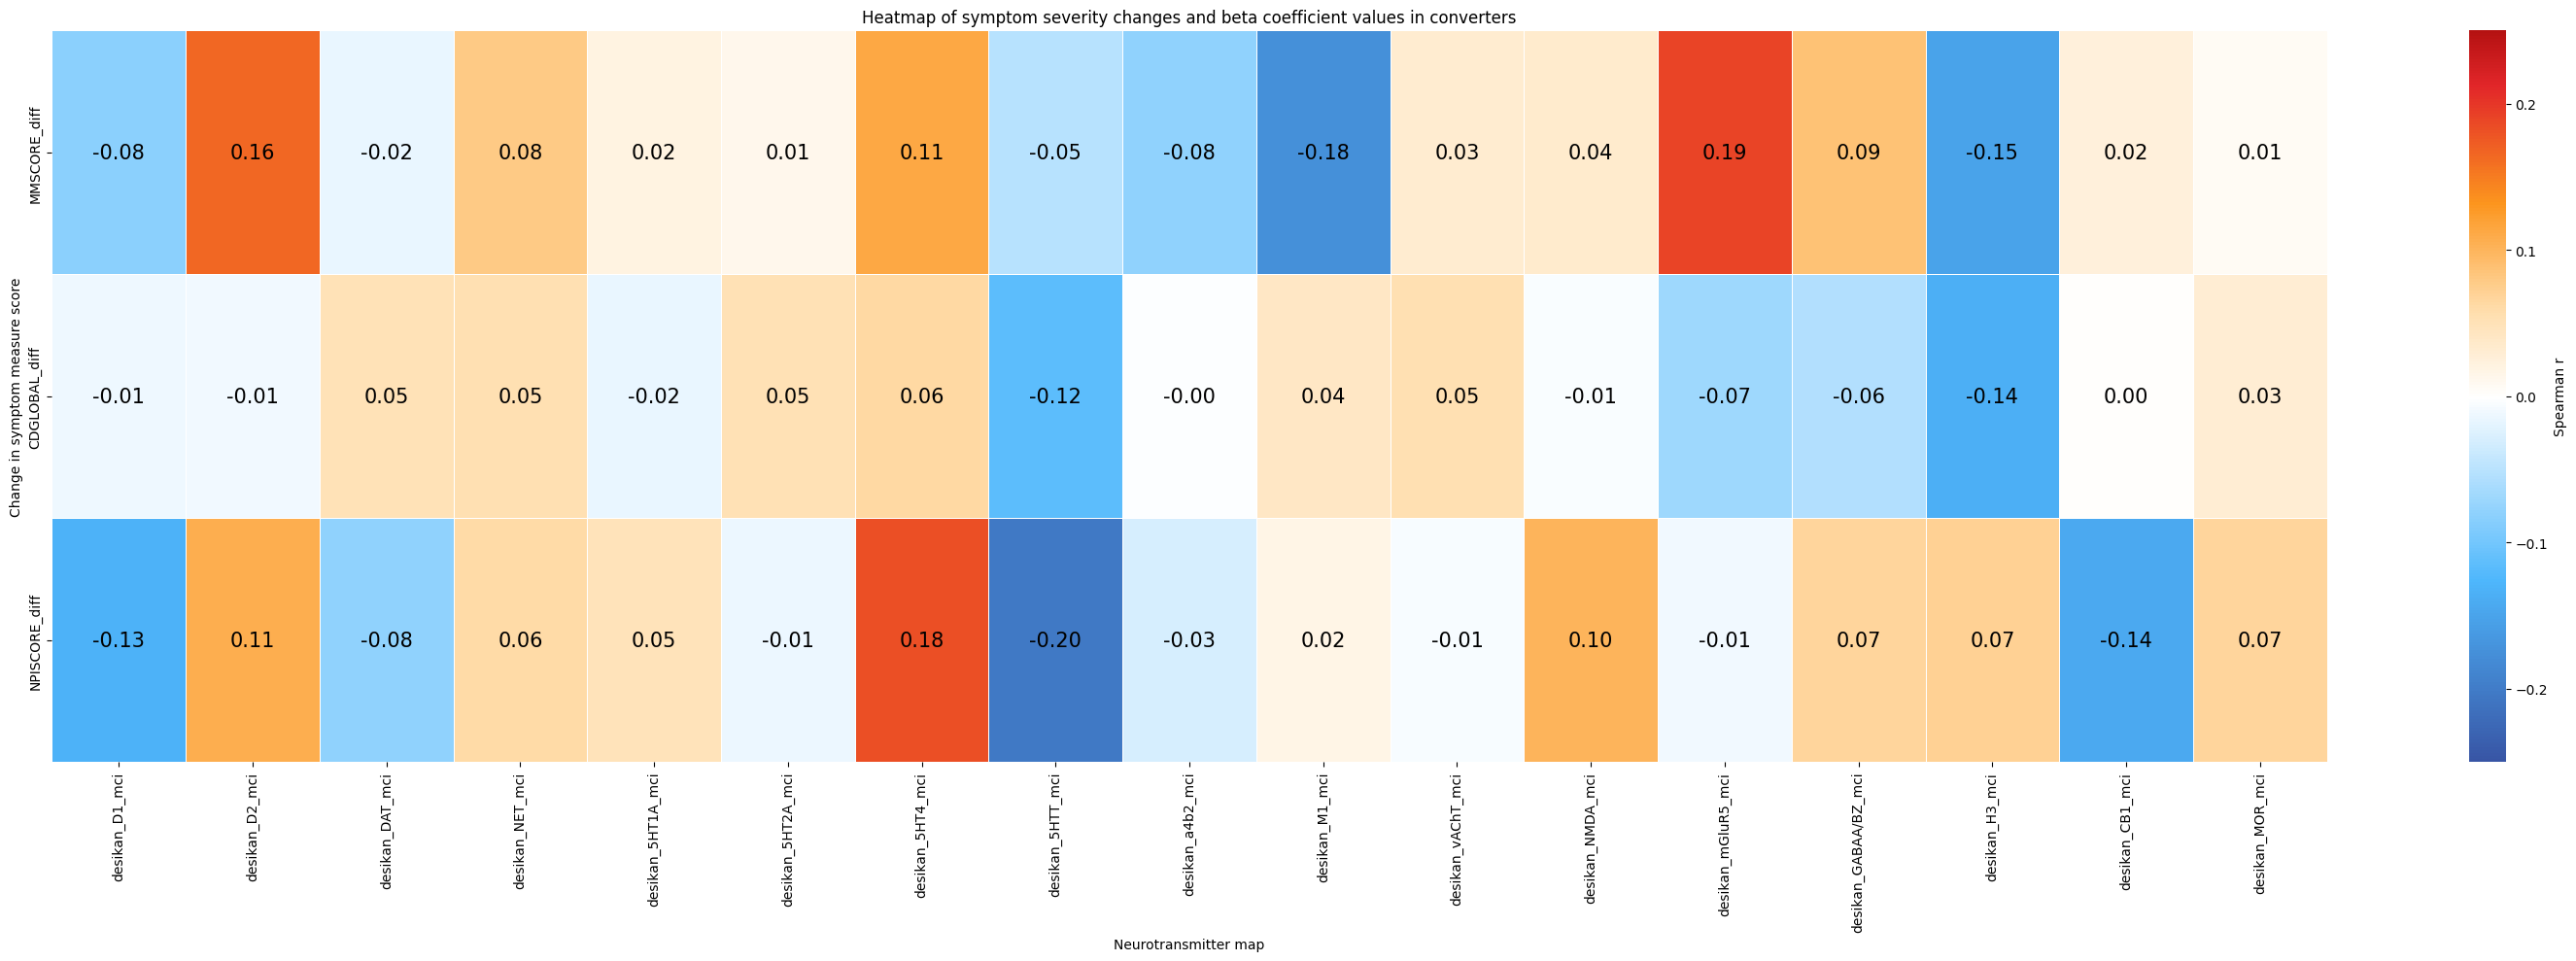

MMSCORE_diff: no significant associations after correction
CDGLOBAL_diff: no significant associations after correction
NPISCORE_diff: no significant associations after correction


In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from statsmodels.stats import multitest
from matplotlib.colors import ListedColormap
from matplotlib import font_manager

font_path = "C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_housekeeping/arial.ttf"
font_manager.fontManager.addfont(font_path)


def get_significance_stars(p_value):
    if p_value <= 0.001: return '***'
    elif p_value <= 0.01: return '**'
    elif p_value <= 0.05: return '*'
    else: return ''

outdir = 'C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_analysis/heatmaps'
os.makedirs(outdir, exist_ok=True)

df = pd.read_csv(
    'C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_housekeeping/cb_df_far.csv',
    low_memory=False
)



coeff_cols = ['desikan_D1_mci', 'desikan_D2_mci', 'desikan_DAT_mci', 'desikan_NET_mci', 
              'desikan_5HT1A_mci', 'desikan_5HT2A_mci', 'desikan_5HT4_mci',
              'desikan_5HTT_mci', 'desikan_a4b2_mci', 'desikan_M1_mci',
              'desikan_vAChT_mci', 'desikan_NMDA_mci', 'desikan_mGluR5_mci',
              'desikan_GABAA/BZ_mci', 'desikan_H3_mci', 'desikan_CB1_mci',
              'desikan_MOR_mci']
symptom_cols = ['MMSCORE_diff', 'CDGLOBAL_diff', 'NPISCORE_diff']

cmap = np.genfromtxt(
    'C:/Users/User/Downloads/deconstructalz.github.io/standards/colourmap.csv',
    delimiter=','
)
cmap_div = ListedColormap(cmap)

df_subset = df[['DIAGNOSIS_oth'] + coeff_cols + symptom_cols]
df_subset = df_subset[df_subset['DIAGNOSIS_oth'] == 1]

r_values = pd.DataFrame(index=coeff_cols, columns=symptom_cols, dtype=float)
p_values = pd.DataFrame(index=coeff_cols, columns=symptom_cols, dtype=float)

for coeff in coeff_cols:
    for symp in symptom_cols:
        tmp = df_subset[[coeff, symp]].copy()
        tmp = tmp[tmp[symp] >= 0].dropna()
        
        if len(tmp) > 1:
            r, p = spearmanr(tmp[coeff], tmp[symp])
        else:
            r, p = np.nan, np.nan

        r_values.loc[coeff, symp] = r
        p_values.loc[coeff, symp] = p

r_values = r_values.transpose()
p_values = p_values.transpose()

p_flat = p_values.values.flatten()
mask = ~np.isnan(p_flat)

p_corr = np.full_like(p_flat, np.nan)
p_corr[mask] = multitest.multipletests(p_flat[mask], method='bonf')[1]

p_values = pd.DataFrame(
    p_corr.reshape(p_values.shape),
    index=p_values.index,
    columns=p_values.columns
)

plt.figure(figsize=(30, 10))

ax = sns.heatmap(
    r_values,
    annot=True,
    fmt=".2f",
    cmap=cmap_div,
    center=0,
    vmin=-0.25,
    vmax=0.25,
    cbar_kws={'label': "Spearman r"},
    annot_kws={'color': 'black', 'fontsize': 15, 'va': 'center'},
    linewidths=0.5,
    linecolor='white'
)

n_rows, n_cols = r_values.shape

for y in range(n_rows):
    for x in range(n_cols):
        r = r_values.iloc[y, x]
        p = p_values.iloc[y, x]

        if not np.isnan(r) and not np.isnan(p):
            stars = get_significance_stars(p)

            if stars:
                ax.text(
                    x + 0.5,     # center of cell (x)
                    y + 0.4,    # slightly above rho
                    stars,
                    ha='center',
                    va='center',
                    fontsize=15,
                    color='black'
                )

plt.xlabel('Neurotransmitter map')
plt.ylabel('Change in symptom measure score')
plt.title('Heatmap of symptom severity changes and beta coefficient values in converters')
plt.tight_layout()

plt.savefig(f"{outdir}/conv_feature_select_cb_far_spearman_heatmap.png", dpi=300)

plt.show()

alpha = 0.05  # significance threshold (after FDR)

for symp in r_values.index:
    r_row = r_values.loc[symp]
    p_row = p_values.loc[symp]

    summary_df = pd.DataFrame({
        'rho': r_row,
        'abs_rho': r_row.abs(),
        'pval': p_row
    })

    # keep only significant results
    summary_df = summary_df[summary_df['pval'] <= alpha]

    if summary_df.empty:
        print(f"{symp}: no significant associations after correction")
        continue

    # sort by absolute rho
    summary_df = summary_df.sort_values(by='abs_rho', ascending=False)

    top = summary_df.iloc[0]
    
    print(symp)
    print(f"Top feature: {top.name}")
    print(f"Spearman r: {top['rho']:.3f}")
    print(f"p-value (Bonferroni): {top['pval']:.3e}")

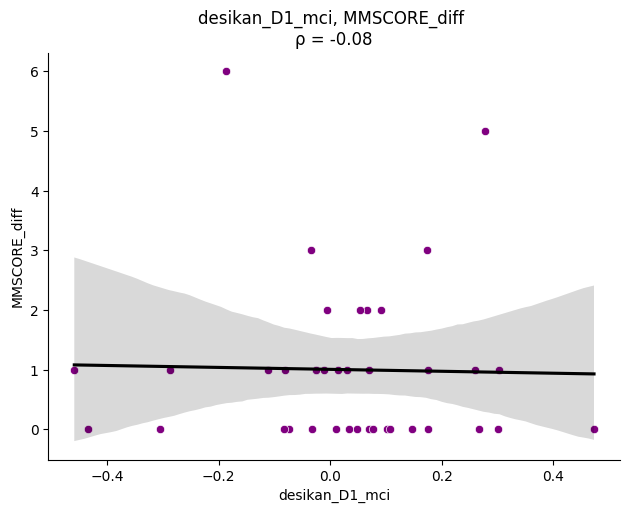

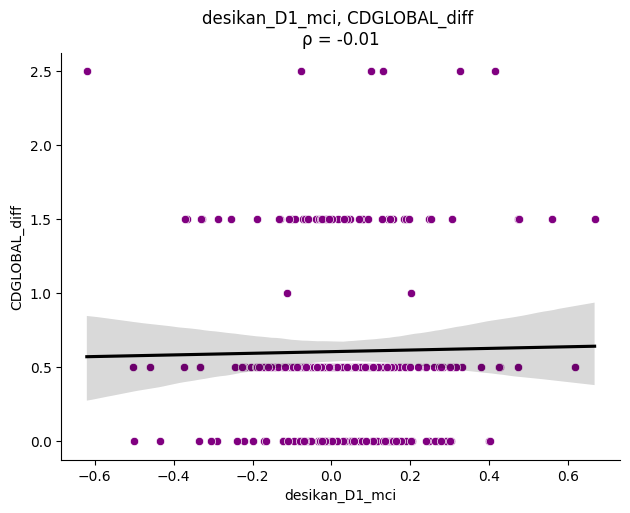

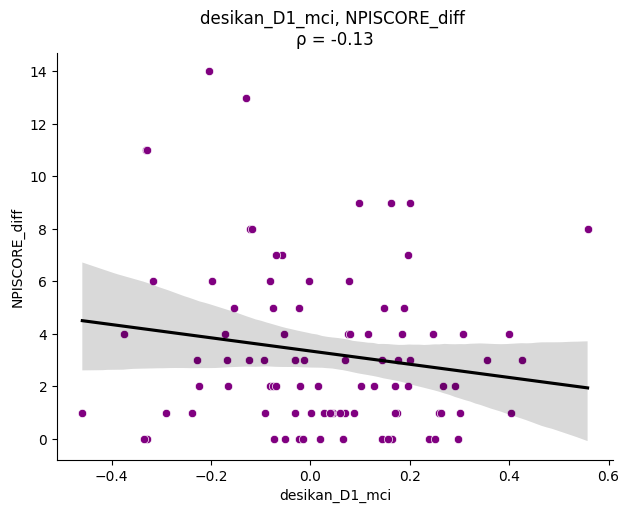

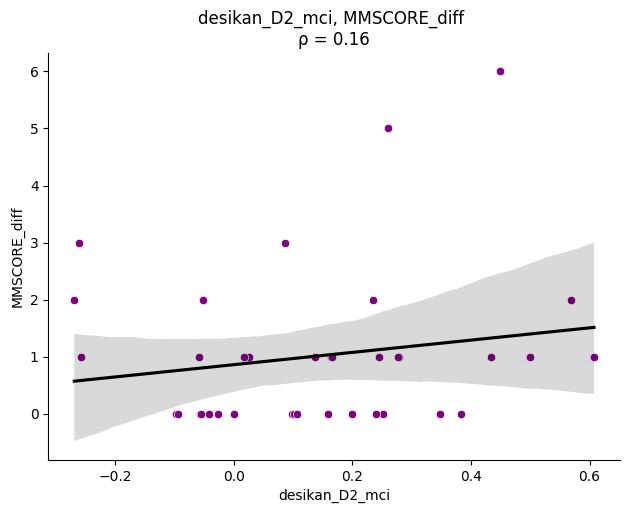

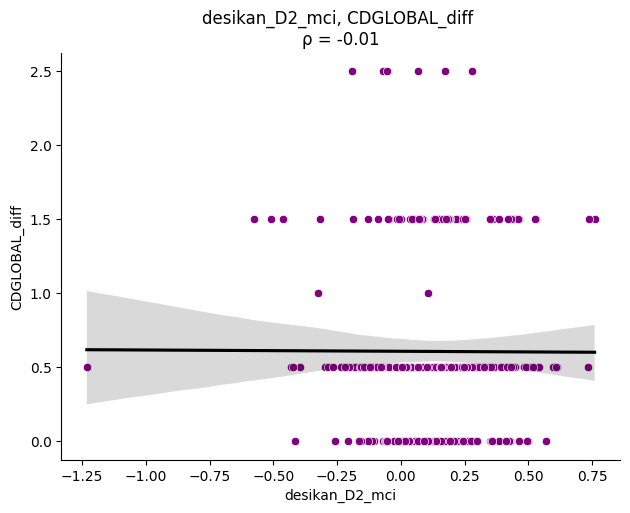

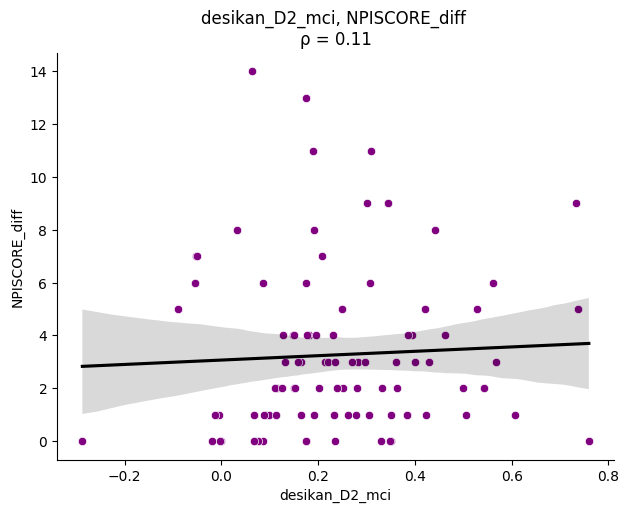

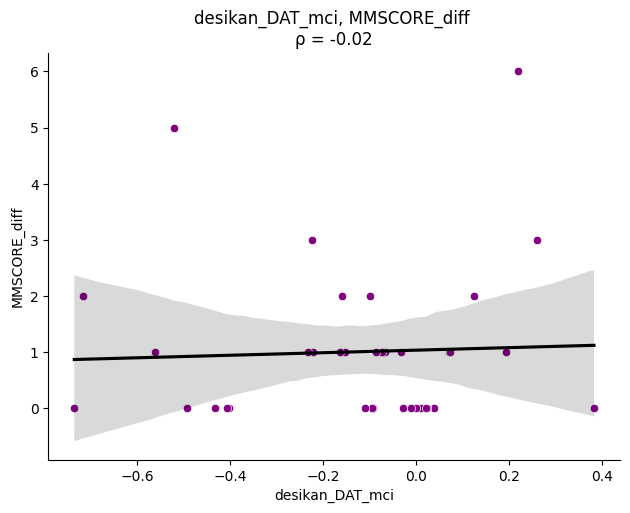

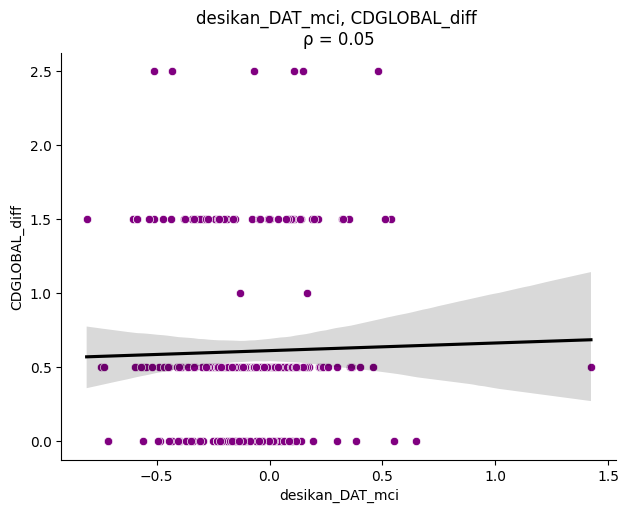

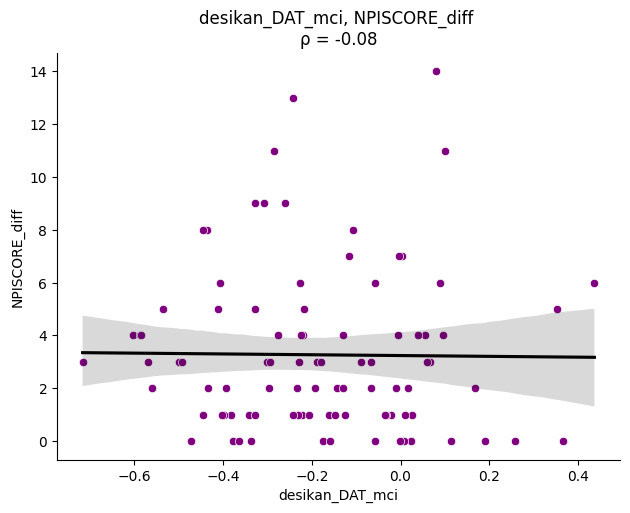

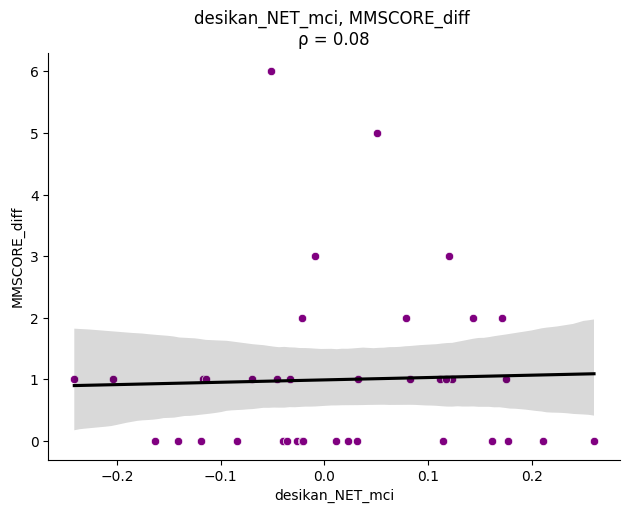

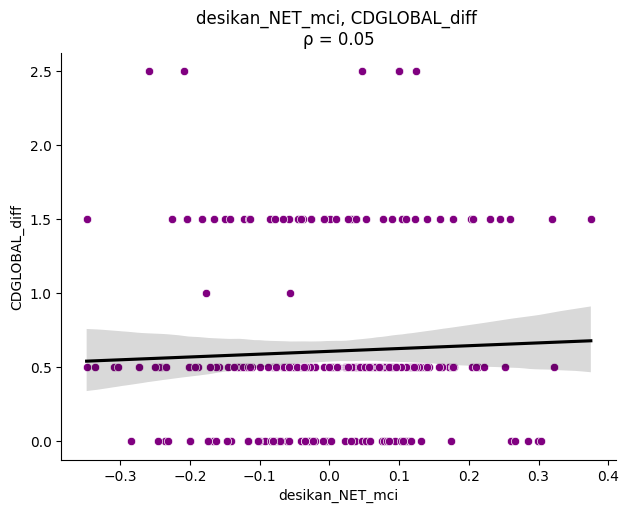

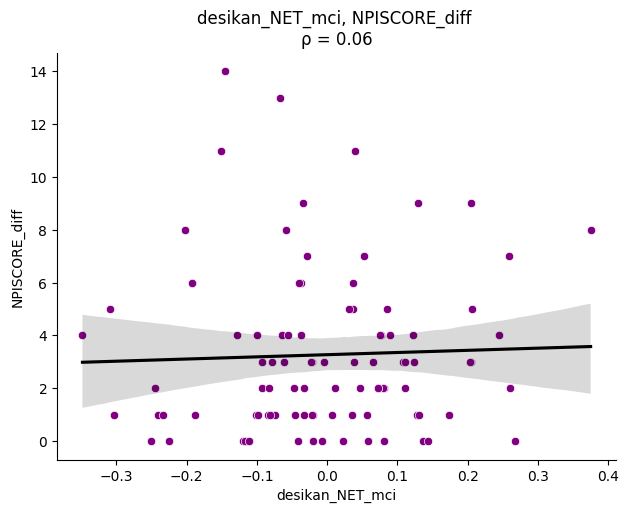

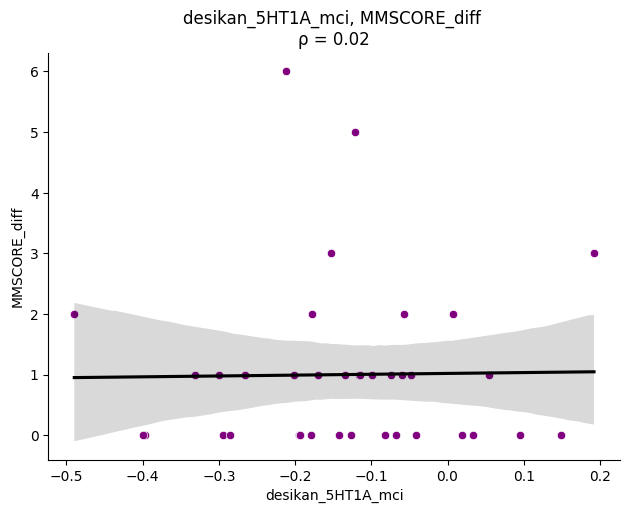

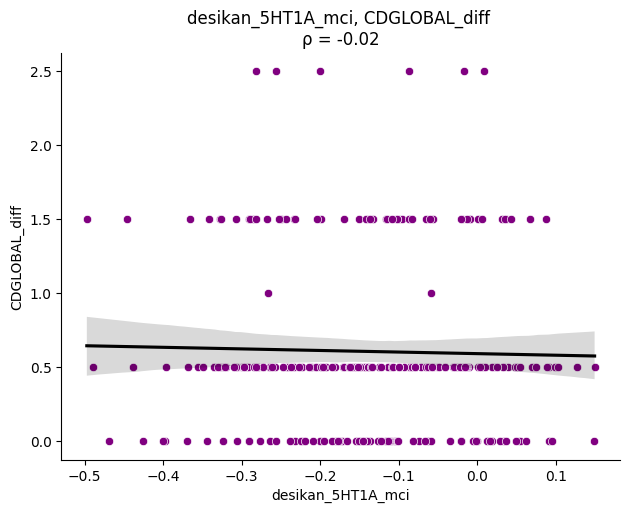

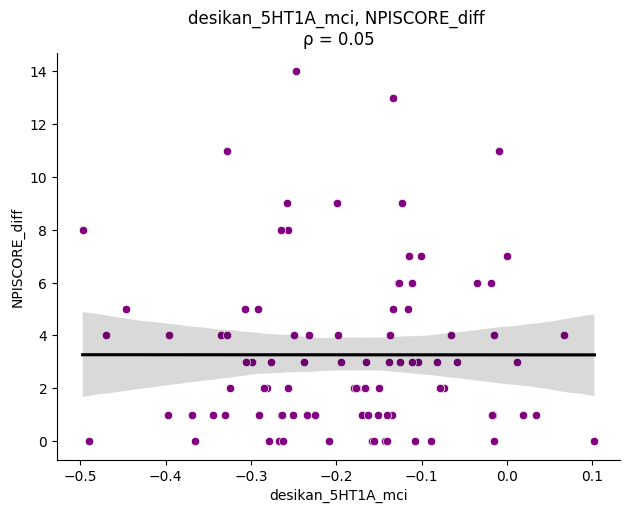

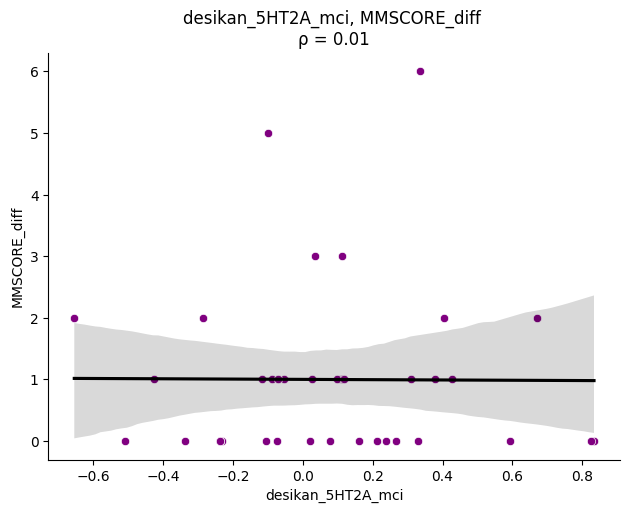

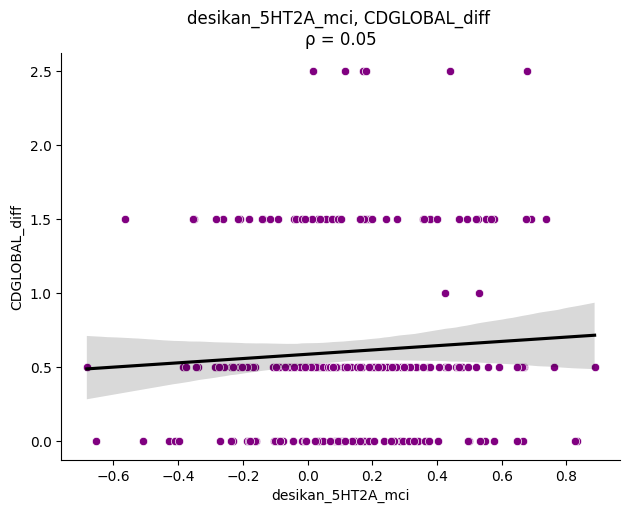

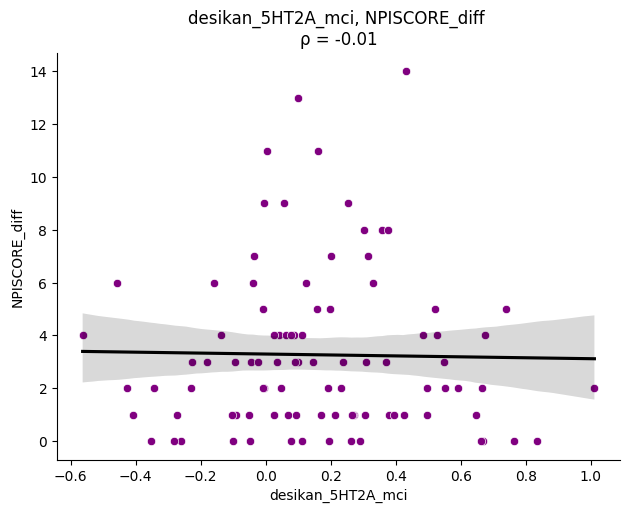

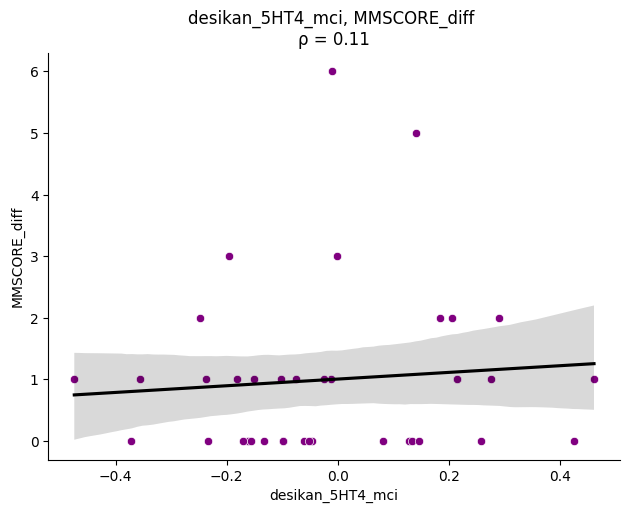

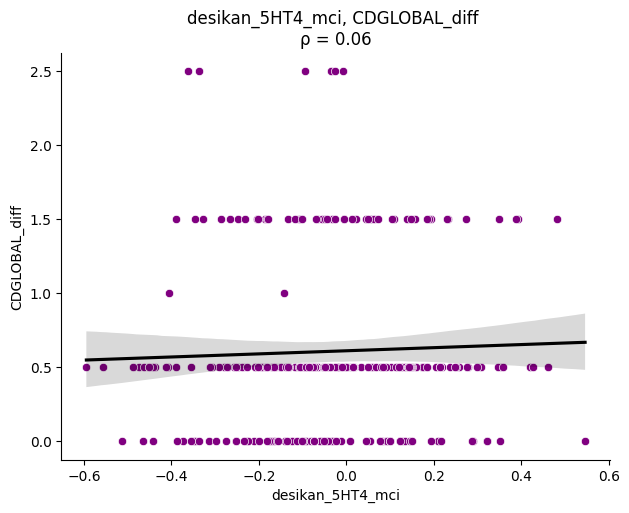

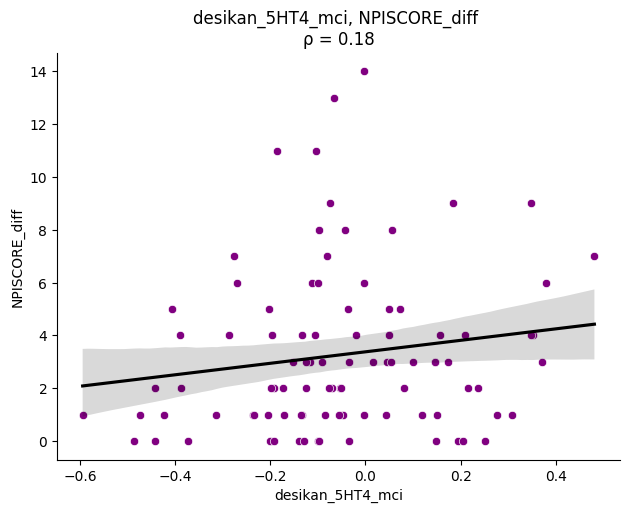

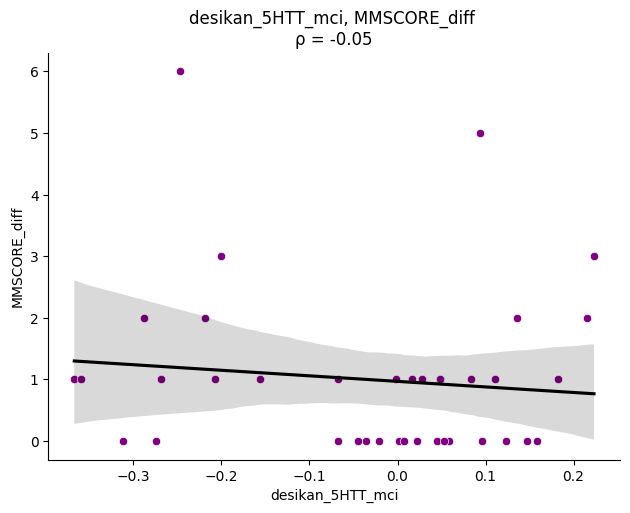

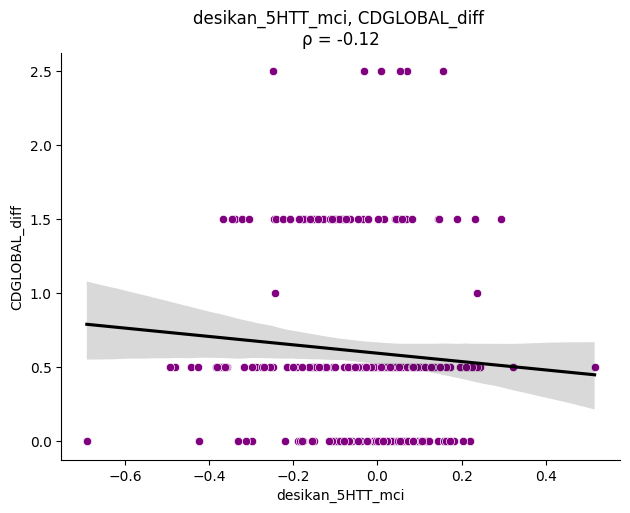

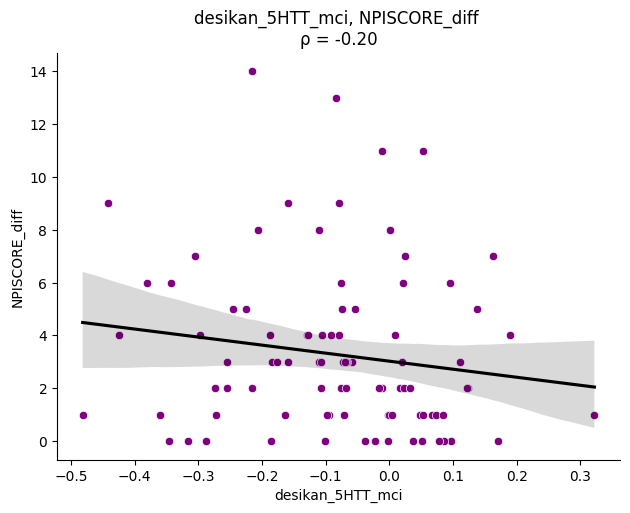

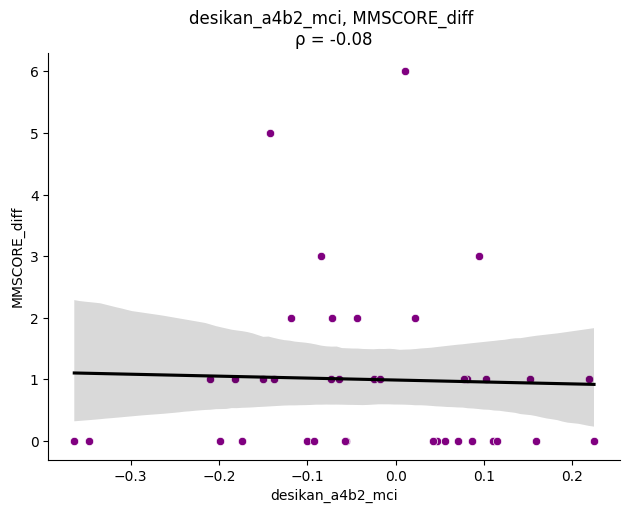

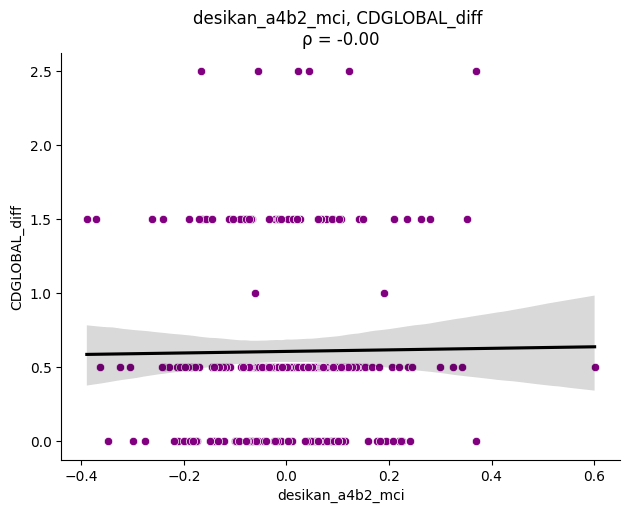

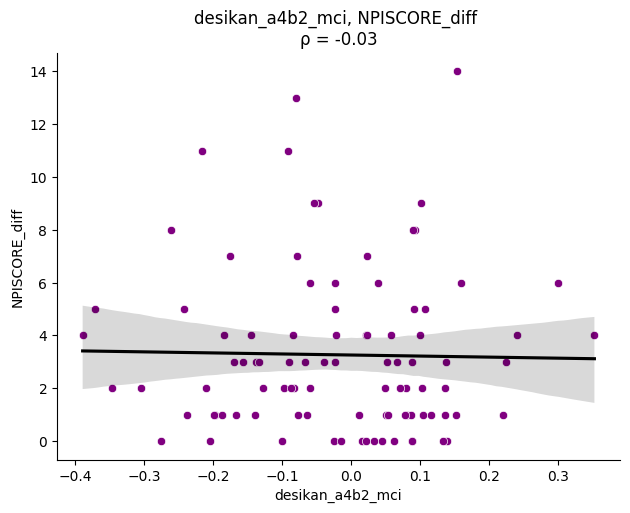

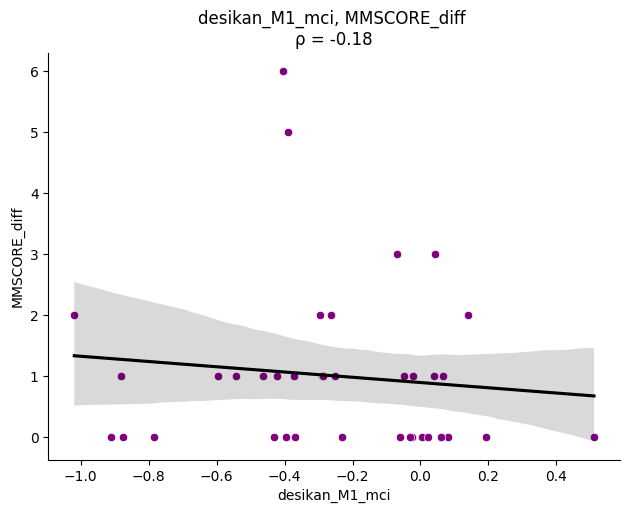

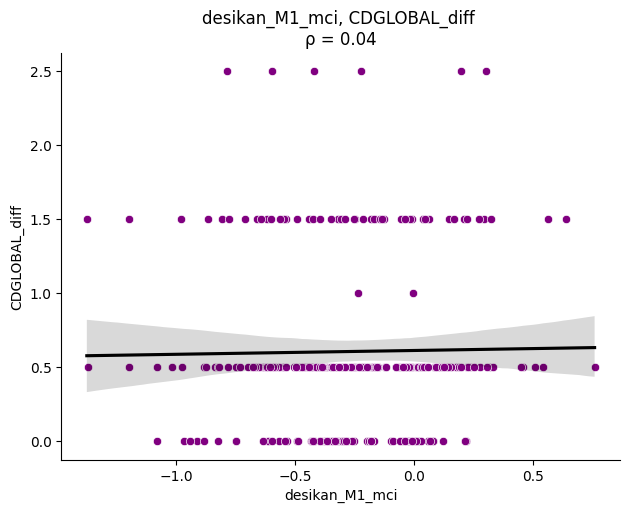

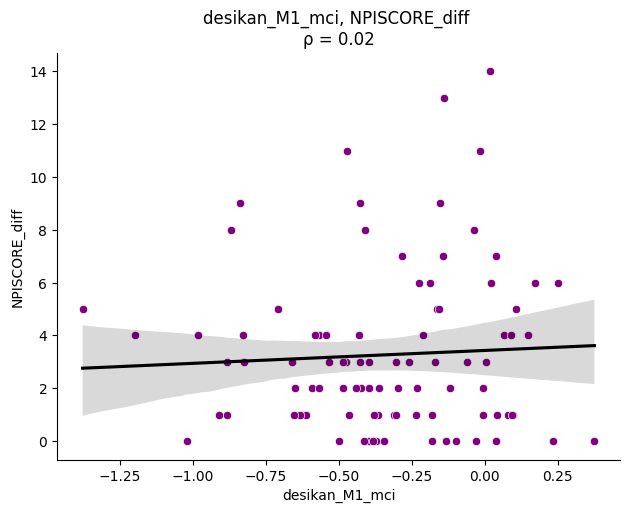

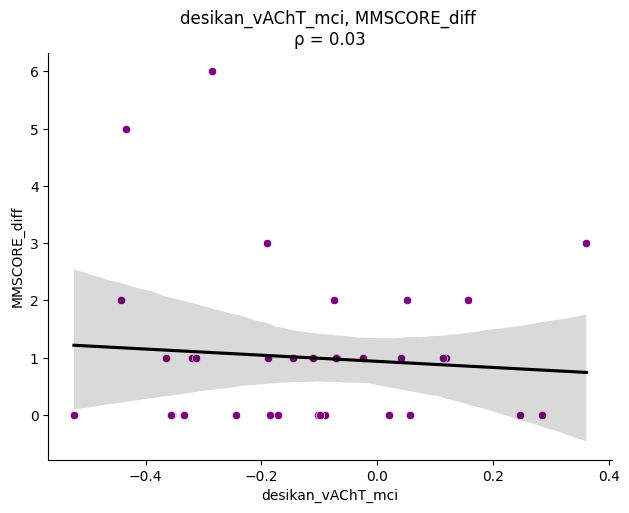

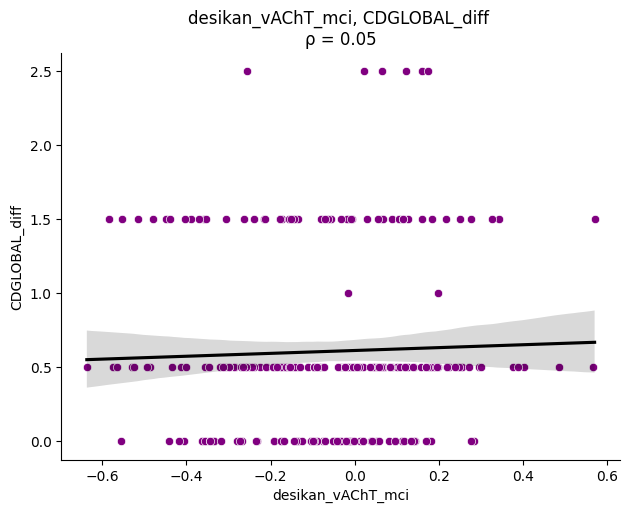

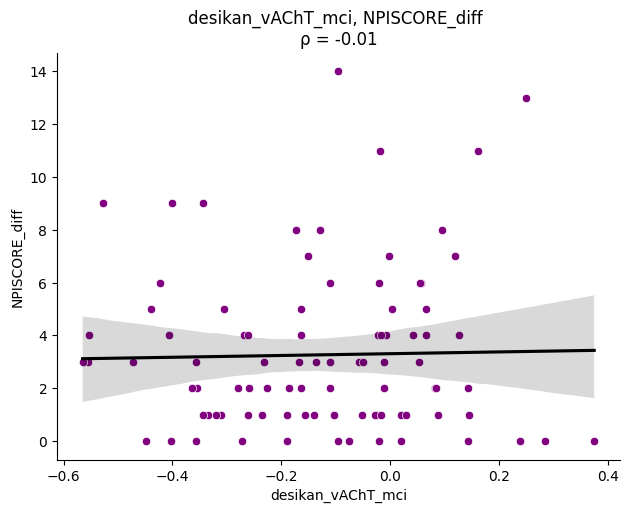

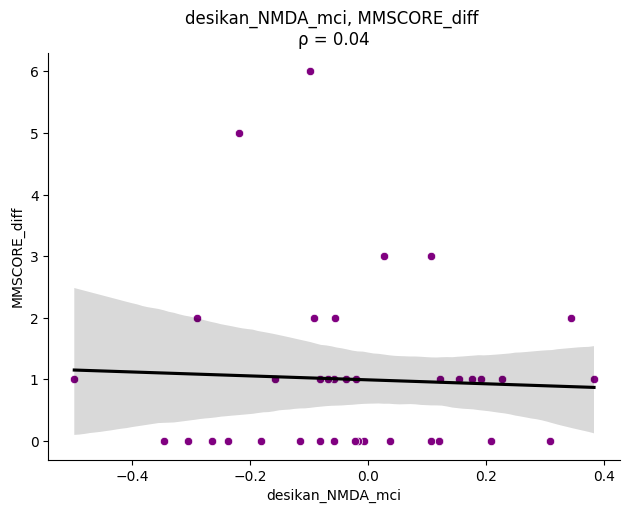

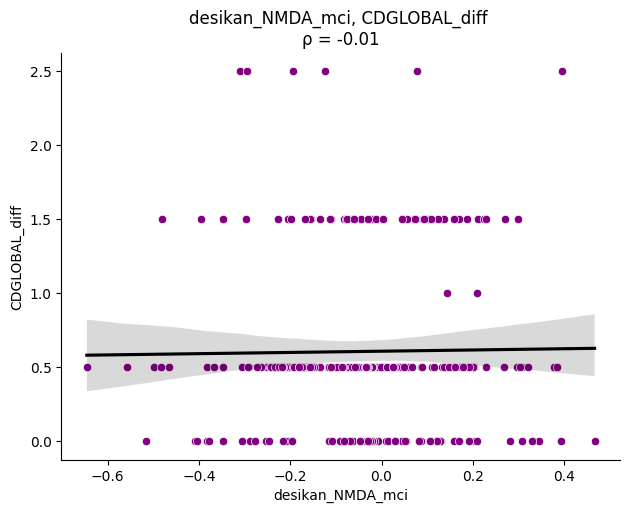

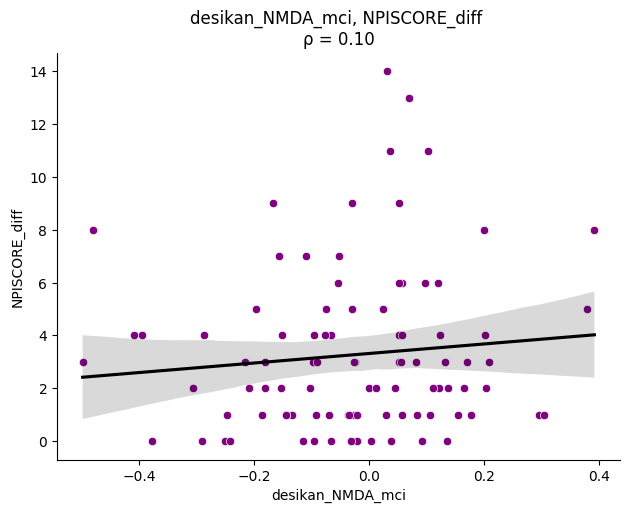

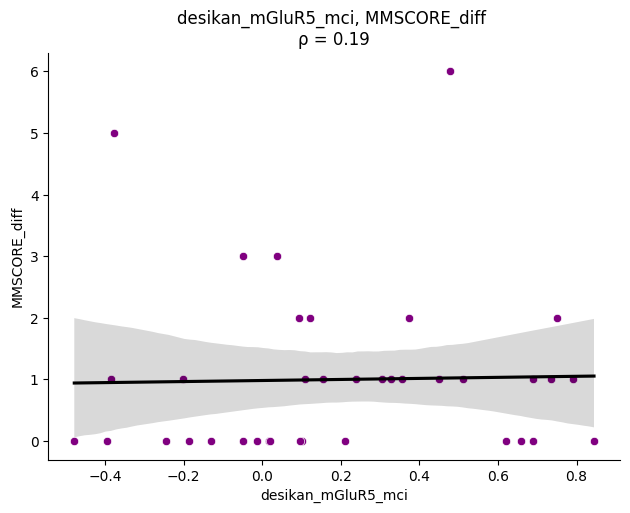

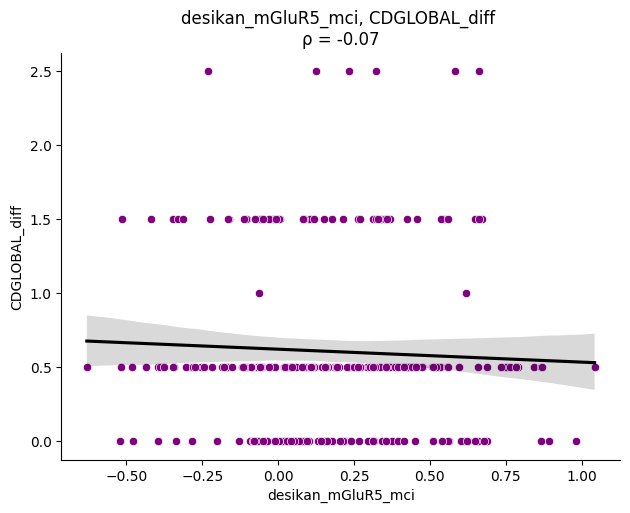

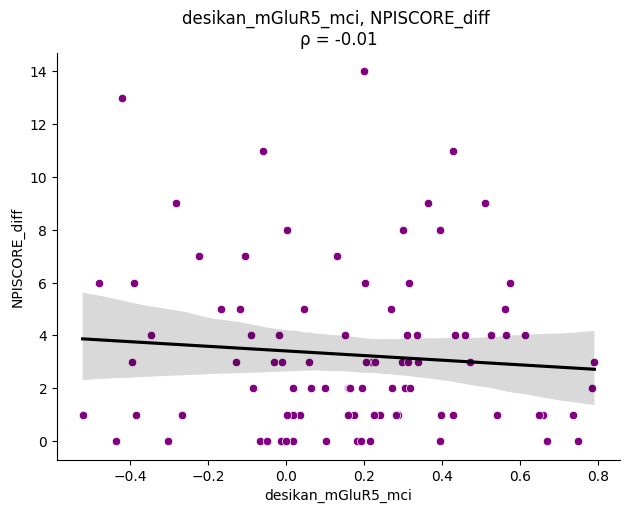

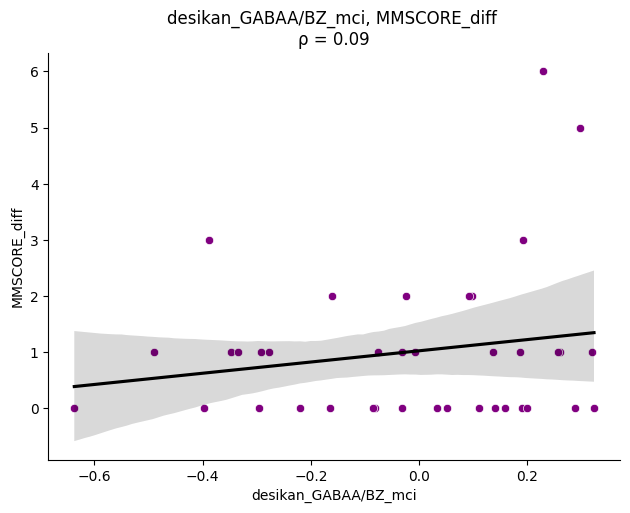

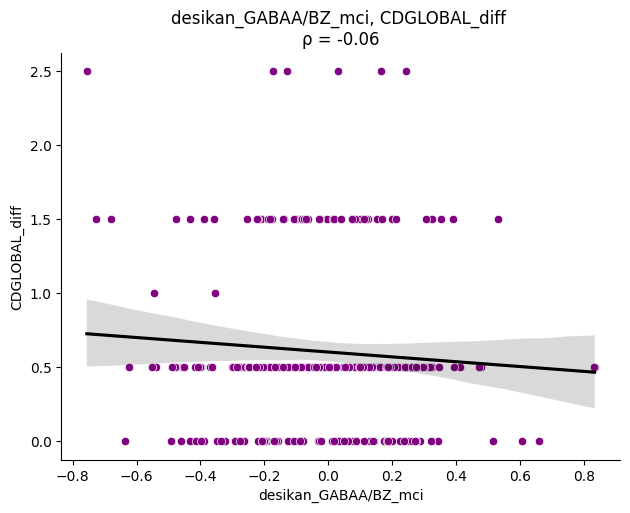

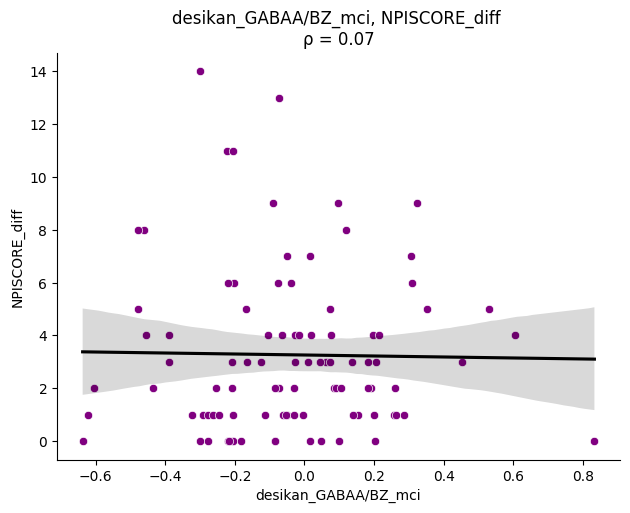

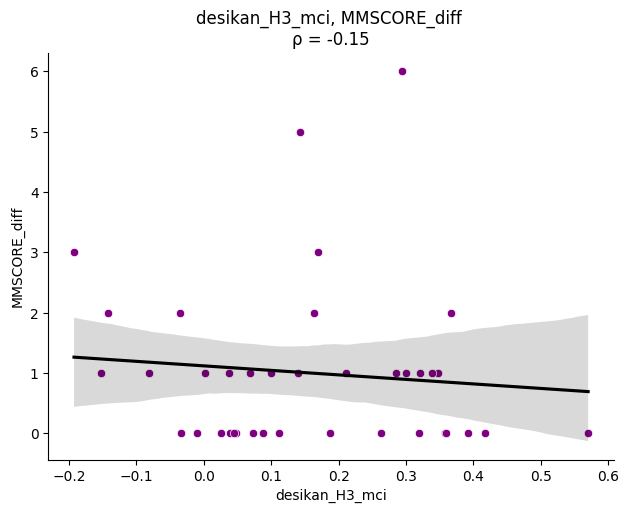

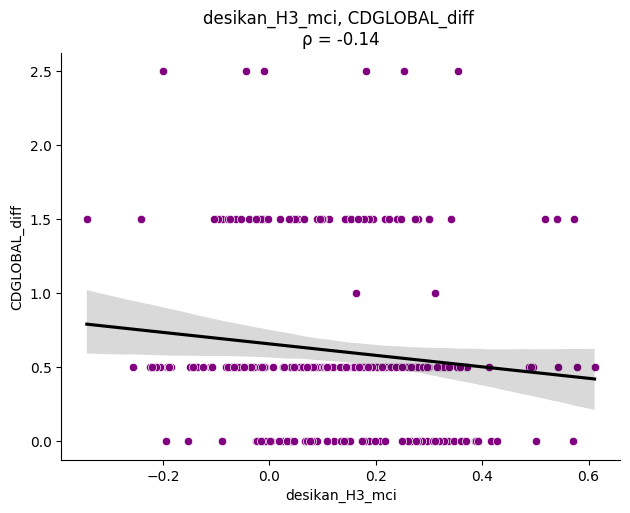

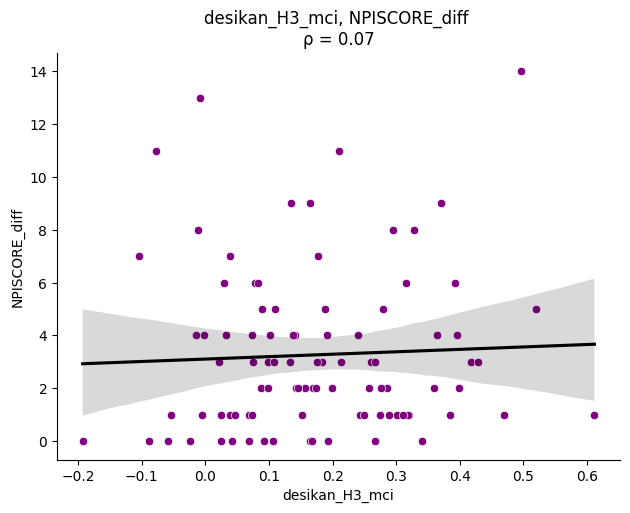

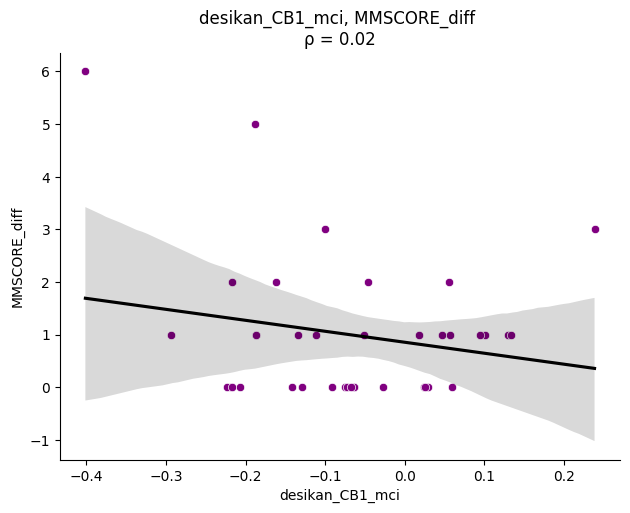

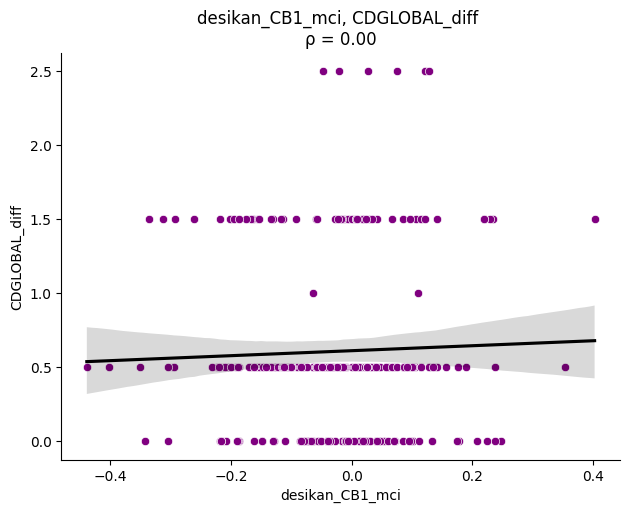

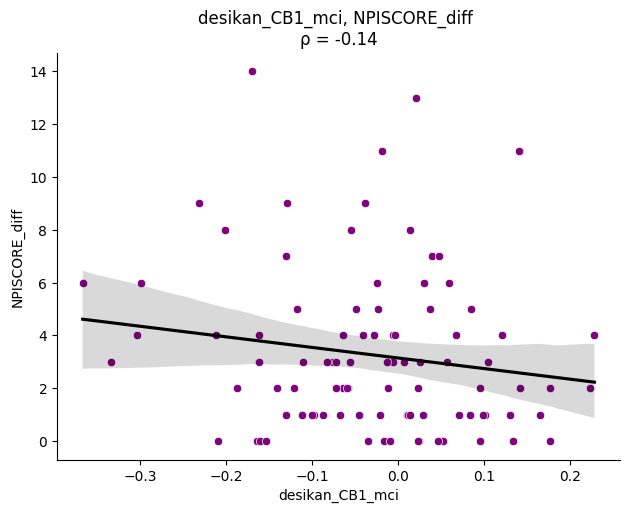

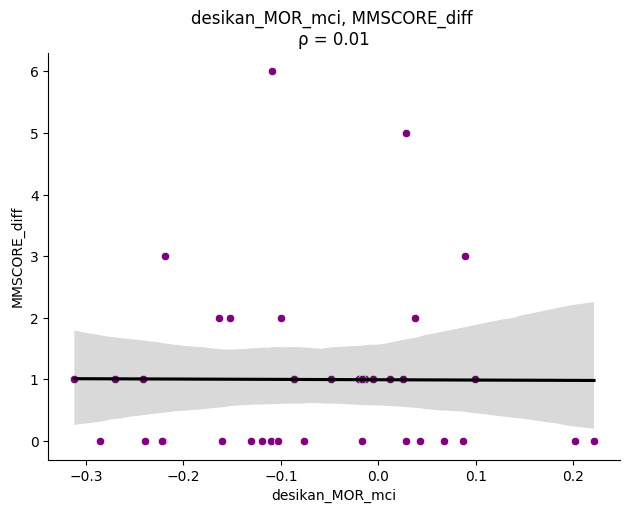

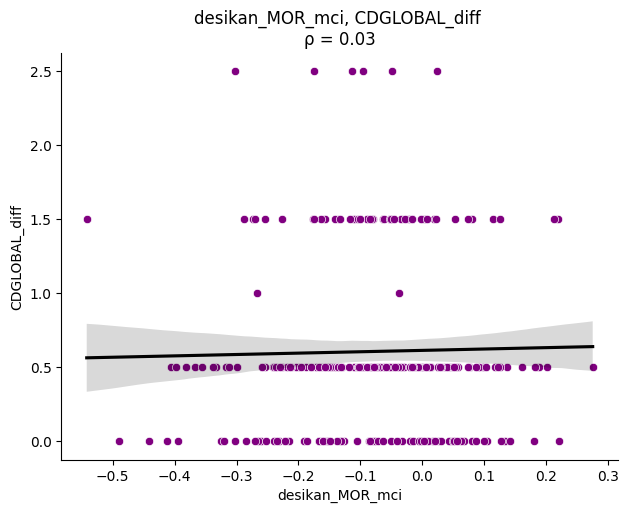

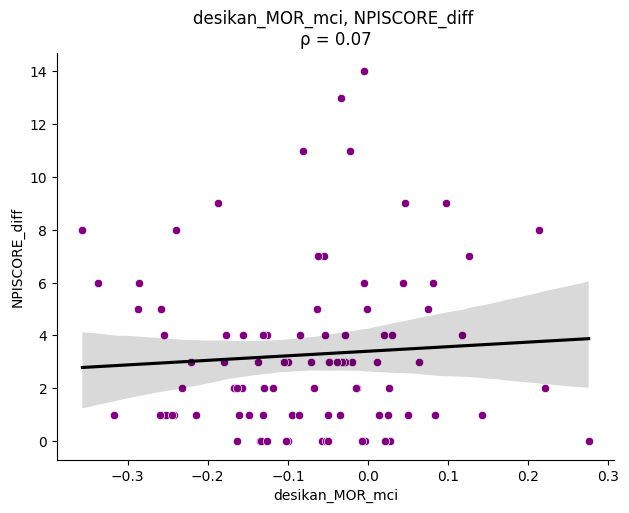

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr
from statsmodels.stats import multitest
from matplotlib import font_manager

font_path = "C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_housekeeping/arial.ttf"
font_manager.fontManager.addfont(font_path)

def get_significance_stars(p_value):
    if p_value <= 0.001: return '***'
    elif p_value <= 0.01: return '**'
    elif p_value <= 0.05: return '*'
    else: return ''

outdir = '/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/ad_symptoms'
os.makedirs(outdir, exist_ok=True)

df = pd.read_csv(
    'C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_housekeeping/cb_df_far.csv',
    low_memory=False
)
coeff_cols = ['desikan_D1_mci', 'desikan_D2_mci', 'desikan_DAT_mci', 'desikan_NET_mci', 
              'desikan_5HT1A_mci', 'desikan_5HT2A_mci', 'desikan_5HT4_mci',
              'desikan_5HTT_mci', 'desikan_a4b2_mci', 'desikan_M1_mci',
              'desikan_vAChT_mci', 'desikan_NMDA_mci', 'desikan_mGluR5_mci',
              'desikan_GABAA/BZ_mci', 'desikan_H3_mci', 'desikan_CB1_mci',
              'desikan_MOR_mci']
symptom_cols = ['MMSCORE_diff', 'CDGLOBAL_diff', 'NPISCORE_diff']

df_subset = df[['DIAGNOSIS_oth'] + coeff_cols + symptom_cols]
df_subset = df_subset[df_subset['DIAGNOSIS_oth'] == 1]


for coeff in coeff_cols:
    for symp in symptom_cols:
        tmp = df_subset[[coeff, symp]].copy()
        tmp = tmp[tmp[symp] >= 0].dropna()
        r, p = spearmanr(tmp[coeff], tmp[symp])
        sns.scatterplot(data = tmp, x = coeff, y = symp, color = 'purple')
        sns.regplot(data = tmp, x = coeff, y = symp, ci = 95, line_kws = dict(color = 'k'), scatter = False)
        sns.despine()
        plt.tight_layout()
        plt.title(f'{coeff}, {symp} \nρ = {r:.2f}')
        coeff_safe = coeff.replace('/','_')
        plt.show()
        plt.close()

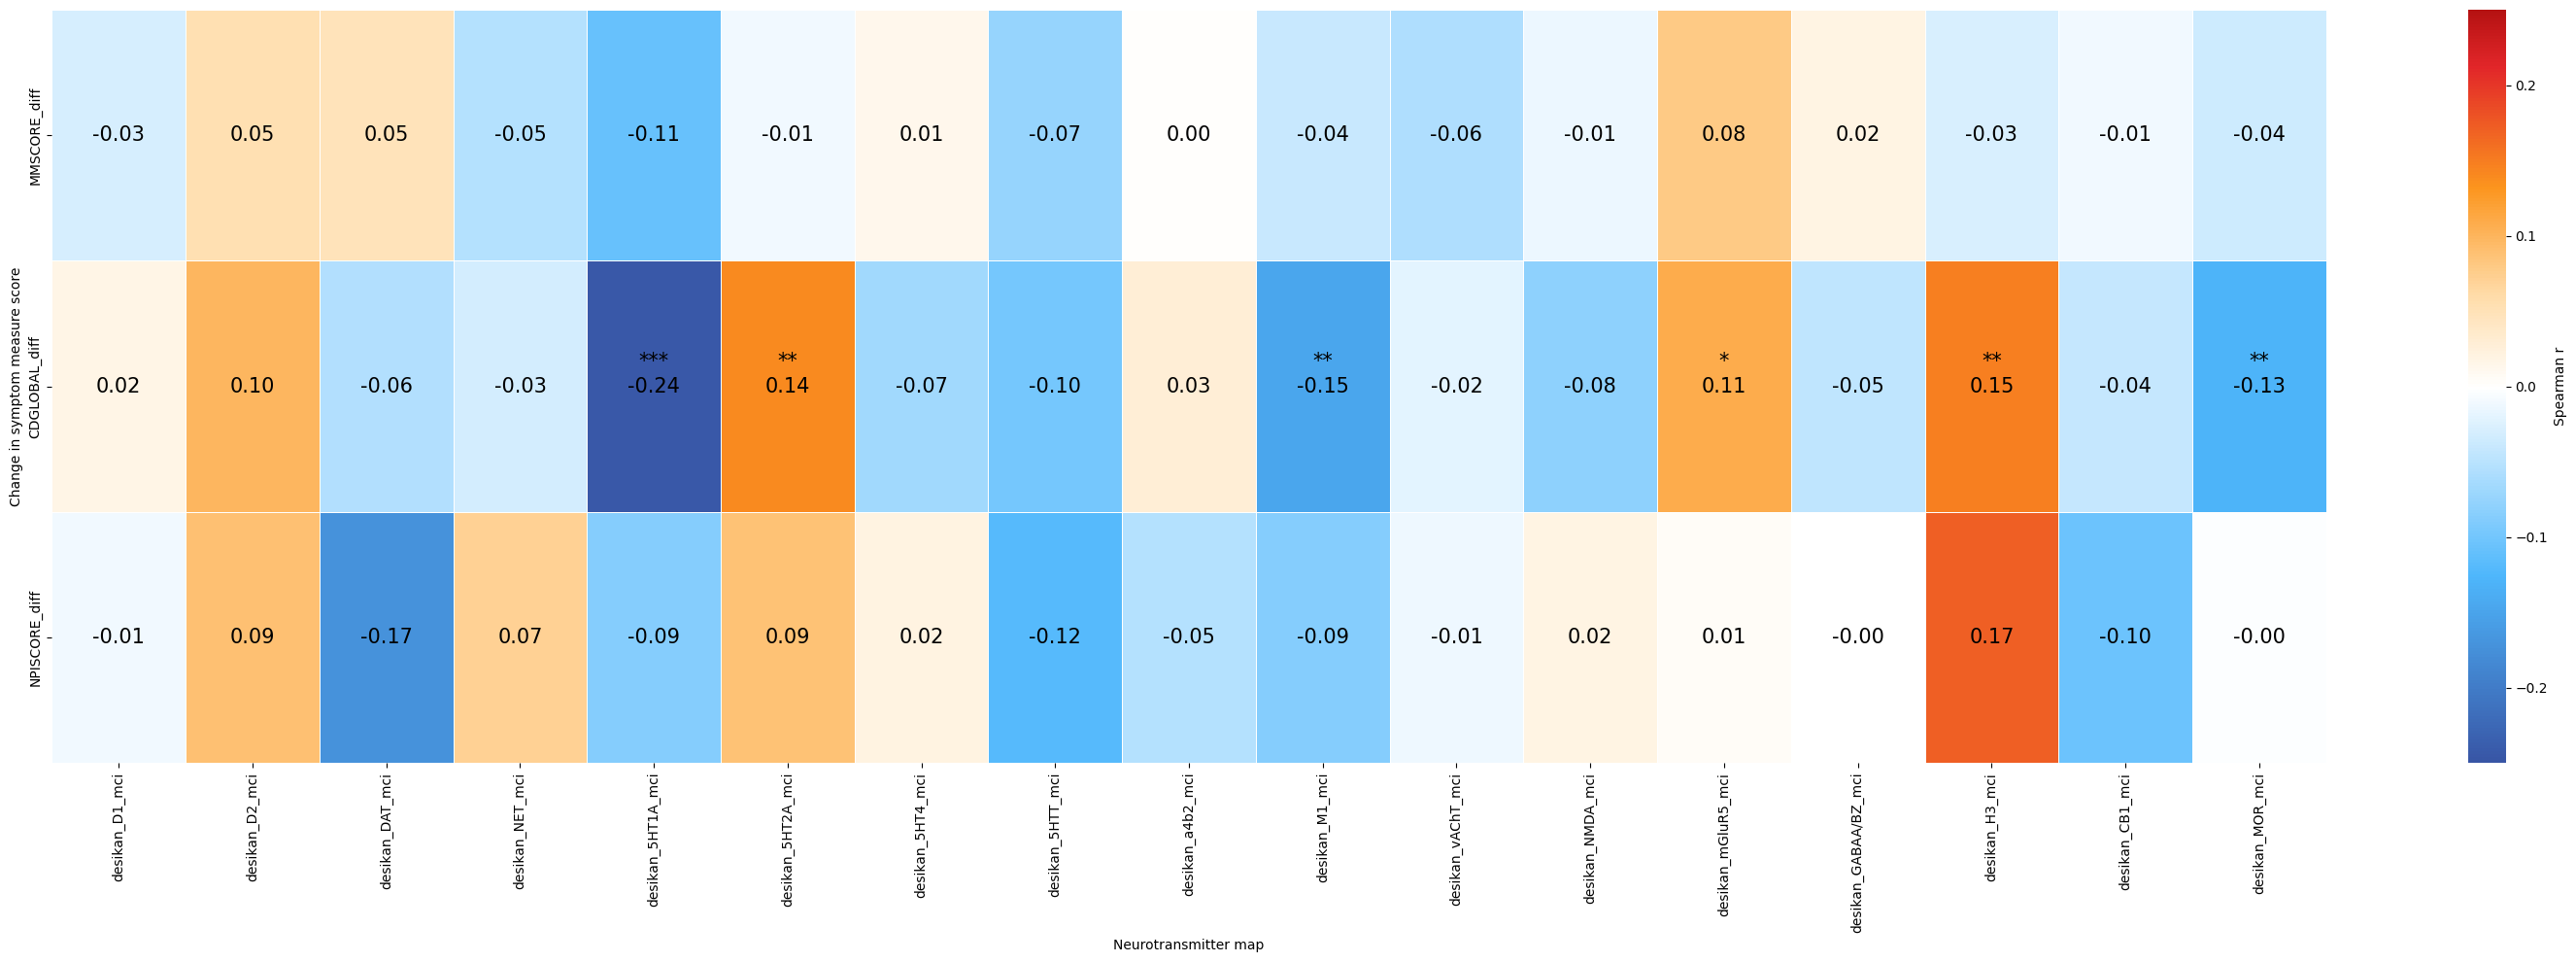

MMSCORE_diff: no significant associations after correction
CDGLOBAL_diff
Top feature: desikan_5HT1A_mci
Spearman r: -0.244
p-value (FDR): 1.934e-09
NPISCORE_diff: no significant associations after correction


In [36]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from statsmodels.stats import multitest
from matplotlib.colors import ListedColormap
from matplotlib import font_manager

font_path = "/rds/general/user/sk4724/home/arial.ttf"
font_manager.fontManager.addfont(font_path)


def get_significance_stars(p_value):
    if p_value <= 0.001: return '***'
    elif p_value <= 0.01: return '**'
    elif p_value <= 0.05: return '*'
    else: return ''

outdir = '/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/heatmaps'
os.makedirs(outdir, exist_ok=True)

df = pd.read_csv(
    '/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/cb_df_far.csv',
    low_memory=False
)



coeff_cols = ['desikan_D1_mci', 'desikan_D2_mci', 'desikan_DAT_mci', 'desikan_NET_mci', 
              'desikan_5HT1A_mci', 'desikan_5HT2A_mci', 'desikan_5HT4_mci',
              'desikan_5HTT_mci', 'desikan_a4b2_mci', 'desikan_M1_mci',
              'desikan_vAChT_mci', 'desikan_NMDA_mci', 'desikan_mGluR5_mci',
              'desikan_GABAA/BZ_mci', 'desikan_H3_mci', 'desikan_CB1_mci',
              'desikan_MOR_mci']
symptom_cols = ['MMSCORE_diff', 'CDGLOBAL_diff', 'NPISCORE_diff']

cmap = np.genfromtxt(
    '/rds/general/project/c3nl_scott_students/live/sankeith/standards/colourmap.csv',
    delimiter=','
)
cmap_div = ListedColormap(cmap)

df_subset = df[coeff_cols + symptom_cols]

r_values = pd.DataFrame(index=coeff_cols, columns=symptom_cols, dtype=float)
p_values = pd.DataFrame(index=coeff_cols, columns=symptom_cols, dtype=float)

for coeff in coeff_cols:
    for symp in symptom_cols:
        tmp = df_subset[[coeff, symp]].copy()
        tmp = tmp[tmp[symp] >= 0].dropna()
        
        if len(tmp) > 1:
            r, p = spearmanr(tmp[coeff], tmp[symp])
        else:
            r, p = np.nan, np.nan

        r_values.loc[coeff, symp] = r
        p_values.loc[coeff, symp] = p

r_values = r_values.transpose()
p_values = p_values.transpose()

p_flat = p_values.values.flatten()
mask = ~np.isnan(p_flat)

p_corr = np.full_like(p_flat, np.nan)
p_corr[mask] = multitest.multipletests(p_flat[mask], method='fdr_bh')[1]

p_values = pd.DataFrame(
    p_corr.reshape(p_values.shape),
    index=p_values.index,
    columns=p_values.columns
)

plt.figure(figsize=(30, 10))

ax = sns.heatmap(
    r_values,
    annot=True,
    fmt=".2f",
    cmap=cmap_div,
    center=0,
    vmin=-0.25,
    vmax=0.25,
    cbar_kws={'label': "Spearman r"},
    annot_kws={'color': 'black', 'fontsize': 15, 'va': 'center'},
    linewidths=0.5,
    linecolor='white'
)

n_rows, n_cols = r_values.shape

for y in range(n_rows):
    for x in range(n_cols):
        r = r_values.iloc[y, x]
        p = p_values.iloc[y, x]

        if not np.isnan(r) and not np.isnan(p):
            stars = get_significance_stars(p)

            if stars:
                ax.text(
                    x + 0.5,     # center of cell (x)
                    y + 0.4,    # slightly above rho
                    stars,
                    ha='center',
                    va='center',
                    fontsize=15,
                    color='black'
                )

plt.xlabel('Neurotransmitter map')
plt.ylabel('Change in symptom measure score')
plt.tight_layout()

plt.savefig(f"{outdir}/feature_select_cb_far_spearman_heatmap.png", dpi=300)

plt.show()

alpha = 0.05  # significance threshold (after FDR)

for symp in r_values.index:
    r_row = r_values.loc[symp]
    p_row = p_values.loc[symp]

    summary_df = pd.DataFrame({
        'rho': r_row,
        'abs_rho': r_row.abs(),
        'pval': p_row
    })

    # keep only significant results
    summary_df = summary_df[summary_df['pval'] <= alpha]

    if summary_df.empty:
        print(f"{symp}: no significant associations after correction")
        continue

    # sort by absolute rho
    summary_df = summary_df.sort_values(by='abs_rho', ascending=False)

    top = summary_df.iloc[0]
    
    print(symp)
    print(f"Top feature: {top.name}")
    print(f"Spearman r: {top['rho']:.3f}")
    print(f"p-value (FDR): {top['pval']:.3e}")

#### Swarmplot = MCI vs AD

False
['desikan_D1', 'desikan_D2', 'desikan_DAT', 'desikan_NET', 'desikan_5HT1A', 'desikan_5HT1B', 'desikan_5HT2A', 'desikan_5HT4', 'desikan_5HT6', 'desikan_5HTT', 'desikan_a4b2', 'desikan_M1', 'desikan_vAChT', 'desikan_NMDA', 'desikan_mGluR5', 'desikan_GABAA/BZ', 'desikan_H3', 'desikan_CB1', 'desikan_MOR']
         Coefficient         Raw_P                  Test   Corrected_P  \
0         desikan_D1  1.860282e-07  Wilcoxon signed-rank  2.945447e-07   
1         desikan_D2  5.743015e-29  Wilcoxon signed-rank  2.182346e-28   
2        desikan_DAT  2.893191e-31  Wilcoxon signed-rank  1.374266e-30   
3        desikan_NET  4.311008e-01  Wilcoxon signed-rank  4.550508e-01   
4      desikan_5HT1A  5.950147e-38  Wilcoxon signed-rank  1.130528e-36   
5      desikan_5HT1B  2.216084e-05  Wilcoxon signed-rank  3.238891e-05   
6      desikan_5HT2A  4.735653e-01  Wilcoxon signed-rank  4.735653e-01   
7       desikan_5HT4  1.582579e-03  Wilcoxon signed-rank  2.004600e-03   
8       desikan_5HT6  4.5

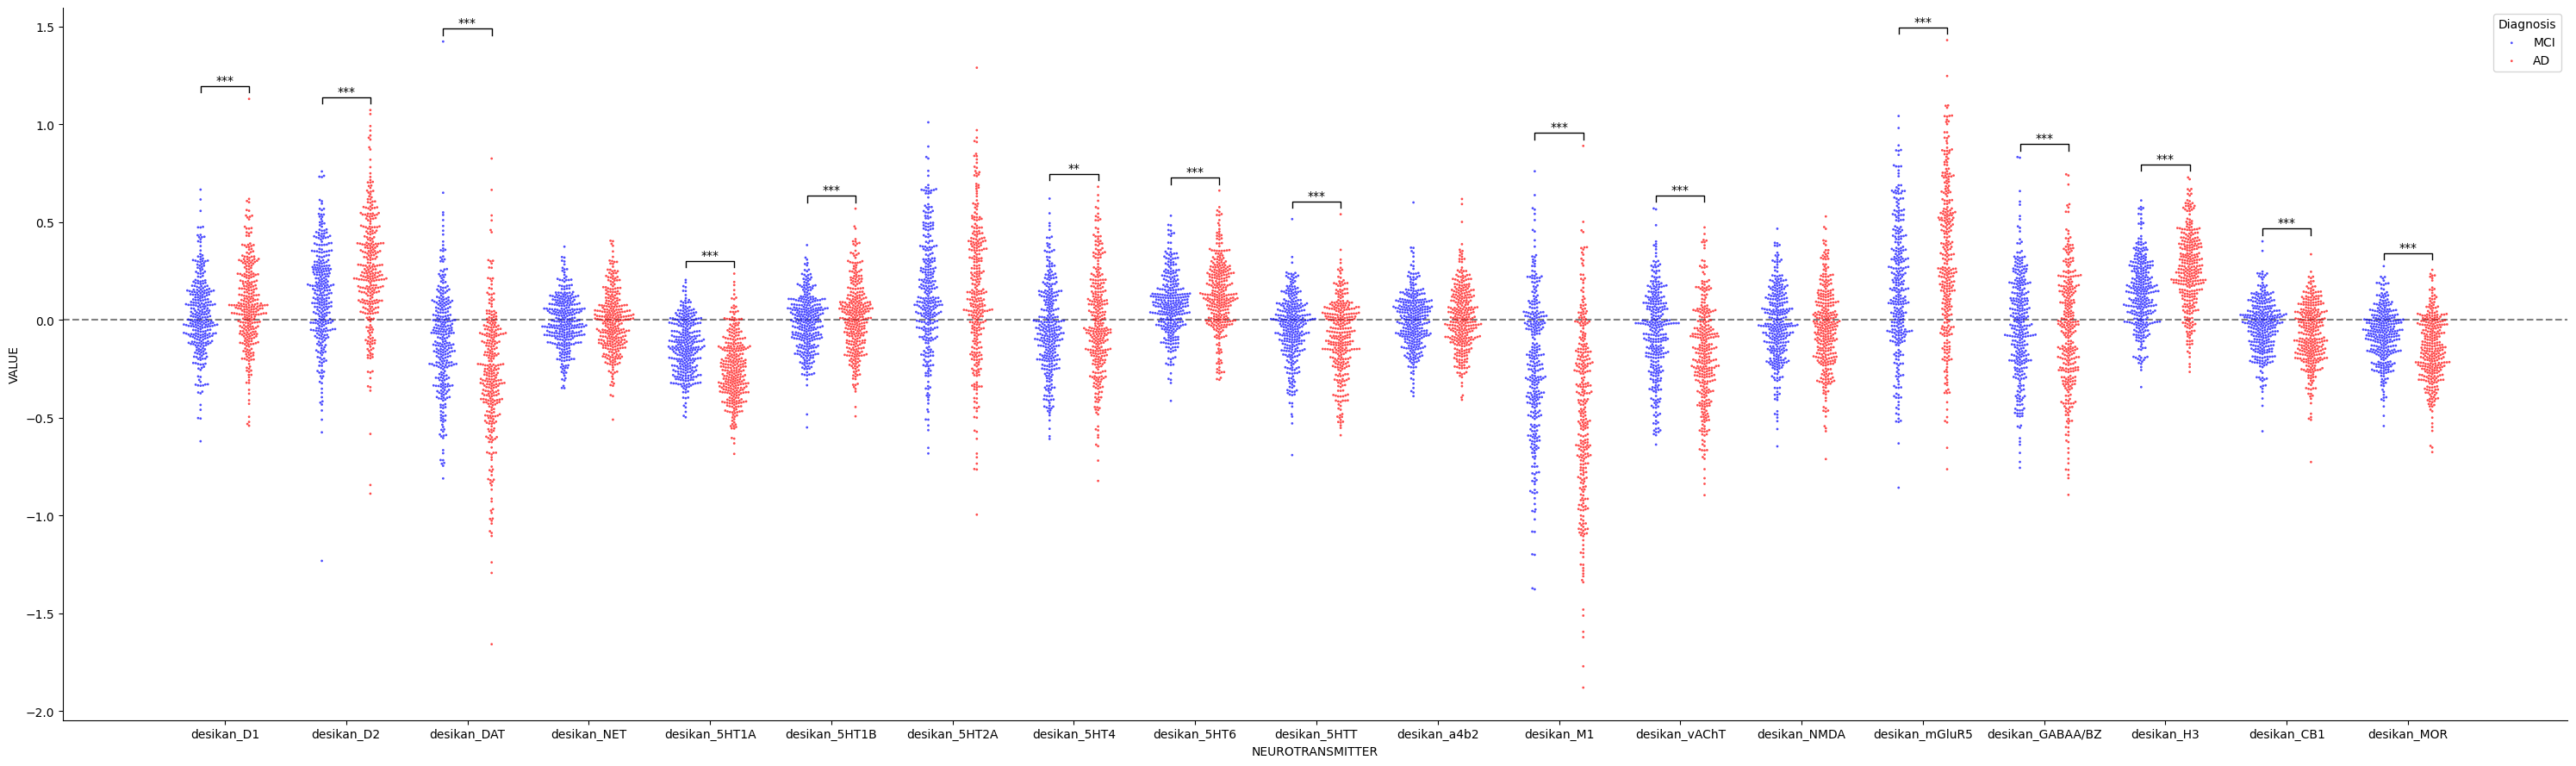

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
from scipy.stats import kstest, levene, mannwhitneyu, ttest_ind
from matplotlib.colors import ListedColormap
from statsmodels.stats.multitest import multipletests
import scipy
from scipy.stats import shapiro, wilcoxon
from matplotlib import font_manager

font_path = "/rds/general/user/sk4724/home/arial.ttf"
font_manager.fontManager.addfont(font_path)

os.makedirs('/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/swarmplots/', exist_ok = True)

def get_significance_stars(p_value):
    if p_value < 0.001: return '***'
    elif 0.001 < p_value < 0.01: return '**'
    elif 0.01 < p_value < 0.05: return '*'
    else: return 'ns'


coeff_path = '/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/cb_df_far.csv'

df = pd.read_csv(coeff_path, low_memory=False)

df = df[['desikan_D1_mci', 'desikan_D2_mci', 'desikan_DAT_mci', 'desikan_NET_mci', 'desikan_5HT1A_mci', 'desikan_5HT1B_mci', 'desikan_5HT2A_mci', 'desikan_5HT4_mci', 'desikan_5HT6_mci', 'desikan_5HTT_mci', 'desikan_a4b2_mci', 'desikan_M1_mci', 'desikan_vAChT_mci', 'desikan_NMDA_mci', 'desikan_mGluR5_mci', 'desikan_GABAA/BZ_mci', 'desikan_H3_mci', 'desikan_CB1_mci', 'desikan_MOR_mci', 'DIAGNOSIS_oth', 'desikan_D1_oth', 'desikan_D2_oth', 'desikan_DAT_oth', 'desikan_NET_oth', 'desikan_5HT1A_oth', 'desikan_5HT1B_oth', 'desikan_5HT2A_oth', 'desikan_5HT4_oth', 'desikan_5HT6_oth', 'desikan_5HTT_oth', 'desikan_a4b2_oth', 'desikan_M1_oth', 'desikan_vAChT_oth', 'desikan_NMDA_oth', 'desikan_mGluR5_oth', 'desikan_GABAA/BZ_oth', 'desikan_H3_oth', 'desikan_CB1_oth', 'desikan_MOR_oth']]

cleaned_df = df[df['DIAGNOSIS_oth'] == 1].reset_index(drop = True)
cleaned_df.drop(columns = 'DIAGNOSIS_oth', inplace = True)
cleaned_df.columns.tolist()

print(cleaned_df.isna().any().all())

root_cols = [col.replace('_mci','') for col in cleaned_df.columns.tolist() if col.endswith('_mci')]
print(root_cols)

stats_results = []
for c in root_cols:
    subset_df = cleaned_df[[col for col in cleaned_df.columns.tolist() if c in col]]
    is_normal = True
    for g in [cleaned_df[f'{c}_mci'].values, cleaned_df[f'{c}_oth'].values]:
        d = cleaned_df[f'{c}_mci'].values - cleaned_df[f'{c}_oth'].values
        res = shapiro(d)
        if res.pvalue < 0.05:
            is_normal = False
            break
    if is_normal:
        test_name = 'T-test related'
        _, pval, _ = ttest_rel(cleaned_df[f'{c}_mci'].values, cleaned_df[f'{c}_oth'].values)
    else:
        test_name = 'Wilcoxon signed-rank'
        res = wilcoxon(cleaned_df[f'{c}_mci'].values, cleaned_df[f'{c}_oth'].values)
        pval = res.pvalue

    stats_results.append({
    'Coefficient': c,
    'Raw_P': pval,
    'Test': test_name})
    
stats_df = pd.DataFrame(stats_results)
    
reject, p_corr, _, _ = multipletests(stats_df['Raw_P'], alpha=0.05, method='fdr_bh')
stats_df['Corrected_P'] = p_corr
stats_df['Significant'] = reject.tolist()#stats_df['Corrected_P'] < 0.05
print(stats_df)
stats_df.to_csv('/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/sig_diff/cb_far_sig_diff.csv', index = False)


cleaned_df = cleaned_df

mci_df = cleaned_df[['desikan_D1_mci', 'desikan_D2_mci', 'desikan_DAT_mci', 'desikan_NET_mci', 'desikan_5HT1A_mci', 'desikan_5HT1B_mci', 'desikan_5HT2A_mci', 'desikan_5HT4_mci', 'desikan_5HT6_mci', 'desikan_5HTT_mci', 'desikan_a4b2_mci', 'desikan_M1_mci', 'desikan_vAChT_mci', 'desikan_NMDA_mci',	'desikan_mGluR5_mci', 'desikan_GABAA/BZ_mci', 'desikan_H3_mci', 'desikan_CB1_mci', 'desikan_MOR_mci']]
mci_df.columns = mci_df.columns.map(lambda x : x.replace('_mci', ''))
mci_df['DIAGNOSIS'] = 2
print(mci_df.columns.tolist())

ad_df = cleaned_df[['desikan_D1_oth', 'desikan_D2_oth', 'desikan_DAT_oth', 'desikan_NET_oth', 'desikan_5HT1A_oth', 'desikan_5HT1B_oth', 'desikan_5HT2A_oth', 'desikan_5HT4_oth', 'desikan_5HT6_oth', 'desikan_5HTT_oth', 'desikan_a4b2_oth', 'desikan_M1_oth', 'desikan_vAChT_oth', 'desikan_NMDA_oth',	'desikan_mGluR5_oth', 'desikan_GABAA/BZ_oth', 'desikan_H3_oth', 'desikan_CB1_oth', 'desikan_MOR_oth']]
ad_df.columns = ad_df.columns.map(lambda x : x.replace('_oth', ''))
ad_df['DIAGNOSIS'] = 3
print(ad_df.columns.tolist())

joined_df = pd.concat([mci_df, ad_df], axis = 0)

melted_df = joined_df.melt(id_vars='DIAGNOSIS', var_name='NEUROTRANSMITTER', value_name='VALUE')

width = 30
height = 9
dot_size = 2

stats_df = pd.read_csv('/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/sig_diff/cb_far_sig_diff.csv', low_memory = False)

print(f"PRINTING SWARMPLOT - WIDTH = {width}, HEIGHT = {height}, DOT SIZE = {dot_size}")

pval_dict = dict(zip(stats_df['Coefficient'], stats_df['Corrected_P']))

plt.figure(figsize=(width, height))

v_min = melted_df['VALUE'].min()
v_max = melted_df['VALUE'].max()
        
ax = sns.swarmplot(
    data=melted_df, 
    x = 'NEUROTRANSMITTER', 
    y = 'VALUE', 
    hue ='DIAGNOSIS', 
    palette = {2: 'blue', 3: 'red'},
    dodge = True, 
    size = dot_size, 
    alpha = 0.7
) 

# Order + y positions
x_order = melted_df['NEUROTRANSMITTER'].unique()

y_max = melted_df.groupby('NEUROTRANSMITTER')['VALUE'].max()
print(y_max)
        
        
y_range = v_max - v_min
padding = y_range * 0.05
ax.set_ylim(v_min - padding, v_max + padding)

y_total_range = v_max - v_min # Fix 1: Use existing global min/max
    
for i, nt in enumerate(x_order):
    if nt in pval_dict:
        stars = get_significance_stars(pval_dict[nt])
        
        if stars != 'ns':
            
            y_base = y_max[nt] + 0.02 * y_total_range  
            y_tips = y_base - 0.01 * y_total_range    
            
            x1, x2 = i - 0.2, i + 0.2
            
            ax.plot([x1, x1, x2, x2], [y_tips, y_base, y_base, y_tips], lw=1, color='black')
            ax.text((x1 + x2) / 2, y_base, stars, ha='center', va='bottom', fontsize=10)


sns.despine()
plt.legend(['MCI', 'AD'], loc = 'upper right', title = 'Diagnosis')
plt.axhline(y = 0, color = 'grey', linestyle = 'dashed')
plt.tight_layout()
final_path = f"/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/swarmplots/cb_far_w{width}_h{height}_d{dot_size:.1f}.png"
print(final_path)
plt.savefig(final_path, dpi = 600)
plt.show()
plt.close()

#### Swarmplot = cleaned to 2 standard deviations

['desikan_D1', 'desikan_D2', 'desikan_DAT', 'desikan_NET', 'desikan_5HT1A', 'desikan_5HT1B', 'desikan_5HT2A', 'desikan_5HT4', 'desikan_5HT6', 'desikan_5HTT', 'desikan_a4b2', 'desikan_M1', 'desikan_vAChT', 'desikan_NMDA', 'desikan_mGluR5', 'desikan_GABAA/BZ', 'desikan_H3', 'desikan_CB1', 'desikan_MOR', 'DIAGNOSIS']
['desikan_D1', 'desikan_D2', 'desikan_DAT', 'desikan_NET', 'desikan_5HT1A', 'desikan_5HT1B', 'desikan_5HT2A', 'desikan_5HT4', 'desikan_5HT6', 'desikan_5HTT', 'desikan_a4b2', 'desikan_M1', 'desikan_vAChT', 'desikan_NMDA', 'desikan_mGluR5', 'desikan_GABAA/BZ', 'desikan_H3', 'desikan_CB1', 'desikan_MOR', 'DIAGNOSIS']
(11188, 3)
PRINTING SWARMPLOT - WIDTH = 30, HEIGHT = 9, DOT SIZE = 2
{'desikan_D1': 2.94544654753854e-07, 'desikan_D2': 2.182345524023691e-28, 'desikan_DAT': 1.3742658085036598e-30, 'desikan_NET': 0.4550508327138699, 'desikan_5HT1A': 1.1305279884894392e-36, 'desikan_5HT1B': 3.2388913904845026e-05, 'desikan_5HT2A': 0.4735653354397586, 'desikan_5HT4': 0.00200459980845

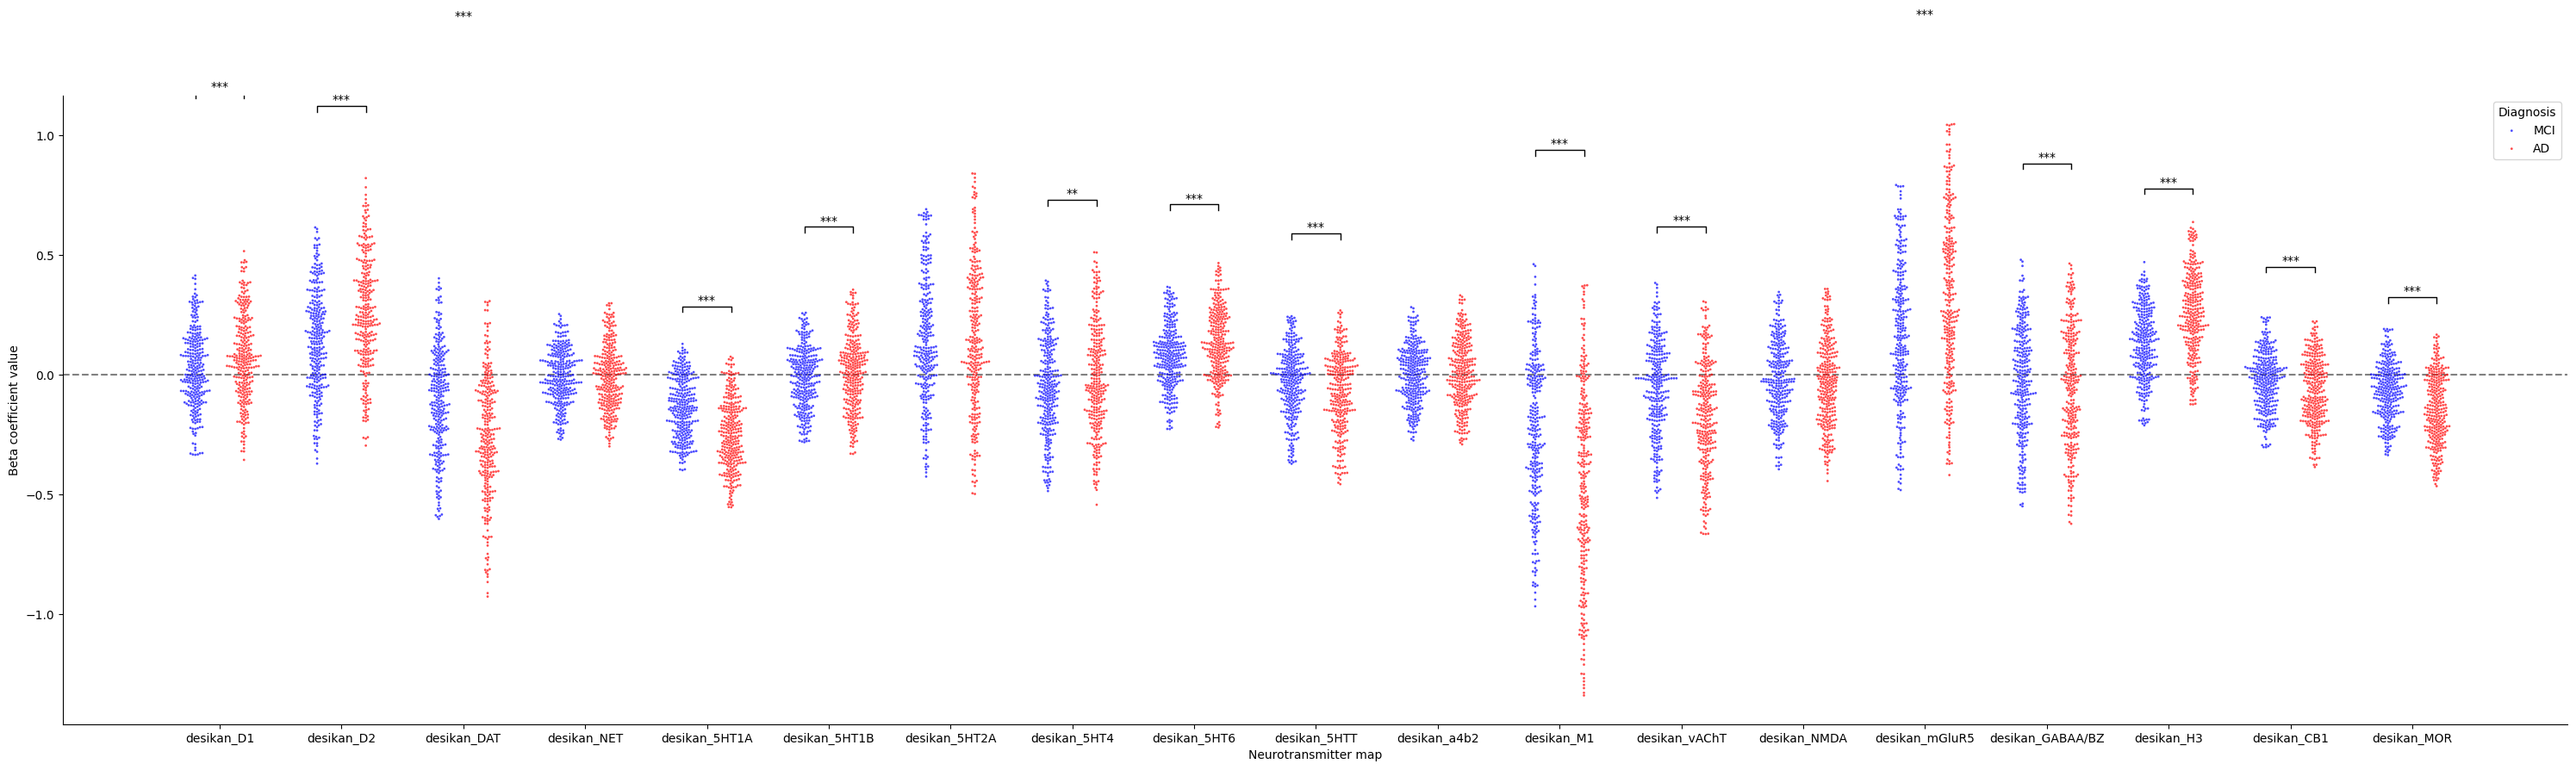

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
from scipy.stats import kstest, levene, mannwhitneyu, ttest_ind
from matplotlib.colors import ListedColormap
from statsmodels.stats.multitest import multipletests
import scipy
from scipy.stats import shapiro, wilcoxon
from matplotlib import font_manager

font_path = "/rds/general/user/sk4724/home/arial.ttf"
font_manager.fontManager.addfont(font_path)

os.makedirs('/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/swarmplots/', exist_ok = True)

def get_significance_stars(p_value):
    if p_value < 0.001: return '***'
    elif 0.001 < p_value < 0.01: return '**'
    elif 0.01 < p_value < 0.05: return '*'
    else: return 'ns'


coeff_path = '/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/cb_df_far.csv'

df = pd.read_csv(coeff_path, low_memory=False)

df = df[['desikan_D1_mci', 'desikan_D2_mci', 'desikan_DAT_mci', 'desikan_NET_mci', 'desikan_5HT1A_mci', 'desikan_5HT1B_mci', 'desikan_5HT2A_mci', 'desikan_5HT4_mci', 'desikan_5HT6_mci', 'desikan_5HTT_mci', 'desikan_a4b2_mci', 'desikan_M1_mci', 'desikan_vAChT_mci', 'desikan_NMDA_mci', 'desikan_mGluR5_mci', 'desikan_GABAA/BZ_mci', 'desikan_H3_mci', 'desikan_CB1_mci', 'desikan_MOR_mci', 'DIAGNOSIS_oth', 'desikan_D1_oth', 'desikan_D2_oth', 'desikan_DAT_oth', 'desikan_NET_oth', 'desikan_5HT1A_oth', 'desikan_5HT1B_oth', 'desikan_5HT2A_oth', 'desikan_5HT4_oth', 'desikan_5HT6_oth', 'desikan_5HTT_oth', 'desikan_a4b2_oth', 'desikan_M1_oth', 'desikan_vAChT_oth', 'desikan_NMDA_oth', 'desikan_mGluR5_oth', 'desikan_GABAA/BZ_oth', 'desikan_H3_oth', 'desikan_CB1_oth', 'desikan_MOR_oth']]

cleaned_df = df[df['DIAGNOSIS_oth'] == 1].reset_index(drop = True)
cleaned_df.drop(columns = 'DIAGNOSIS_oth', inplace = True)
cleaned_df.columns.tolist()

mci_df = cleaned_df[['desikan_D1_mci', 'desikan_D2_mci', 'desikan_DAT_mci', 'desikan_NET_mci', 'desikan_5HT1A_mci', 'desikan_5HT1B_mci', 'desikan_5HT2A_mci', 'desikan_5HT4_mci', 'desikan_5HT6_mci', 'desikan_5HTT_mci', 'desikan_a4b2_mci', 'desikan_M1_mci', 'desikan_vAChT_mci', 'desikan_NMDA_mci',	'desikan_mGluR5_mci', 'desikan_GABAA/BZ_mci', 'desikan_H3_mci', 'desikan_CB1_mci', 'desikan_MOR_mci']]
mci_df.columns = mci_df.columns.map(lambda x : x.replace('_mci', ''))
mci_df['DIAGNOSIS'] = 2
print(mci_df.columns.tolist())

ad_df = cleaned_df[['desikan_D1_oth', 'desikan_D2_oth', 'desikan_DAT_oth', 'desikan_NET_oth', 'desikan_5HT1A_oth', 'desikan_5HT1B_oth', 'desikan_5HT2A_oth', 'desikan_5HT4_oth', 'desikan_5HT6_oth', 'desikan_5HTT_oth', 'desikan_a4b2_oth', 'desikan_M1_oth', 'desikan_vAChT_oth', 'desikan_NMDA_oth',	'desikan_mGluR5_oth', 'desikan_GABAA/BZ_oth', 'desikan_H3_oth', 'desikan_CB1_oth', 'desikan_MOR_oth']]
ad_df.columns = ad_df.columns.map(lambda x : x.replace('_oth', ''))
ad_df['DIAGNOSIS'] = 3
print(ad_df.columns.tolist())

joined_df = pd.concat([mci_df, ad_df], axis = 0)

melted_df = joined_df.melt(id_vars='DIAGNOSIS', var_name='NEUROTRANSMITTER', value_name='VALUE')

filtered_df = melted_df.copy()
group_stats = filtered_df.groupby(['NEUROTRANSMITTER', 'DIAGNOSIS'])['VALUE']
means = group_stats.transform('mean')
stds = group_stats.transform('std')

filtered_df = filtered_df[
    (filtered_df['VALUE'] >= means - 2*stds) &
    (filtered_df['VALUE'] <= means + 2*stds)
]


v_min = filtered_df['VALUE'].min()
v_max = filtered_df['VALUE'].max()

print(filtered_df.shape)

width = 30
height = 9
dot_size = 2

stats_df = pd.read_csv('/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/sig_diff/cb_far_sig_diff.csv', low_memory = False)

print(f"PRINTING SWARMPLOT - WIDTH = {width}, HEIGHT = {height}, DOT SIZE = {dot_size}")

pval_dict = dict(zip(stats_df['Coefficient'], stats_df['Corrected_P']))

print(pval_dict)

plt.figure(figsize=(width, height))
        
ax = sns.swarmplot(
    data=filtered_df, 
    x = 'NEUROTRANSMITTER', 
    y = 'VALUE', 
    hue ='DIAGNOSIS', 
    palette = {2: 'blue', 3: 'red'},
    dodge = True, 
    size = dot_size, 
    alpha = 0.7
)
plt.axhline(y = 0, color = 'grey', linestyle = 'dashed')
plt.xlabel('Neurotransmitter map')
plt.ylabel('Beta coefficient value')

y_range = v_max - v_min
padding = y_range * 0.05
ax.set_ylim(v_min - padding, v_max + padding)
y_max_per_nt = filtered_df.groupby('NEUROTRANSMITTER')['VALUE'].max()


# Order + y positions
x_order = melted_df['NEUROTRANSMITTER'].unique()

print(x_order)
y_max = melted_df.groupby('NEUROTRANSMITTER')['VALUE'].max()
print(y_max)
        
y_total_range = v_max - v_min 
    
for i, nt in enumerate(x_order):
    if nt in pval_dict:
        stars = get_significance_stars(pval_dict[nt])
        
        if stars != 'ns':

            y_base = y_max[nt] + 0.02 * y_total_range  
            y_tips = y_base - 0.01 * y_total_range    
            
            x1, x2 = i - 0.2, i + 0.2
            
            ax.plot([x1, x1, x2, x2], [y_tips, y_base, y_base, y_tips], lw=1, color='black')
            ax.text((x1 + x2) / 2, y_base, stars, ha='center', va='bottom', fontsize=10)
sns.despine()
plt.legend(['MCI', 'AD'], loc = 'upper right', title = 'Diagnosis')
plt.tight_layout()
final_path = f"/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/swarmplots/c_cb_far_w{width}_h{height}_d{dot_size:.1f}.png"
print(final_path)
plt.savefig(final_path, dpi = 300)
plt.show()
plt.close()

#### Violinplot

['desikan_D1', 'desikan_D2', 'desikan_DAT', 'desikan_NET', 'desikan_5HT1A', 'desikan_5HT1B', 'desikan_5HT2A', 'desikan_5HT4', 'desikan_5HT6', 'desikan_5HTT', 'desikan_a4b2', 'desikan_M1', 'desikan_vAChT', 'desikan_NMDA', 'desikan_mGluR5', 'desikan_GABAA/BZ', 'desikan_H3', 'desikan_CB1', 'desikan_MOR', 'DIAGNOSIS']
['desikan_D1', 'desikan_D2', 'desikan_DAT', 'desikan_NET', 'desikan_5HT1A', 'desikan_5HT1B', 'desikan_5HT2A', 'desikan_5HT4', 'desikan_5HT6', 'desikan_5HTT', 'desikan_a4b2', 'desikan_M1', 'desikan_vAChT', 'desikan_NMDA', 'desikan_mGluR5', 'desikan_GABAA/BZ', 'desikan_H3', 'desikan_CB1', 'desikan_MOR', 'DIAGNOSIS']
(11188, 3)
PRINTING VIOLINPLOT - WIDTH = 30, HEIGHT = 9, DOT SIZE = 2
{'desikan_D1': 2.94544654753854e-07, 'desikan_D2': 2.182345524023691e-28, 'desikan_DAT': 1.3742658085036598e-30, 'desikan_NET': 0.4550508327138699, 'desikan_5HT1A': 1.1305279884894392e-36, 'desikan_5HT1B': 3.2388913904845026e-05, 'desikan_5HT2A': 0.4735653354397586, 'desikan_5HT4': 0.0020045998084

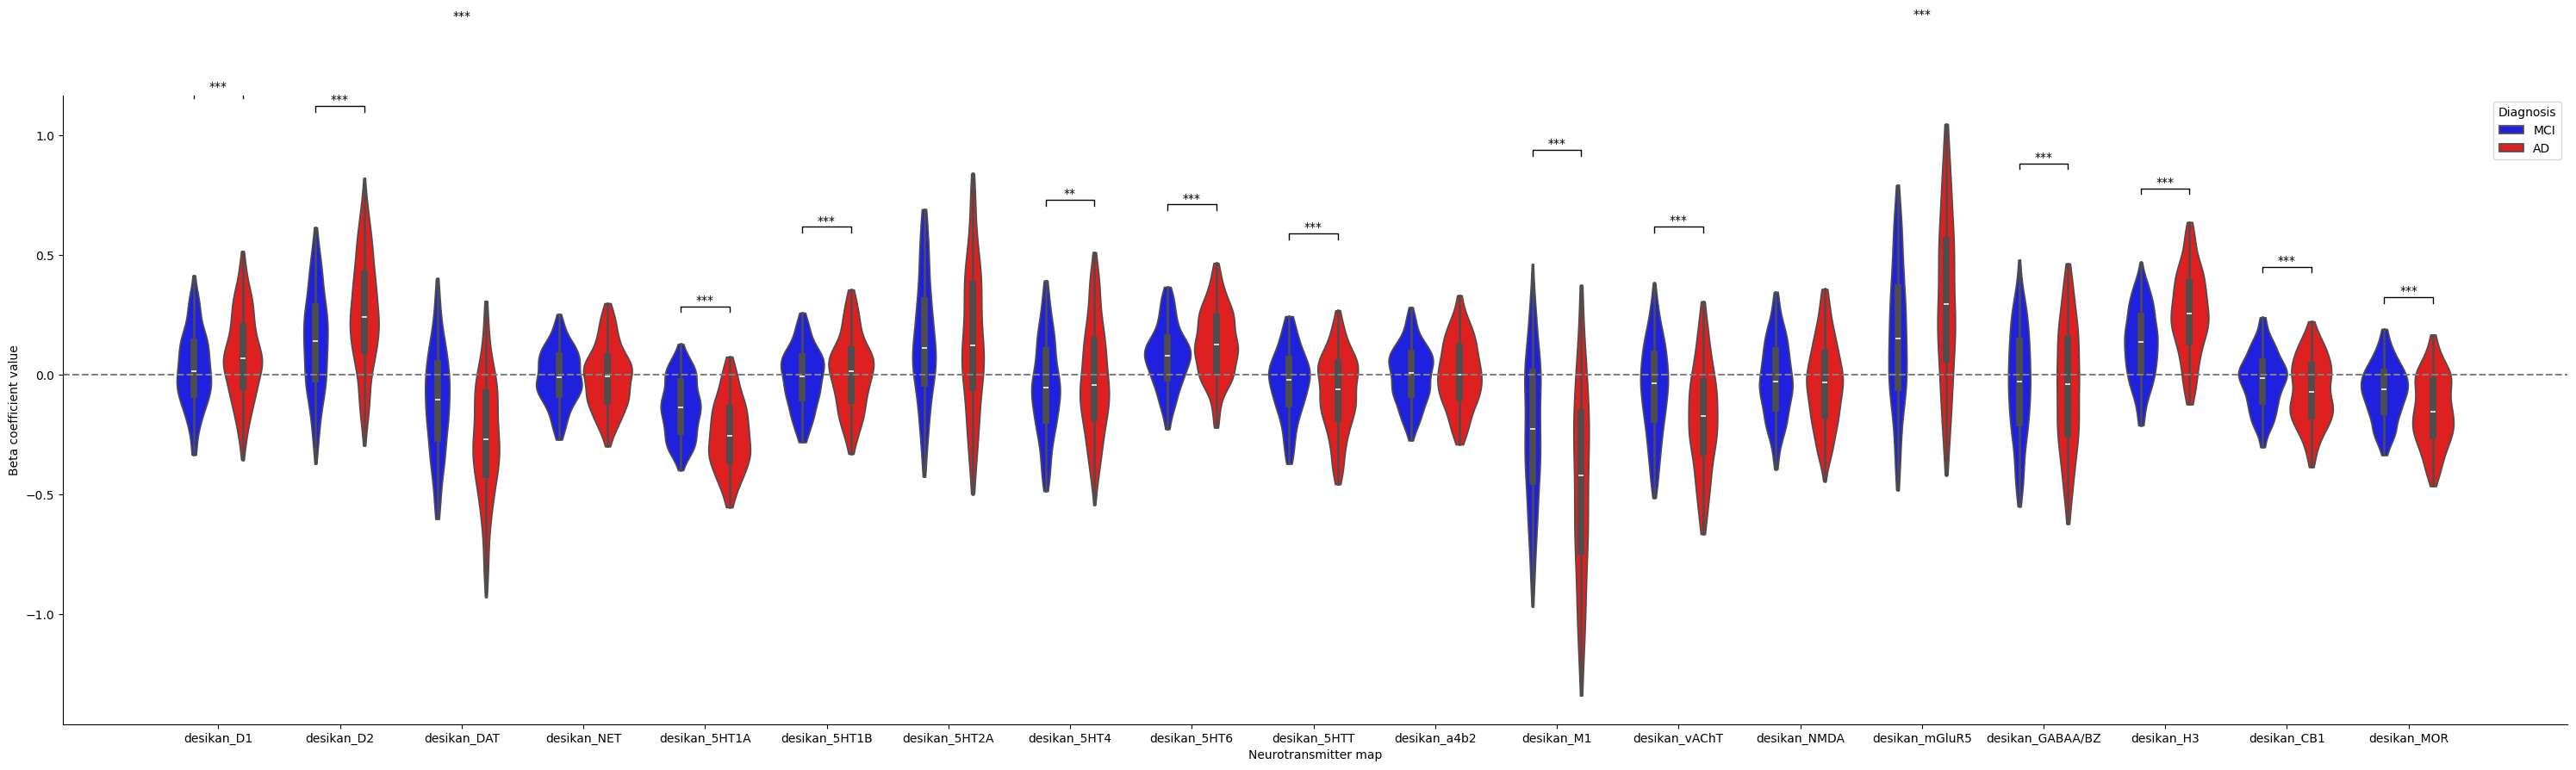

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
from matplotlib import font_manager

font_path = "/rds/general/user/sk4724/home/arial.ttf"
font_manager.fontManager.addfont(font_path)

os.makedirs('/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/violinplots/', exist_ok = True)

def get_significance_stars(p_value):
    if p_value < 0.001: return '***'
    elif 0.001 < p_value < 0.01: return '**'
    elif 0.01 < p_value < 0.05: return '*'
    else: return 'ns'


coeff_path = '/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/cb_df_far.csv'

df = pd.read_csv(coeff_path, low_memory=False)

df = df[['desikan_D1_mci', 'desikan_D2_mci', 'desikan_DAT_mci', 'desikan_NET_mci', 'desikan_5HT1A_mci', 'desikan_5HT1B_mci', 'desikan_5HT2A_mci', 'desikan_5HT4_mci', 'desikan_5HT6_mci', 'desikan_5HTT_mci', 'desikan_a4b2_mci', 'desikan_M1_mci', 'desikan_vAChT_mci', 'desikan_NMDA_mci', 'desikan_mGluR5_mci', 'desikan_GABAA/BZ_mci', 'desikan_H3_mci', 'desikan_CB1_mci', 'desikan_MOR_mci', 'DIAGNOSIS_oth', 'desikan_D1_oth', 'desikan_D2_oth', 'desikan_DAT_oth', 'desikan_NET_oth', 'desikan_5HT1A_oth', 'desikan_5HT1B_oth', 'desikan_5HT2A_oth', 'desikan_5HT4_oth', 'desikan_5HT6_oth', 'desikan_5HTT_oth', 'desikan_a4b2_oth', 'desikan_M1_oth', 'desikan_vAChT_oth', 'desikan_NMDA_oth', 'desikan_mGluR5_oth', 'desikan_GABAA/BZ_oth', 'desikan_H3_oth', 'desikan_CB1_oth', 'desikan_MOR_oth']]

cleaned_df = df[df['DIAGNOSIS_oth'] == 1].reset_index(drop = True)
cleaned_df.drop(columns = 'DIAGNOSIS_oth', inplace = True)
cleaned_df.columns.tolist()

mci_df = cleaned_df[['desikan_D1_mci', 'desikan_D2_mci', 'desikan_DAT_mci', 'desikan_NET_mci', 'desikan_5HT1A_mci', 'desikan_5HT1B_mci', 'desikan_5HT2A_mci', 'desikan_5HT4_mci', 'desikan_5HT6_mci', 'desikan_5HTT_mci', 'desikan_a4b2_mci', 'desikan_M1_mci', 'desikan_vAChT_mci', 'desikan_NMDA_mci',	'desikan_mGluR5_mci', 'desikan_GABAA/BZ_mci', 'desikan_H3_mci', 'desikan_CB1_mci', 'desikan_MOR_mci']]
mci_df.columns = mci_df.columns.map(lambda x : x.replace('_mci', ''))
mci_df['DIAGNOSIS'] = 2
print(mci_df.columns.tolist())

ad_df = cleaned_df[['desikan_D1_oth', 'desikan_D2_oth', 'desikan_DAT_oth', 'desikan_NET_oth', 'desikan_5HT1A_oth', 'desikan_5HT1B_oth', 'desikan_5HT2A_oth', 'desikan_5HT4_oth', 'desikan_5HT6_oth', 'desikan_5HTT_oth', 'desikan_a4b2_oth', 'desikan_M1_oth', 'desikan_vAChT_oth', 'desikan_NMDA_oth',	'desikan_mGluR5_oth', 'desikan_GABAA/BZ_oth', 'desikan_H3_oth', 'desikan_CB1_oth', 'desikan_MOR_oth']]
ad_df.columns = ad_df.columns.map(lambda x : x.replace('_oth', ''))
ad_df['DIAGNOSIS'] = 3
print(ad_df.columns.tolist())

joined_df = pd.concat([mci_df, ad_df], axis = 0)

melted_df = joined_df.melt(id_vars='DIAGNOSIS', var_name='NEUROTRANSMITTER', value_name='VALUE')

filtered_df = melted_df.copy()
group_stats = filtered_df.groupby(['NEUROTRANSMITTER', 'DIAGNOSIS'])['VALUE']
means = group_stats.transform('mean')
stds = group_stats.transform('std')

filtered_df = filtered_df[
    (filtered_df['VALUE'] >= means - 2*stds) &
    (filtered_df['VALUE'] <= means + 2*stds)
]


v_min = filtered_df['VALUE'].min()
v_max = filtered_df['VALUE'].max()

print(filtered_df.shape)

width = 30
height = 9

stats_df = pd.read_csv('/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/sig_diff/cb_far_sig_diff.csv', low_memory = False)

print(f"PRINTING VIOLINPLOT - WIDTH = {width}, HEIGHT = {height}, DOT SIZE = {dot_size}")

pval_dict = dict(zip(stats_df['Coefficient'], stats_df['Corrected_P']))

print(pval_dict)

plt.figure(figsize=(width, height))
        
ax = sns.violinplot(
    data=filtered_df, 
    x = 'NEUROTRANSMITTER', 
    y = 'VALUE', 
    hue ='DIAGNOSIS', 
    palette = {2: 'blue', 3: 'red'},
    split = False,
    cut = 0
)
plt.axhline(y = 0, color = 'grey', linestyle = 'dashed')
plt.xlabel('Neurotransmitter map')
plt.ylabel('Beta coefficient value')

y_range = v_max - v_min
padding = y_range * 0.05
ax.set_ylim(v_min - padding, v_max + padding)
y_max_per_nt = filtered_df.groupby('NEUROTRANSMITTER')['VALUE'].max()


# Order + y positions
x_order = melted_df['NEUROTRANSMITTER'].unique()

print(x_order)
y_max = melted_df.groupby('NEUROTRANSMITTER')['VALUE'].max()
print(y_max)
        
y_total_range = v_max - v_min 
    
for i, nt in enumerate(x_order):
    if nt in pval_dict:
        stars = get_significance_stars(pval_dict[nt])
        
        if stars != 'ns':

            y_base = y_max[nt] + 0.02 * y_total_range  
            y_tips = y_base - 0.01 * y_total_range    
            
            x1, x2 = i - 0.2, i + 0.2
            
            ax.plot([x1, x1, x2, x2], [y_tips, y_base, y_base, y_tips], lw=1, color='black')
            ax.text((x1 + x2) / 2, y_base, stars, ha='center', va='bottom', fontsize=10)
sns.despine()
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles[0:2], ['MCI', 'AD'], loc='upper right', title='Diagnosis')
plt.tight_layout()
final_path = f"/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/violinplots/c_cb_far_w{width}_h{height}_c_violin.png"
print(final_path)
plt.savefig(final_path, dpi = 300)
plt.show()
plt.close()